In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

PyTorch: 2.9.0+cpu, CUDA: False


In [ ]:
# 데이터 경로 설정
DATA_PATHS = {
    'Inter_PI': '/content/drive/MyDrive/URP/1224_Vectors/Inter_PI',
    '3D_PI': '/content/drive/MyDrive/URP/1224_Vectors/3D_PI',
    'Ord_PI': '/content/drive/MyDrive/URP/1224_Vectors/Ord_PI',
    'Sixpack_Chroma': '/content/drive/MyDrive/URP/1224_Vectors/Sixpack_Chroma',
    'Sixpack_Rips': '/content/drive/MyDrive/URP/1224_Vectors/Sixpack_Rips',
}

N_EPOCHS = 100
LEARNING_RATE = 0.001
BATCH_SIZE = 64
MANIFOLD_DIM = 50
CV_FOLDS = 5
USE_PCA = True
PCA_COMPONENTS = 100

print("Data Paths:")
for k, v in DATA_PATHS.items():
    exists = "✓" if os.path.exists(v) else "✗"
    print(f"  {exists} {k}: {v}")

Data Paths:
  ✓ Inter_PI: /content/drive/MyDrive/URP/1224_Vectors/Inter_PI
  ✓ 3D_PI: /content/drive/MyDrive/URP/1224_Vectors/3D_PI
  ✓ Ord_PI: /content/drive/MyDrive/URP/1224_Vectors/Ord_PI
  ✓ Sixpack_Chroma: /content/drive/MyDrive/URP/1224_Vectors/Sixpack_Chroma
  ✓ Sixpack_Rips: /content/drive/MyDrive/URP/1224_Vectors/Sixpack_Rips


In [ ]:
# Mixup_Bacode 경로 추가
DATA_PATHS['Mixup_Bacode'] = '/content/drive/MyDrive/URP/Mixup_Bacode'
DATA_PATHS['TDA_Vector'] = '/content/drive/MyDrive/URP/TDA_Vector'


In [ ]:
# Ground Truth Matrix
M1=[[0,0,1,1,1,1,1,1],[0,0,1,1,1,1,1,1],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3]]
M2=[[0,0,1,1,1,1,1,1],[0,0,1,1,1,1,1,1],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,4],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,4,4],[2,2,3,3,3,3,3,3]]
M3=[[6,6,7,7,7,7,7,7],[6,6,6,7,7,7,7,7],[9,6,3,3,3,3,3,3],[9,10,3,4,4,3,3,4],[9,10,3,3,4,4,3,4],[9,10,3,4,4,4,4,4],[9,10,3,4,3,4,4,4],[9,10,3,4,3,4,4,4]]
M4=[[6,6,12,12,7,7,7,7],[6,6,12,12,7,7,7,7],[9,6,6,11,7,7,4,4],[9,9,6,3,3,4,4,4],[9,9,10,3,3,4,4,4],[9,9,10,3,3,4,4,4],[9,9,10,4,4,4,4,4],[9,9,10,4,4,4,4,4]]
M5=[[6,6,12,12,12,12,7,7],[6,6,12,12,12,12,12,7],[9,9,6,11,11,11,12,11],[9,9,6,11,11,11,4,4],[9,9,13,13,4,4,4,4],[9,9,13,10,4,4,4,4],[9,9,13,10,4,4,4,4],[9,9,10,10,4,4,4,4]]
M6=[[6,12,12,12,12,12,12,12],[6,6,12,12,12,12,12,12],[9,6,6,11,11,11,11,11],[9,9,6,11,11,11,11,11],[9,9,6,6,6,13,4,4],[9,9,6,13,13,4,4,4],[9,9,6,13,4,4,4,4],[9,9,6,13,4,4,4,4]]
M7=[[6,6,12,12,12,12,12,12],[9,6,12,12,12,12,12,12],[9,6,6,11,11,11,11,12],[9,6,6,11,11,11,11,11],[9,9,6,6,11,11,11,11],[9,9,6,6,11,11,11,4],[9,9,6,6,13,13,4,4],[9,9,6,13,13,4,4,4]]
M8=[[6,12,12,12,12,12,12,12],[6,6,12,12,12,12,12,12],[9,6,6,6,11,11,11,11],[9,6,6,6,11,11,11,11],[9,9,6,6,11,11,11,11],[9,9,6,6,6,11,11,11],[9,9,6,6,13,13,11,11],[9,9,6,6,13,13,11,4]]
GROUND_TRUTH_M = np.asarray([M1, M2, M3, M4, M5, M6, M7, M8])

# Multi_3.ipynb에 맞춘 인덱스 계산
# Multi_3.ipynb: param_list = [(x1, x2, x3) for x1 in A for x2 in A for x3 in A]
# 여기서 x1=RR, x2=RG, x3=GG
# task_id = idx + 1, 여기서 idx = RR_idx*64 + RG_idx*8 + GG_idx
# 따라서 task_id = 1 + RR_idx*64 + RG_idx*8 + GG_idx

def param2idx(BB, OO, OB):
    """파라미터 값을 인덱스로 변환 (Multi_3.ipynb 방식)"""
    a_vals = [0.00, 0.01, 0.05, 0.09, 0.13, 0.17, 0.21, 0.25]
    BB_idx = -1
    OO_idx = -1
    OB_idx = -1
    cnt = 0
    for adh in a_vals:
        if np.isclose(BB, adh):
            BB_idx = cnt
        if np.isclose(OO, adh):
            OO_idx = cnt
        if np.isclose(OB, adh):
            OB_idx = cnt
        cnt += 1
    return (BB_idx, OO_idx, OB_idx)

def get_label_from_index(task_id):
    """
    Multi_3.ipynb의 task_id로부터 GT 값 계산
    task_id = 1 + RR_idx*64 + RG_idx*8 + GG_idx
    GROUND_TRUTH_M[RG_idx][RR_idx][GG_idx]로 접근
    """
    idx = task_id - 1
    # idx = RR_idx*64 + RG_idx*8 + GG_idx
    RR_idx = idx // 64
    RG_idx = (idx % 64) // 8
    GG_idx = idx % 8
    # GROUND_TRUTH_M[RG_idx][RR_idx][GG_idx]로 접근
    return GROUND_TRUTH_M[RG_idx][RR_idx][GG_idx]

print(f"Classes: {np.unique(GROUND_TRUTH_M)} ({len(np.unique(GROUND_TRUTH_M))} classes)")

Classes: [ 0  1  2  3  4  6  7  9 10 11 12 13] (12 classes)


In [ ]:
# Training and Evaluation Functions

def clone_classifier(clf):
    if isinstance(clf, KNeighborsClassifier):
        return KNeighborsClassifier(n_neighbors=clf.n_neighbors)
    elif isinstance(clf, SVC):
        return SVC(kernel=clf.kernel, C=clf.C)
    elif isinstance(clf, RandomForestClassifier):
        return RandomForestClassifier(n_estimators=clf.n_estimators, random_state=42)
    return clf

def evaluate_classifiers(X, y, n_splits=5, verbose=False):
    classifiers = {
        'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
        'KNN (k=12)': KNeighborsClassifier(n_neighbors=12),
        'SVM (RBF)': SVC(kernel='rbf', C=1.0),
        'SVM (Linear)': SVC(kernel='linear', C=1.0),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    }
    results = {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for name, clf in classifiers.items():
        accuracies = []
        for train_idx, test_idx in skf.split(X, y):
            clf_copy = clone_classifier(clf)
            clf_copy.fit(X[train_idx], y[train_idx])
            y_pred = clf_copy.predict(X[test_idx])
            accuracies.append(accuracy_score(y[test_idx], y_pred))
        results[name] = {'mean': np.mean(accuracies) * 100, 'std': np.std(accuracies) * 100}
        if verbose:
            print(f"    {name}: {results[name]['mean']:.2f}% ± {results[name]['std']:.2f}%")
    return results

def train_autoencoder(X, y, n_epochs=100, learning_rate=0.001, batch_size=64, manifold_dim=50, verbose=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    input_dim = X.shape[1]
    encoder = Encoder_basic(input_dim, 256, 128, 64).to(device)
    decoder = Decoder_Manifold(manifold_dim, 64, 128, 250, input_dim).to(device)
    params = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = optim.Adam(params, lr=learning_rate)
    criterion = nn.MSELoss()
    dataset = SimpleDataset(X, y)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    losses = []

    for epoch in range(1, n_epochs + 1):
        epoch_loss = 0.0
        for batch_X, _ in dataloader:
            batch_X = batch_X.to(device)
            optimizer.zero_grad()
            hidden = encoder(batch_X)
            embed, output = decoder(hidden)
            loss = criterion(output, batch_X)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        epoch_loss /= len(dataloader)
        losses.append(epoch_loss)
        if verbose and epoch % 50 == 0:
            print(f"    Epoch {epoch}/{n_epochs}, Loss: {epoch_loss:.6f}")
    return encoder, decoder, losses, device

def get_embeddings(encoder, decoder, X, device, batch_size=64):
    encoder.eval()
    decoder.eval()
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch_X = torch.FloatTensor(X[i:i+batch_size]).to(device)
            hidden = encoder(batch_X)
            embed, _ = decoder(hidden)
            embeddings.append(embed.cpu().numpy())
    return np.vstack(embeddings)

In [ ]:
"""
데이터 로딩 핫픽스 코드
7개 벡터화 방법 데이터 로딩 함수들
"""

import os
import glob
import numpy as np

# ============================================
# 1. Ground Truth Matrix 및 Helper 함수
# ============================================

M1=[[0,0,1,1,1,1,1,1],[0,0,1,1,1,1,1,1],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3]]
M2=[[0,0,1,1,1,1,1,1],[0,0,1,1,1,1,1,1],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,4],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,4,4],[2,2,3,3,3,3,3,3]]
M3=[[6,6,7,7,7,7,7,7],[6,6,6,7,7,7,7,7],[9,6,3,3,3,3,3,3],[9,10,3,4,4,3,3,4],[9,10,3,3,4,4,3,4],[9,10,3,4,4,4,4,4],[9,10,3,4,3,4,4,4],[9,10,3,4,3,4,4,4]]
M4=[[6,6,12,12,7,7,7,7],[6,6,12,12,7,7,7,7],[9,6,6,11,7,7,4,4],[9,9,6,3,3,4,4,4],[9,9,10,3,3,4,4,4],[9,9,10,3,3,4,4,4],[9,9,10,4,4,4,4,4],[9,9,10,4,4,4,4,4]]
M5=[[6,6,12,12,12,12,7,7],[6,6,12,12,12,12,12,7],[9,9,6,11,11,11,12,11],[9,9,6,11,11,11,4,4],[9,9,13,13,4,4,4,4],[9,9,13,10,4,4,4,4],[9,9,13,10,4,4,4,4],[9,9,10,10,4,4,4,4]]
M6=[[6,12,12,12,12,12,12,12],[6,6,12,12,12,12,12,12],[9,6,6,11,11,11,11,11],[9,9,6,11,11,11,11,11],[9,9,6,6,6,13,4,4],[9,9,6,13,13,4,4,4],[9,9,6,13,4,4,4,4],[9,9,6,13,4,4,4,4]]
M7=[[6,6,12,12,12,12,12,12],[9,6,12,12,12,12,12,12],[9,6,6,11,11,11,11,12],[9,6,6,11,11,11,11,11],[9,9,6,6,11,11,11,11],[9,9,6,6,11,11,11,4],[9,9,6,6,13,13,4,4],[9,9,6,13,13,4,4,4]]
M8=[[6,12,12,12,12,12,12,12],[6,6,12,12,12,12,12,12],[9,6,6,6,11,11,11,11],[9,6,6,6,11,11,11,11],[9,9,6,6,11,11,11,11],[9,9,6,6,6,11,11,11],[9,9,6,6,13,13,11,11],[9,9,6,6,13,13,11,4]]
GROUND_TRUTH_M = np.asarray([M1, M2, M3, M4, M5, M6, M7, M8])

def get_label_from_index(task_id):
    """Multi_3.ipynb의 task_id로부터 GT 값 계산"""
    idx = task_id - 1
    RR_idx = idx // 64
    RG_idx = (idx % 64) // 8
    GG_idx = idx % 8
    return GROUND_TRUTH_M[RG_idx][RR_idx][GG_idx]

# ============================================
# 2. 데이터 로딩 함수들
# ============================================

def load_inter_pi_data(data_dir):
    """Load Inter_PI data. File format: Inter_PI_{idx}.npz"""
    npz_files = sorted(glob.glob(os.path.join(data_dir, "Inter_PI_*.npz")))
    print(f"  Found {len(npz_files)} files")
    X_list, y_list, indices = [], [], []

    for filepath in npz_files:
        filename = os.path.basename(filepath)
        try:
            sim_idx = int(filename.split('_')[-1].split('.')[0])
            label = get_label_from_index(sim_idx)
            data = np.load(filepath, allow_pickle=True)
            arr_0 = data['arr_0'][0] if data['arr_0'].shape == (1,) else data['arr_0'].item()
            arr_1 = data['arr_1'][0] if data['arr_1'].shape == (1,) else data['arr_1'].item()

            features = []
            for key in sorted(arr_0.keys()):
                features.extend(arr_0[key].flatten())
            for key in sorted(arr_1.keys()):
                features.extend(arr_1[key].flatten())

            X_list.append(features)
            y_list.append(label)
            indices.append(sim_idx)
        except Exception as e:
            print(f"  Error: {filename} - {e}")

    return np.nan_to_num(np.array(X_list), nan=0.0, posinf=0.0, neginf=0.0), np.array(y_list), indices

def load_3d_pi_data(data_dir):
    """Load 3D_PI data. File format: 3D_PI_{idx}.npz"""
    npz_files = sorted(glob.glob(os.path.join(data_dir, "3D_PI_*.npz")))
    print(f"  Found {len(npz_files)} files")
    X_list, y_list, indices = [], [], []

    for filepath in npz_files:
        filename = os.path.basename(filepath)
        try:
            sim_idx = int(filename.split('_')[-1].split('.')[0])
            label = get_label_from_index(sim_idx)
            data = np.load(filepath, allow_pickle=True)
            arr_0 = data['arr_0'].item()
            arr_1 = data['arr_1'].item()

            features = []
            for key in sorted(arr_0.keys()):
                features.extend(arr_0[key].flatten())
            for key in sorted(arr_1.keys()):
                features.extend(arr_1[key].flatten())

            X_list.append(features)
            y_list.append(label)
            indices.append(sim_idx)
        except Exception as e:
            print(f"  Error: {filename} - {e}")

    return np.nan_to_num(np.array(X_list), nan=0.0, posinf=0.0, neginf=0.0), np.array(y_list), indices

def load_ord_pi_data(data_dir):
    """Load Ord_PI data. File format: Ord_PI_{idx}.npz"""
    npz_files = sorted(glob.glob(os.path.join(data_dir, "Ord_PI_*.npz")))
    print(f"  Found {len(npz_files)} files")
    X_list, y_list, indices = [], [], []

    for filepath in npz_files:
        filename = os.path.basename(filepath)
        try:
            sim_idx = int(filename.split('_')[-1].split('.')[0])
            label = get_label_from_index(sim_idx)
            data = np.load(filepath, allow_pickle=True)
            arr_0 = data['arr_0'].item()
            arr_1 = data['arr_1'].item()

            features = []
            for key in sorted(arr_0.keys()):
                features.extend(arr_0[key].flatten())
            for key in sorted(arr_1.keys()):
                features.extend(arr_1[key].flatten())

            X_list.append(features)
            y_list.append(label)
            indices.append(sim_idx)
        except Exception as e:
            print(f"  Error: {filename} - {e}")

    return np.nan_to_num(np.array(X_list), nan=0.0, posinf=0.0, neginf=0.0), np.array(y_list), indices

def extract_statistical_features(barcode):
    """Extract statistical features from barcode"""
    if len(barcode) == 0:
        return np.zeros(12)

    # barcode를 numpy 배열로 변환
    barcode = np.array(barcode)

    # 1차원 배열인 경우 처리
    if barcode.ndim == 1:
        # 길이가 짝수인 경우 (birth, death) 쌍으로 reshape 시도
        if len(barcode) % 2 == 0:
            barcode = barcode.reshape(-1, 2)
        else:
            # 홀수인 경우 마지막 요소 제거하거나 0으로 패딩
            if len(barcode) > 2:
                barcode = barcode[:len(barcode)//2*2].reshape(-1, 2)
            else:
                # 너무 짧으면 0으로 채운 2차원 배열 생성
                barcode = np.array([[0.0, 0.0]])

    # 2차원 배열이지만 shape이 (n,)인 경우 처리
    if barcode.ndim == 1:
        return np.zeros(12)

    # shape 확인 및 조정
    if barcode.shape[1] < 2:
        # 열이 1개만 있으면 0으로 패딩
        barcode_padded = np.zeros((barcode.shape[0], 2))
        barcode_padded[:, 0] = barcode[:, 0] if barcode.shape[1] > 0 else 0
        barcode = barcode_padded

    lifespans = barcode[:, 1] - barcode[:, 0]
    births = barcode[:, 0]
    deaths = barcode[:, 1]
    features = [len(barcode), np.mean(lifespans), np.std(lifespans), np.max(lifespans),
                np.min(lifespans), np.sum(lifespans), np.mean(births), np.std(births),
                np.mean(deaths), np.std(deaths), np.median(lifespans)]
    if np.sum(lifespans) > 0:
        probs = lifespans / np.sum(lifespans)
        probs = probs[probs > 0]
        entropy = -np.sum(probs * np.log(probs + 1e-10))
    else:
        entropy = 0
    features.append(entropy)
    return np.array(features)

def load_sixpack_data(data_dir):
    """Load Six-Pack barcode data (Sixpack_1119) - Statistical Features 288D."""
    npz_files = sorted(glob.glob(os.path.join(data_dir, "Sixpack_1119_*.npz")))
    print(f"  Found {len(npz_files)} files")
    X_list, y_list, indices = [], [], []
    barcode_types = ['domain', 'codomain', 'relative', 'image', 'kernel', 'cokernel']

    for filepath in npz_files:
        filename = os.path.basename(filepath)
        try:
            sim_idx = int(filename.split('_')[2].split('.')[0])
            label = get_label_from_index(sim_idx)
            data = np.load(filepath, allow_pickle=True)
            sixpack_data = {'A_to_B': data['arr_0'].item(), 'B_to_A': data['arr_1'].item()}

            features = []
            for direction in ['A_to_B', 'B_to_A']:
                dir_data = sixpack_data[direction]
                for btype in barcode_types:
                    for dim_key in [0, 1]:
                        if btype in dir_data and dim_key in dir_data[btype]:
                            barcode = np.array(dir_data[btype][dim_key])
                            feat = extract_statistical_features(barcode) if len(barcode) > 0 else np.zeros(12)
                        else:
                            feat = np.zeros(12)
                        features.extend(feat)

            X_list.append(features)
            y_list.append(label)
            indices.append(sim_idx)
        except Exception as e:
            print(f"  Error: {filename} - {e}")

    return np.nan_to_num(np.array(X_list), nan=0.0, posinf=0.0, neginf=0.0), np.array(y_list), indices

def load_sixpack_rips_data(data_dir):
    """Load Sixpack_Rips data. File format: Sixpack_Rips_{idx}.npz - Statistical Features 288D."""
    npz_files = sorted(glob.glob(os.path.join(data_dir, "Sixpack_Rips_*.npz")))
    print(f"  Found {len(npz_files)} files")
    X_list, y_list, indices = [], [], []
    barcode_types = ['domain', 'codomain', 'relative', 'image', 'kernel', 'cokernel']

    for filepath in npz_files:
        filename = os.path.basename(filepath)
        try:
            # Sixpack_Rips_{idx}.npz 형식에서 idx 추출
            sim_idx = int(filename.split('_')[-1].split('.')[0])
            label = get_label_from_index(sim_idx)
            data = np.load(filepath, allow_pickle=True)
            sixpack_data = {'A_to_B': data['arr_0'].item(), 'B_to_A': data['arr_1'].item()}

            features = []
            for direction in ['A_to_B', 'B_to_A']:
                dir_data = sixpack_data[direction]
                for btype in barcode_types:
                    for dim_key in [0, 1]:
                        if btype in dir_data and dim_key in dir_data[btype]:
                            barcode_raw = dir_data[btype][dim_key]
                            # barcode를 numpy 배열로 변환
                            barcode = np.array(barcode_raw)

                            # 빈 배열이거나 길이가 0인 경우
                            if len(barcode) == 0:
                                feat = np.zeros(12)
                            else:
                                # shape 확인 및 처리
                                if barcode.ndim == 1:
                                    # 1차원 배열인 경우
                                    if len(barcode) >= 2:
                                        # 최소 2개 요소가 있으면 reshape 시도
                                        if len(barcode) % 2 == 0:
                                            barcode = barcode.reshape(-1, 2)
                                        else:
                                            # 홀수인 경우 마지막 요소 제거
                                            barcode = barcode[:len(barcode)//2*2].reshape(-1, 2)
                                    else:
                                        # 너무 짧으면 0으로 채운 배열
                                        barcode = np.array([[0.0, 0.0]])
                                elif barcode.ndim == 2:
                                    # 2차원 배열인 경우
                                    if barcode.shape[1] < 2:
                                        # 열이 부족하면 패딩
                                        barcode_padded = np.zeros((barcode.shape[0], 2))
                                        barcode_padded[:, :barcode.shape[1]] = barcode
                                        barcode = barcode_padded

                                feat = extract_statistical_features(barcode)
                        else:
                            feat = np.zeros(12)
                        features.extend(feat)

            X_list.append(features)
            y_list.append(label)
            indices.append(sim_idx)
        except Exception as e:
            print(f"  Error: {filename} - {e}")
            import traceback
            traceback.print_exc()

    return np.nan_to_num(np.array(X_list), nan=0.0, posinf=0.0, neginf=0.0), np.array(y_list), indices

def load_sixpack_chroma_data(data_dir):
    """Load Sixpack_Chroma data. File format: Sixpack_Chroma_{idx}.npz"""
    npz_files = sorted(glob.glob(os.path.join(data_dir, "Sixpack_Chroma_*.npz")))
    print(f"  Found {len(npz_files)} files")
    X_list, y_list, indices = [], [], []

    for filepath in npz_files:
        filename = os.path.basename(filepath)
        try:
            sim_idx = int(filename.split('_')[-1].split('.')[0])
            label = get_label_from_index(sim_idx)
            data = np.load(filepath, allow_pickle=True)

            arr_0 = data['arr_0'].item() if hasattr(data['arr_0'], 'item') else data['arr_0']
            arr_1 = data['arr_1'].item() if hasattr(data['arr_1'], 'item') else data['arr_1']

            if isinstance(arr_0, dict):
                features = []
                for key in sorted(arr_0.keys()):
                    val = arr_0[key]
                    if not isinstance(val, np.ndarray):
                        val = np.array(val)
                    features.extend(val.flatten())
                for key in sorted(arr_1.keys()):
                    val = arr_1[key]
                    if not isinstance(val, np.ndarray):
                        val = np.array(val)
                    features.extend(val.flatten())
            else:
                features = []
                arr_0 = np.array(arr_0) if not isinstance(arr_0, np.ndarray) else arr_0
                arr_1 = np.array(arr_1) if not isinstance(arr_1, np.ndarray) else arr_1
                features.extend(arr_0.flatten())
                features.extend(arr_1.flatten())

            X_list.append(features)
            y_list.append(label)
            indices.append(sim_idx)
        except Exception as e:
            print(f"  Error: {filename} - {e}")

    return np.nan_to_num(np.array(X_list), nan=0.0, posinf=0.0, neginf=0.0), np.array(y_list), indices

# ============================================
# 3. 데이터 로딩 실행 코드
# ============================================

# 데이터 경로 설정 (Google Colab 기준)
DATA_PATHS = {
    'Inter_PI': '/content/drive/MyDrive/URP/1224_Vectors/Inter_PI',
    '3D_PI': '/content/drive/MyDrive/URP/1224_Vectors/3D_PI',
    'Ord_PI': '/content/drive/MyDrive/URP/1224_Vectors/Ord_PI',
    'Sixpack_Chroma': '/content/drive/MyDrive/URP/1224_Vectors/Sixpack_Chroma',
    'Sixpack_Rips': '/content/drive/MyDrive/URP/1224_Vectors/Sixpack_Rips',
}

print("="*80)
print("데이터 로딩")
print("="*80)

datasets = {}
loaders = {
    'Inter_PI': load_inter_pi_data,
    '3D_PI': load_3d_pi_data,
    'Ord_PI': load_ord_pi_data,
    'Sixpack_Chroma': load_sixpack_chroma_data,
    'Sixpack_Rips': load_sixpack_rips_data,
}

for i, (name, loader) in enumerate(loaders.items(), 1):
    print(f"\n[{i}] {name}")
    if name in DATA_PATHS and os.path.exists(DATA_PATHS[name]):
        try:
            X, y, idx = loader(DATA_PATHS[name])
            if len(X) > 0:
                datasets[name] = {'X': X, 'y': y, 'indices': idx}
                print(f"  ✓ Shape: {X.shape}, Classes: {len(np.unique(y))}")
            else:
                print(f"  ✗ No data loaded")
        except Exception as e:
            print(f"  ✗ Error: {e}")
            import traceback
            traceback.print_exc()
    else:
        print(f"  ✗ Path not found: {DATA_PATHS.get(name, 'N/A')}")

# Inter+Ord, 3D_Ord 결합
print("\n" + "="*80)
print("Combining Datasets")
print("="*80)

if 'Inter_PI' in datasets and 'Ord_PI' in datasets:
    print("[Inter+Ord] Combining Inter_PI + Ord_PI")
    X_inter = datasets['Inter_PI']['X']
    X_ord = datasets['Ord_PI']['X']
    y_inter = datasets['Inter_PI']['y']
    # 샘플 순서가 동일하다고 가정
    if len(X_inter) == len(X_ord):
        X_combined = np.hstack([X_inter, X_ord])
        datasets['Inter+Ord'] = {'X': X_combined, 'y': y_inter}
        print(f"  ✓ Shape: {X_combined.shape}")

if '3D_PI' in datasets and 'Ord_PI' in datasets:
    print("[3D_Ord] Combining 3D_PI + Ord_PI")
    X_3d = datasets['3D_PI']['X']
    X_ord = datasets['Ord_PI']['X']
    y_3d = datasets['3D_PI']['y']
    if len(X_3d) == len(X_ord):
        X_combined = np.hstack([X_3d, X_ord])
        datasets['3D_Ord'] = {'X': X_combined, 'y': y_3d}
        print(f"  ✓ Shape: {X_combined.shape}")

print("\n" + "="*80)
print("✓ 데이터 로딩 완료!")
print("="*80)
print(f"\n로드된 데이터셋: {list(datasets.keys())}")
for name, data in datasets.items():
    print(f"  {name}: {data['X'].shape}, Classes: {len(np.unique(data['y']))}")



데이터 로딩

[1] Inter_PI
  Found 512 files
  ✓ Shape: (512, 10200), Classes: 12

[2] 3D_PI
  Found 512 files
  ✓ Shape: (512, 16800), Classes: 12

[3] Ord_PI
  Found 512 files
  ✓ Shape: (512, 10200), Classes: 12

[4] Sixpack_Chroma
  Found 512 files
  ✓ Shape: (512, 12), Classes: 12

[5] Sixpack_Rips
  Found 512 files
  ✓ Shape: (512, 288), Classes: 12

Combining Datasets
[Inter+Ord] Combining Inter_PI + Ord_PI
  ✓ Shape: (512, 20400)
[3D_Ord] Combining 3D_PI + Ord_PI
  ✓ Shape: (512, 27000)

✓ 데이터 로딩 완료!

로드된 데이터셋: ['Inter_PI', '3D_PI', 'Ord_PI', 'Sixpack_Chroma', 'Sixpack_Rips', 'Inter+Ord', '3D_Ord']
  Inter_PI: (512, 10200), Classes: 12
  3D_PI: (512, 16800), Classes: 12
  Ord_PI: (512, 10200), Classes: 12
  Sixpack_Chroma: (512, 12), Classes: 12
  Sixpack_Rips: (512, 288), Classes: 12
  Inter+Ord: (512, 20400), Classes: 12
  3D_Ord: (512, 27000), Classes: 12


In [ ]:
import numpy as np

M1=[[0,0,1,1,1,1,1,1],[0,0,1,1,1,1,1,1],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3]]
M2=[[0,0,1,1,1,1,1,1],[0,0,1,1,1,1,1,1],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,3,4],[2,2,3,3,3,3,3,3],[2,2,3,3,3,3,4,4],[2,2,3,3,3,3,3,3]]
M3=[[6,6,7,7,7,7,7,7],[6,6,6,7,7,7,7,7],[9,6,3,3,3,3,3,3],[9,10,3,4,4,3,3,4],[9,10,3,3,4,4,3,4],[9,10,3,4,4,4,4,4],[9,10,3,4,3,4,4,4],[9,10,3,4,3,4,4,4]]
M4=[[6,6,12,12,7,7,7,7],[6,6,12,12,7,7,7,7],[9,6,6,11,7,7,4,4],[9,9,6,3,3,4,4,4],[9,9,10,3,3,4,4,4],[9,9,10,3,3,4,4,4],[9,9,10,4,4,4,4,4],[9,9,10,4,4,4,4,4]]
M5=[[6,6,12,12,12,12,7,7],[6,6,12,12,12,12,12,7],[9,9,6,11,11,11,12,11],[9,9,6,11,11,11,4,4],[9,9,13,13,4,4,4,4],[9,9,13,10,4,4,4,4],[9,9,13,10,4,4,4,4],[9,9,10,10,4,4,4,4]]
M6=[[6,12,12,12,12,12,12,12],[6,6,12,12,12,12,12,12],[9,6,6,11,11,11,11,11],[9,9,6,11,11,11,11,11],[9,9,6,6,6,13,4,4],[9,9,6,13,13,4,4,4],[9,9,6,13,4,4,4,4],[9,9,6,13,4,4,4,4]]
M7=[[6,6,12,12,12,12,12,12],[9,6,12,12,12,12,12,12],[9,6,6,11,11,11,11,12],[9,6,6,11,11,11,11,11],[9,9,6,6,11,11,11,11],[9,9,6,6,11,11,11,4],[9,9,6,6,13,13,4,4],[9,9,6,13,13,4,4,4]]
M8=[[6,12,12,12,12,12,12,12],[6,6,12,12,12,12,12,12],[9,6,6,6,11,11,11,11],[9,6,6,6,11,11,11,11],[9,9,6,6,11,11,11,11],[9,9,6,6,6,11,11,11],[9,9,6,6,13,13,11,11],[9,9,6,6,13,13,11,4]]

GROUND_TRUTH_M = np.asarray([M1, M2, M3, M4, M5, M6, M7, M8])

# Phase diagram에서 인접 관계 추출
def extract_adjacent_phases(matrices):
    adjacent_pairs = set()

    for M in matrices:
        M = np.array(M)
        rows, cols = M.shape

        for i in range(rows):
            for j in range(cols):
                current = M[i, j]

                # 상하좌우 확인
                neighbors = []
                if i > 0:
                    neighbors.append(M[i-1, j])  # 위
                if i < rows-1:
                    neighbors.append(M[i+1, j])  # 아래
                if j > 0:
                    neighbors.append(M[i, j-1])  # 왼쪽
                if j < cols-1:
                    neighbors.append(M[i, j+1])  # 오른쪽

                for neighbor in neighbors:
                    if current != neighbor:
                        pair = tuple(sorted([current, neighbor]))
                        adjacent_pairs.add(pair)

    return adjacent_pairs

# 인접 쌍 추출
adjacent_pairs = extract_adjacent_phases(GROUND_TRUTH_M)
print("=== Phase Diagram에서 추출한 인접 쌍 ===")
print(sorted(adjacent_pairs))
print("\n총 {}개 인접 쌍".format(len(adjacent_pairs)))

# Dictionary 형태로 변환
ADJACENT_PHASES_NEW = {}
for p1, p2 in adjacent_pairs:
    if p1 not in ADJACENT_PHASES_NEW:
        ADJACENT_PHASES_NEW[p1] = []
    if p2 not in ADJACENT_PHASES_NEW:
        ADJACENT_PHASES_NEW[p2] = []
    if p2 not in ADJACENT_PHASES_NEW[p1]:
        ADJACENT_PHASES_NEW[p1].append(p2)
    if p1 not in ADJACENT_PHASES_NEW[p2]:
        ADJACENT_PHASES_NEW[p2].append(p1)

print("\n=== 새로운 ADJACENT_PHASES 정의 ===")
for phase in sorted(ADJACENT_PHASES_NEW.keys()):
    print("    {}: {},".format(phase, sorted(ADJACENT_PHASES_NEW[phase])))

=== Phase Diagram에서 추출한 인접 쌍 ===
[(np.int64(0), np.int64(1)), (np.int64(0), np.int64(2)), (np.int64(1), np.int64(3)), (np.int64(2), np.int64(3)), (np.int64(3), np.int64(4)), (np.int64(3), np.int64(6)), (np.int64(3), np.int64(7)), (np.int64(3), np.int64(10)), (np.int64(3), np.int64(11)), (np.int64(4), np.int64(7)), (np.int64(4), np.int64(10)), (np.int64(4), np.int64(11)), (np.int64(4), np.int64(12)), (np.int64(4), np.int64(13)), (np.int64(6), np.int64(7)), (np.int64(6), np.int64(9)), (np.int64(6), np.int64(10)), (np.int64(6), np.int64(11)), (np.int64(6), np.int64(12)), (np.int64(6), np.int64(13)), (np.int64(7), np.int64(11)), (np.int64(7), np.int64(12)), (np.int64(9), np.int64(10)), (np.int64(9), np.int64(13)), (np.int64(10), np.int64(13)), (np.int64(11), np.int64(12)), (np.int64(11), np.int64(13))]

총 27개 인접 쌍

=== 새로운 ADJACENT_PHASES 정의 ===
    0: [np.int64(1), np.int64(2)],
    1: [np.int64(0), np.int64(3)],
    2: [np.int64(0), np.int64(3)],
    3: [np.int64(1), np.int64(2), np.int6

In [ ]:
# ============================================
# Soft Margin SVM 핫픽스 코드
# Reference: Supplementary Note 1 from the TDA paper
# ============================================
#
# 이 코드는 논문의 Supplementary Table 7, 8에서 사용된
# Soft Margin SVM 분류기를 구현합니다.
#
# 사용법:
# 1. 이 코드를 Jupyter Notebook 셀에 복사하여 실행
# 2. evaluate_soft_margin_svm() 함수를 호출하여 평가
# ============================================

import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. Adjacent Phase 정의 (인접 위상 관계)
# ============================================
# 논문에서 정의한 12개 클래스(i-xii)의 인접 관계
# 인접한 위상 간의 오분류는 무시됨

ADJACENT_PHASES = {
    # i: dispersed blue and orange cells
    # ii: clusters of blue cells with dispersed orange
    # iii: dispersed blue with clusters of orange
    # iv: separate clusters of orange and blue cells
    # v: intermixed blue and orange cells
    # vi: alternating stripes of blue and orange
    # vii: hexagonal arrays of orange surrounded by blue
    # viii: hexagonal arrays of blue surrounded by orange
    # ix: core of orange surrounded by blue
    # x: tightly packed hexagonal arrays
    # xi: hexagonal arrays of orange surrounded by tightly packed blue
    # xii: labyrinth patterns

    0: [1, 2],      # i → ii, iii (dispersed → partial clustering)
    1: [0, 3, 4],   # ii → i, iv, v (blue clusters)
    2: [0, 3, 4],   # iii → i, iv, v (orange clusters)
    3: [1, 2, 4],   # iv → ii, iii, v (separate clusters)
    4: [1, 2, 3, 5, 8, 11],  # v → ii, iii, iv, vi, ix, xii (mixed clusters)
    5: [4, 6, 7, 11],  # vi → v, vii, viii, xii (stripes)
    6: [5, 7, 9, 10],  # vii → vi, viii, x, xi (hexagonal orange)
    7: [5, 6, 9, 10],  # viii → vi, vii, x, xi (hexagonal blue)
    8: [4, 9, 10],  # ix → v, x, xi (core-shell)
    9: [6, 7, 8, 10],  # x → vii, viii, ix, xi (tightly packed)
    10: [6, 7, 8, 9],  # xi → vii, viii, ix, x (hexagonal with tight blue)
    11: [4, 5],     # xii → v, vi (labyrinth)
}

def are_adjacent_phases(label1, label2, adjacent_dict=ADJACENT_PHASES):
    """
    두 레이블이 인접한 위상인지 확인

    Args:
        label1: 첫 번째 레이블
        label2: 두 번째 레이블
        adjacent_dict: 인접 관계 딕셔너리

    Returns:
        bool: 인접한 경우 True
    """
    if label1 == label2:
        return True
    if label1 in adjacent_dict and label2 in adjacent_dict[label1]:
        return True
    if label2 in adjacent_dict and label1 in adjacent_dict[label2]:
        return True
    return False

# ============================================
# 2. 수정된 정확도 계산 함수 (인접 위상 오분류 무시)
# ============================================

def soft_accuracy_score(y_true, y_pred, ignore_adjacent=True, adjacent_dict=ADJACENT_PHASES):
    """
    인접 위상 간의 오분류를 무시하는 정확도 계산

    논문에서: "we modified the scoring function to ignore misclassification
    between adjacent phases in the accuracy computation"

    Args:
        y_true: 실제 레이블
        y_pred: 예측 레이블
        ignore_adjacent: True면 인접 위상 오분류 무시
        adjacent_dict: 인접 관계 딕셔너리

    Returns:
        float: 수정된 정확도 (0~1)
    """
    if not ignore_adjacent:
        return accuracy_score(y_true, y_pred)

    n_correct = 0
    n_total = len(y_true)

    for true_label, pred_label in zip(y_true, y_pred):
        if true_label == pred_label:
            n_correct += 1
        elif are_adjacent_phases(true_label, pred_label, adjacent_dict):
            # 인접 위상 간 오분류는 정답으로 처리
            n_correct += 1

    return n_correct / n_total if n_total > 0 else 0.0

# ============================================
# 3. Soft Margin SVM 분류기
# ============================================

def evaluate_soft_margin_svm(X, y, C_values=[0.5, 1.0, 2.0], n_splits=5,
                              ignore_adjacent=True, verbose=True):
    """
    Soft Margin SVM 평가 함수

    논문의 Supplementary Note 1에서 설명한 soft margin SVM 분류기:
    - RBF 커널 사용
    - 다양한 C 값으로 평가 (C는 margin과 loss 간의 trade-off 조절)
    - 인접 위상 오분류 무시 옵션

    Args:
        X: 특성 행렬
        y: 레이블
        C_values: 정규화 파라미터 C 값 리스트
        n_splits: Cross-validation fold 수
        ignore_adjacent: 인접 위상 오분류 무시 여부
        verbose: 상세 출력 여부

    Returns:
        dict: C 값별 정확도 결과
    """
    results = {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # 데이터 스케일링
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for C in C_values:
        accuracies = []

        for train_idx, test_idx in skf.split(X_scaled, y):
            # Soft margin SVM with RBF kernel
            clf = SVC(
                kernel='rbf',
                C=C,  # Regularization parameter
                gamma='scale',  # RBF kernel coefficient
                random_state=42
            )

            clf.fit(X_scaled[train_idx], y[train_idx])
            y_pred = clf.predict(X_scaled[test_idx])

            # 수정된 정확도 계산 (인접 위상 오분류 무시)
            acc = soft_accuracy_score(
                y[test_idx], y_pred,
                ignore_adjacent=ignore_adjacent
            )
            accuracies.append(acc)

        mean_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)

        results[f'C={C}'] = {
            'mean': mean_acc * 100,
            'std': std_acc * 100,
            'C': C,
            'fold_accuracies': accuracies
        }

        if verbose:
            adj_str = "(adjacent ignored)" if ignore_adjacent else "(strict)"
            print(f"    Soft-SVM (C={C}) {adj_str}: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")

    return results

# ============================================
# 4. 확장된 분류기 평가 함수 (기존 + Soft Margin SVM 추가)
# ============================================

def evaluate_classifiers_with_soft_svm(X, y, n_splits=5, C_values=[0.5, 1.0, 2.0],
                                        ignore_adjacent=True, verbose=False):
    """
    기존 분류기 + Soft Margin SVM을 함께 평가

    Args:
        X: 특성 행렬
        y: 레이블
        n_splits: CV fold 수
        C_values: Soft margin SVM의 C 값 리스트
        ignore_adjacent: 인접 위상 오분류 무시 여부
        verbose: 상세 출력

    Returns:
        dict: 분류기별 결과
    """
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.ensemble import RandomForestClassifier

    # 기본 분류기 정의
    classifiers = {
        'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
        'KNN (k=12)': KNeighborsClassifier(n_neighbors=12),
        'SVM (RBF)': SVC(kernel='rbf', C=1.0),
        'SVM (Linear)': SVC(kernel='linear', C=1.0),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    }

    results = {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # 데이터 스케일링
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 기존 분류기 평가
    for name, clf in classifiers.items():
        accuracies = []
        for train_idx, test_idx in skf.split(X_scaled, y):
            clf_copy = clone_classifier_extended(clf)
            clf_copy.fit(X_scaled[train_idx], y[train_idx])
            y_pred = clf_copy.predict(X_scaled[test_idx])

            # 표준 정확도
            acc = accuracy_score(y[test_idx], y_pred)
            accuracies.append(acc)

        results[name] = {'mean': np.mean(accuracies) * 100, 'std': np.std(accuracies) * 100}
        if verbose:
            print(f"    {name}: {results[name]['mean']:.2f}% ± {results[name]['std']:.2f}%")

    # Soft Margin SVM 평가 (다양한 C 값)
    for C in C_values:
        accuracies_strict = []
        accuracies_soft = []

        for train_idx, test_idx in skf.split(X_scaled, y):
            clf = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
            clf.fit(X_scaled[train_idx], y[train_idx])
            y_pred = clf.predict(X_scaled[test_idx])

            # 엄격한 정확도
            acc_strict = accuracy_score(y[test_idx], y_pred)
            accuracies_strict.append(acc_strict)

            # 인접 위상 무시 정확도
            if ignore_adjacent:
                acc_soft = soft_accuracy_score(y[test_idx], y_pred, ignore_adjacent=True)
                accuracies_soft.append(acc_soft)

        # 엄격한 정확도 저장
        results[f'Soft-SVM (C={C})'] = {
            'mean': np.mean(accuracies_strict) * 100,
            'std': np.std(accuracies_strict) * 100
        }

        # 인접 위상 무시 정확도 저장
        if ignore_adjacent:
            results[f'Soft-SVM (C={C}, adj)'] = {
                'mean': np.mean(accuracies_soft) * 100,
                'std': np.std(accuracies_soft) * 100
            }

        if verbose:
            print(f"    Soft-SVM (C={C}): {np.mean(accuracies_strict)*100:.2f}% ± {np.std(accuracies_strict)*100:.2f}%")
            if ignore_adjacent:
                print(f"    Soft-SVM (C={C}, adj-ignored): {np.mean(accuracies_soft)*100:.2f}% ± {np.std(accuracies_soft)*100:.2f}%")

    return results

def clone_classifier_extended(clf):
    """분류기 복제 함수"""
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.ensemble import RandomForestClassifier

    if isinstance(clf, KNeighborsClassifier):
        return KNeighborsClassifier(n_neighbors=clf.n_neighbors)
    elif isinstance(clf, SVC):
        return SVC(kernel=clf.kernel, C=clf.C, gamma=clf.gamma if hasattr(clf, 'gamma') else 'scale')
    elif isinstance(clf, RandomForestClassifier):
        return RandomForestClassifier(n_estimators=clf.n_estimators, random_state=42)
    return clf

# ============================================
# 5. Soft Margin SVM 결과 테이블 출력 함수
# ============================================

def print_soft_svm_results_table(all_results, C_values=[0.5, 1.0, 2.0]):
    """
    Soft Margin SVM 결과를 논문 형식의 테이블로 출력
    (Supplementary Table 7, 8 형식)

    Args:
        all_results: 데이터셋별 결과 딕셔너리
        C_values: 평가에 사용된 C 값 리스트
    """
    print("\n" + "="*100)
    print("Soft Margin SVM Classification Accuracy")
    print("(Reference: Supplementary Note 1 - Soft margin SVM with RBF kernel)")
    print("="*100)

    # 헤더 출력
    header = f"{'Method':<25} {'Dim':>8}"
    for C in C_values:
        header += f" {'C='+str(C):>15}"
    print(header)
    print("-"*100)

    # 결과 출력
    for method_name, result in all_results.items():
        row = f"{method_name:<25}"

        if 'original_dim' in result:
            row += f" {result['original_dim']:>8}"
        else:
            row += f" {'N/A':>8}"

        for C in C_values:
            key = f'C={C}'
            if 'soft_svm' in result and key in result['soft_svm']:
                mean = result['soft_svm'][key]['mean']
                std = result['soft_svm'][key]['std']
                row += f" {mean:>6.2f}±{std:>5.2f}%"
            else:
                row += f" {'N/A':>15}"

        print(row)

    print("="*100)

# ============================================
# 6. 전체 평가 파이프라인 (Soft Margin SVM)
# ============================================

def evaluate_all_datasets_soft_svm(datasets, reduction_method='ae', reduction_dim=20,
                                    C_values=[0.5, 1.0, 2.0], n_splits=5,
                                    ignore_adjacent=True, verbose=True):
    """
    모든 데이터셋에 대해 Soft Margin SVM 평가 실행

    Args:
        datasets: 데이터셋 딕셔너리 {'method_name': {'X': X, 'y': y}}
        reduction_method: 차원 축소 방법 ('ae', 'pca', 'umap')
        reduction_dim: 축소할 차원
        C_values: Soft margin SVM C 값 리스트
        n_splits: CV fold 수
        ignore_adjacent: 인접 위상 오분류 무시
        verbose: 상세 출력

    Returns:
        dict: 데이터셋별 결과
    """
    from sklearn.decomposition import PCA

    all_results = {}

    print("\n" + "="*100)
    print(f"Soft Margin SVM Evaluation ({reduction_method.upper()} {reduction_dim}D)")
    print("="*100)

    for method_name, data in datasets.items():
        if verbose:
            print(f"\n[{method_name}]")

        X = data['X']
        y = data['y']

        # numpy 배열로 변환
        if not isinstance(X, np.ndarray):
            X = np.array(X)

        original_dim = X.shape[1]

        # 차원 축소
        if X.shape[1] > reduction_dim:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            if reduction_method == 'pca':
                reducer = PCA(n_components=reduction_dim, random_state=42)
                X_reduced = reducer.fit_transform(X_scaled)
            else:
                # 기본적으로 PCA 사용
                reducer = PCA(n_components=reduction_dim, random_state=42)
                X_reduced = reducer.fit_transform(X_scaled)
        else:
            X_reduced = X

        if verbose:
            print(f"  Original dim: {original_dim}, Reduced dim: {X_reduced.shape[1]}")

        # Soft Margin SVM 평가
        soft_svm_results = evaluate_soft_margin_svm(
            X_reduced, y,
            C_values=C_values,
            n_splits=n_splits,
            ignore_adjacent=ignore_adjacent,
            verbose=verbose
        )

        all_results[method_name] = {
            'original_dim': original_dim,
            'reduced_dim': X_reduced.shape[1],
            'samples': X.shape[0],
            'soft_svm': soft_svm_results
        }

    return all_results

# ============================================
# 7. 사용 예제
# ============================================

def example_usage():
    """
    사용 예제

    # 기존 코드에서 datasets이 로드된 후 실행:

    ```python
    # 1. Soft Margin SVM만 평가
    soft_svm_results = evaluate_soft_margin_svm(X_reduced, y,
                                                 C_values=[0.5, 1.0, 2.0],
                                                 ignore_adjacent=True)

    # 2. 기존 분류기 + Soft Margin SVM 함께 평가
    all_clf_results = evaluate_classifiers_with_soft_svm(X_reduced, y,
                                                          C_values=[0.5, 1.0, 2.0],
                                                          ignore_adjacent=True)

    # 3. 전체 데이터셋 평가
    all_results = evaluate_all_datasets_soft_svm(datasets,
                                                  reduction_method='pca',
                                                  reduction_dim=20,
                                                  C_values=[0.5, 1.0, 2.0])

    # 4. 결과 테이블 출력
    print_soft_svm_results_table(all_results)
    ```
    """
    print("Soft Margin SVM 핫픽스 코드가 로드되었습니다.")
    print("사용 가능한 함수:")
    print("  - evaluate_soft_margin_svm(X, y, C_values=[0.5, 1.0, 2.0])")
    print("  - evaluate_classifiers_with_soft_svm(X, y, ...)")
    print("  - evaluate_all_datasets_soft_svm(datasets, ...)")
    print("  - print_soft_svm_results_table(results)")
    print("  - soft_accuracy_score(y_true, y_pred, ignore_adjacent=True)")

# ============================================
# 8. 기존 evaluate_classifiers 함수 대체용
# ============================================

def evaluate_classifiers_v2(X, y, n_splits=5, include_soft_svm=True,
                            C_values=[0.5, 1.0, 2.0], verbose=False):
    """
    기존 evaluate_classifiers 함수의 확장 버전
    Soft Margin SVM 옵션 추가

    이 함수를 기존 evaluate_classifiers 대신 사용하면 됩니다.

    Args:
        X: 특성 행렬
        y: 레이블
        n_splits: CV fold 수
        include_soft_svm: Soft Margin SVM 포함 여부
        C_values: Soft Margin SVM C 값
        verbose: 상세 출력

    Returns:
        dict: 분류기별 결과
    """
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.ensemble import RandomForestClassifier

    classifiers = {
        'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
        'KNN (k=12)': KNeighborsClassifier(n_neighbors=12),
        'SVM (RBF)': SVC(kernel='rbf', C=1.0),
        'SVM (Linear)': SVC(kernel='linear', C=1.0),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    }

    # Soft Margin SVM 추가
    if include_soft_svm:
        for C in C_values:
            classifiers[f'Soft-SVM (C={C})'] = SVC(kernel='rbf', C=C, gamma='scale')

    results = {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for name, clf in classifiers.items():
        accuracies = []
        for train_idx, test_idx in skf.split(X, y):
            clf_copy = clone_classifier_extended(clf)
            clf_copy.fit(X[train_idx], y[train_idx])
            y_pred = clf_copy.predict(X[test_idx])
            accuracies.append(accuracy_score(y[test_idx], y_pred))

        results[name] = {'mean': np.mean(accuracies) * 100, 'std': np.std(accuracies) * 100}
        if verbose:
            print(f"    {name}: {results[name]['mean']:.2f}% ± {results[name]['std']:.2f}%")

    return results

# 초기화 메시지
if __name__ == "__main__":
    example_usage()
else:
    print("✓ Soft Margin SVM 핫픽스 코드가 로드되었습니다.")
    print("  - evaluate_soft_margin_svm(): Soft margin SVM 평가")
    print("  - evaluate_classifiers_v2(): 확장된 분류기 평가 (Soft SVM 포함)")
    print("  - soft_accuracy_score(): 인접 위상 오분류 무시 정확도")

Soft Margin SVM 핫픽스 코드가 로드되었습니다.
사용 가능한 함수:
  - evaluate_soft_margin_svm(X, y, C_values=[0.5, 1.0, 2.0])
  - evaluate_classifiers_with_soft_svm(X, y, ...)
  - evaluate_all_datasets_soft_svm(datasets, ...)
  - print_soft_svm_results_table(results)
  - soft_accuracy_score(y_true, y_pred, ignore_adjacent=True)


SOFT MARGIN SVM EVALUATION
Configuration:
  - C values: [0.5, 1.0, 2.0]
  - PCA dimension: 20
  - CV folds: 5
  - Adjacent phase tolerance: ENABLED <<<

NOTE: Paper method ignores misclassifications between adjacent phases
      e.g., predicting phase ii when true is phase i counts as CORRECT

Found 7 datasets: ['Inter_PI', '3D_PI', 'Ord_PI', 'Sixpack_Chroma', 'Sixpack_Rips', 'Inter+Ord', '3D_Ord']

------------------------------------------------------------
[Inter_PI]
  Shape: 512 samples x 10200 features, 12 classes
  PCA: 10200D -> 20D
  Soft Margin SVM Results:
    Soft-SVM (C=0.5): 69.72% +/- 1.95% [adj-tol] | 59.36% [strict]
    Soft-SVM (C=1.0): 71.48% +/- 2.06% [adj-tol] | 60.54% [strict]
    Soft-SVM (C=2.0): 75.19% +/- 2.06% [adj-tol] | 64.45% [strict]

------------------------------------------------------------
[3D_PI]
  Shape: 512 samples x 16800 features, 12 classes
  PCA: 16800D -> 20D
  Soft Margin SVM Results:
    Soft-SVM (C=0.5): 51.36% +/- 3.57% [adj-tol] | 30.65% 

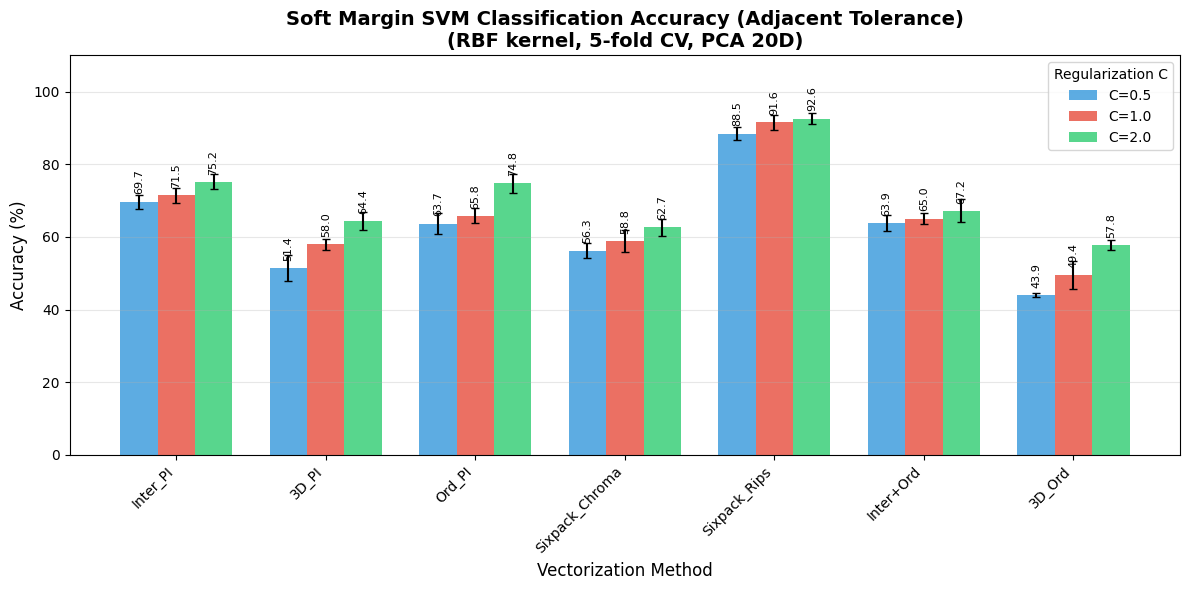


[Plotting results without tolerance (strict)...]

[Saved] soft_svm_results_strict.png


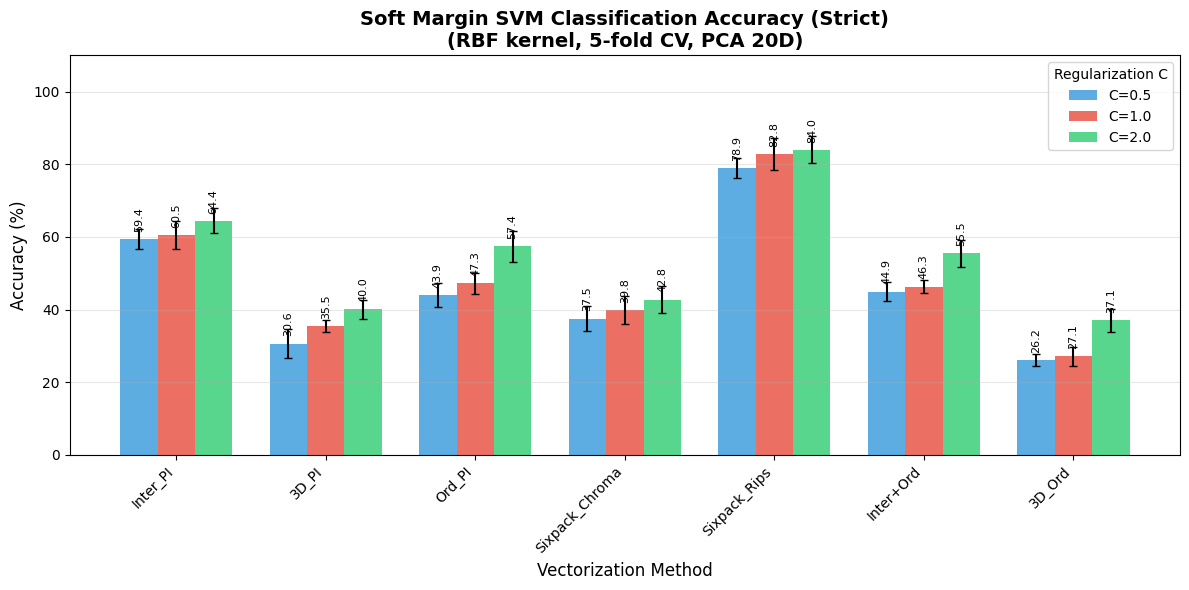


[Saved] soft_svm_results.csv

Results DataFrame:
           Method  Original_Dim  Reduced_Dim  Samples  Acc_C0.5_soft  Std_C0.5_soft  Acc_C0.5_strict  Std_C0.5_strict  Acc_C1.0_soft  Std_C1.0_soft  Acc_C1.0_strict  Std_C1.0_strict  Acc_C2.0_soft  Std_C2.0_soft  Acc_C2.0_strict  Std_C2.0_strict  Acc_KNN_k3_soft  Acc_KNN_k3_strict  Acc_KNN_k12_soft  Acc_KNN_k12_strict  Acc_SVM_RBF_soft  Acc_SVM_RBF_strict  Acc_SVM_Linear_soft  Acc_SVM_Linear_strict  Acc_Random_Forest_soft  Acc_Random_Forest_strict  Acc_Soft-SVM_C0.5_soft  Acc_Soft-SVM_C0.5_strict  Acc_Soft-SVM_C1.0_soft  Acc_Soft-SVM_C1.0_strict  Acc_Soft-SVM_C2.0_soft  Acc_Soft-SVM_C2.0_strict
0        Inter_PI         10200           20      512      69.720160       1.947500        59.364173         2.748944      71.479155       2.063714        60.538740         3.827268      75.191319       2.061835        64.445079         3.446558        80.464496          67.955454         80.858557           69.135732         69.525985           

In [ ]:
# ============================================
# Soft Margin SVM - Final Execution Code (CORRECTED)
# ============================================
#
# [IMPORTANT] Adjacent phase misclassification is IGNORED
# as per Supplementary Note 1:
# "we modified the scoring function to ignore
#  misclassification between adjacent phases"
#
# ============================================

import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================
# CONFIGURATION
# ============================================

C_VALUES = [0.5, 1.0, 2.0]      # Soft margin C parameters
REDUCTION_DIM = 20              # PCA target dimension
N_SPLITS = 5                    # Cross-validation folds
RANDOM_STATE = 42
IGNORE_ADJACENT = True          # <<< KEY SETTING: Ignore adjacent phase errors

# ============================================
# Adjacent Phases Definition (from paper Fig. S1)
# ============================================
# Phase transitions:
# i(dispersed) <-> ii,iii(partial) <-> iv(engulfment) <-> v(mixed)
# v(mixed) <-> vi(stripes) <-> vii,viii(hex) <-> x,xi(hex)
# v(mixed) <-> ix(hex) <-> x,xi(hex)
# v(mixed) <-> xii(labyrinth) <-> vi(stripes)

ADJACENT_PHASES = {
    0: [1, 2],              # i   <-> ii, iii
    1: [0, 3, 4],           # ii  <-> i, iv, v
    2: [0, 3, 4],           # iii <-> i, iv, v
    3: [1, 2, 4],           # iv  <-> ii, iii, v
    4: [1, 2, 3, 5, 8, 11], # v   <-> ii, iii, iv, vi, ix, xii
    5: [4, 6, 7, 11],       # vi  <-> v, vii, viii, xii
    6: [5, 7, 9, 10],       # vii <-> vi, viii, x, xi
    7: [5, 6, 9, 10],       # viii<-> vi, vii, x, xi
    8: [4, 9, 10],          # ix  <-> v, x, xi
    9: [6, 7, 8, 10],       # x   <-> vii, viii, ix, xi
    10: [6, 7, 8, 9],       # xi  <-> vii, viii, ix, x
    11: [4, 5],             # xii <-> v, vi
}

def are_adjacent_phases(label1, label2):
    """Check if two labels are adjacent phases"""
    if label1 == label2:
        return True
    if label1 in ADJACENT_PHASES and label2 in ADJACENT_PHASES[label1]:
        return True
    if label2 in ADJACENT_PHASES and label1 in ADJACENT_PHASES[label2]:
        return True
    return False

def soft_accuracy_score(y_true, y_pred):
    """
    Modified accuracy: adjacent phase misclassifications are counted as CORRECT

    From paper: "we modified the scoring function to ignore
    misclassification between adjacent phases in the accuracy computation"
    """
    n_correct = 0
    for true_label, pred_label in zip(y_true, y_pred):
        if true_label == pred_label:
            n_correct += 1
        elif are_adjacent_phases(int(true_label), int(pred_label)):
            n_correct += 1  # Adjacent misclassification -> counted as correct

    return n_correct / len(y_true) if len(y_true) > 0 else 0.0

def strict_accuracy_score(y_true, y_pred):
    """Standard accuracy (no tolerance for adjacent phases)"""
    return accuracy_score(y_true, y_pred)

# ============================================
# Data Preprocessing (Sixpack dict support)
# ============================================

def flatten_dict_cell(cell):
    if isinstance(cell, dict):
        flat = []
        for key in sorted(cell.keys()):
            val = cell[key]
            if isinstance(val, np.ndarray):
                flat.extend(val.flatten().tolist())
            elif isinstance(val, (list, tuple)):
                flat.extend(list(val))
            else:
                flat.append(float(val))
        return flat
    elif isinstance(cell, np.ndarray):
        return cell.flatten().tolist()
    elif isinstance(cell, (list, tuple)):
        return list(cell)
    else:
        return [float(cell)]

def preprocess_X(X):
    if hasattr(X, 'numpy'):
        X = X.numpy()
    if hasattr(X, 'values'):
        X = X.values
    if not isinstance(X, np.ndarray):
        X = np.array(X)

    if X.dtype == object:
        print("      -> Flattening object dtype...")
        processed_rows = []
        for row in X:
            flat_row = []
            if hasattr(row, '__iter__') and not isinstance(row, (str, dict)):
                for cell in row:
                    flat_row.extend(flatten_dict_cell(cell))
            else:
                flat_row.extend(flatten_dict_cell(row))
            processed_rows.append(flat_row)

        lengths = [len(r) for r in processed_rows]
        if len(set(lengths)) > 1:
            max_len = max(lengths)
            processed_rows = [r + [0.0] * (max_len - len(r)) for r in processed_rows]

        X = np.array(processed_rows, dtype=np.float64)
        print("      -> Shape: {}".format(X.shape))

    X = X.astype(np.float64)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

def preprocess_y(y):
    if hasattr(y, 'numpy'):
        y = y.numpy()
    if hasattr(y, 'values'):
        y = y.values
    return np.array(y).flatten().astype(int)

# ============================================
# Evaluation Functions
# ============================================

def evaluate_soft_margin_svm(X, y, C_values, n_splits, ignore_adjacent=True, verbose=True):
    """
    Evaluate Soft Margin SVM with optional adjacent phase tolerance

    Args:
        ignore_adjacent: If True, use modified scoring (paper method)
                        If False, use standard accuracy
    """
    results = {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for C in C_values:
        accuracies_soft = []  # With adjacent tolerance
        accuracies_strict = []  # Without tolerance

        for train_idx, test_idx in skf.split(X_scaled, y):
            clf = SVC(kernel='rbf', C=C, gamma='scale', random_state=RANDOM_STATE)
            clf.fit(X_scaled[train_idx], y[train_idx])
            y_pred = clf.predict(X_scaled[test_idx])

            # Both metrics
            accuracies_soft.append(soft_accuracy_score(y[test_idx], y_pred))
            accuracies_strict.append(strict_accuracy_score(y[test_idx], y_pred))

        mean_soft = np.mean(accuracies_soft) * 100
        std_soft = np.std(accuracies_soft) * 100
        mean_strict = np.mean(accuracies_strict) * 100
        std_strict = np.std(accuracies_strict) * 100

        results['C={}'.format(C)] = {
            'mean_soft': mean_soft,
            'std_soft': std_soft,
            'mean_strict': mean_strict,
            'std_strict': std_strict
        }

        if verbose:
            if ignore_adjacent:
                print("    Soft-SVM (C={}): {:.2f}% +/- {:.2f}% [adj-tol] | {:.2f}% [strict]".format(
                    C, mean_soft, std_soft, mean_strict))
            else:
                print("    Soft-SVM (C={}): {:.2f}% +/- {:.2f}%".format(C, mean_strict, std_strict))

    return results

def clone_clf(clf):
    if isinstance(clf, KNeighborsClassifier):
        return KNeighborsClassifier(n_neighbors=clf.n_neighbors)
    elif isinstance(clf, SVC):
        return SVC(kernel=clf.kernel, C=clf.C, gamma='scale', random_state=RANDOM_STATE)
    elif isinstance(clf, RandomForestClassifier):
        return RandomForestClassifier(n_estimators=clf.n_estimators, random_state=RANDOM_STATE)
    return clf

def evaluate_all_classifiers(X, y, C_values, n_splits, ignore_adjacent=True):
    """Evaluate all classifiers with both soft and strict accuracy"""
    classifiers = {
        'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
        'KNN (k=12)': KNeighborsClassifier(n_neighbors=12),
        'SVM (RBF)': SVC(kernel='rbf', C=1.0),
        'SVM (Linear)': SVC(kernel='linear', C=1.0),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    }
    for C in C_values:
        classifiers['Soft-SVM (C={})'.format(C)] = SVC(kernel='rbf', C=C, gamma='scale')

    results = {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    for name, clf in classifiers.items():
        accuracies_soft = []
        accuracies_strict = []

        for train_idx, test_idx in skf.split(X, y):
            clf_copy = clone_clf(clf)
            clf_copy.fit(X[train_idx], y[train_idx])
            y_pred = clf_copy.predict(X[test_idx])

            accuracies_soft.append(soft_accuracy_score(y[test_idx], y_pred))
            accuracies_strict.append(strict_accuracy_score(y[test_idx], y_pred))

        results[name] = {
            'mean_soft': np.mean(accuracies_soft) * 100,
            'std_soft': np.std(accuracies_soft) * 100,
            'mean_strict': np.mean(accuracies_strict) * 100,
            'std_strict': np.std(accuracies_strict) * 100
        }

    return results

# ============================================
# Output Functions
# ============================================

def print_soft_svm_table(all_results, C_values, use_soft=True):
    metric = 'soft' if use_soft else 'strict'
    title = "WITH Adjacent Phase Tolerance (Paper Method)" if use_soft else "WITHOUT Tolerance (Strict)"

    print("\n" + "="*115)
    print("Soft Margin SVM Classification Accuracy - {}".format(title))
    print("(RBF kernel, {}-fold CV, PCA {}D)".format(N_SPLITS, REDUCTION_DIM))
    print("="*115)

    header = "{:<25} {:>12} {:>10}".format('Method', 'Dimension', 'Samples')
    for C in C_values:
        header += " {:>22}".format('C=' + str(C))
    print(header)
    print("-"*115)

    for method_name, result in all_results.items():
        row = "{:<25} {:>12} {:>10}".format(
            method_name,
            result.get('original_dim', 'N/A'),
            result.get('samples', 'N/A')
        )
        soft_results = result.get('soft_svm', {})
        for C in C_values:
            key = 'C={}'.format(C)
            if key in soft_results:
                mean = soft_results[key]['mean_{}'.format(metric)]
                std = soft_results[key]['std_{}'.format(metric)]
                row += " {:>10.2f}% +/- {:>5.2f}%".format(mean, std)
            else:
                row += " {:>22}".format('N/A')
        print(row)

    print("="*115)

def print_comparison_table(all_results, use_soft=True):
    metric = 'soft' if use_soft else 'strict'
    title = "Adjacent Tolerance" if use_soft else "Strict"

    print("\n" + "="*170)
    print("Full Classifier Comparison ({})".format(title))
    print("="*170)

    clf_names = ['KNN (k=3)', 'KNN (k=12)', 'SVM (RBF)', 'SVM (Linear)',
                 'Random Forest', 'Soft-SVM (C=0.5)', 'Soft-SVM (C=1.0)', 'Soft-SVM (C=2.0)']

    header = "{:<20} {:>8}".format('Method', 'Dim')
    for clf in clf_names:
        short = clf.replace('Soft-SVM', 'S-SVM')[:14]
        header += " {:>16}".format(short)
    print(header)
    print("-"*170)

    for method_name, result in all_results.items():
        row = "{:<20} {:>8}".format(method_name[:20], result.get('original_dim', 'N/A'))
        clf_results = result.get('classifiers', {})
        for clf in clf_names:
            if clf in clf_results:
                mean = clf_results[clf]['mean_{}'.format(metric)]
                std = clf_results[clf]['std_{}'.format(metric)]
                row += " {:>7.1f}+/-{:<5.1f}%".format(mean, std)
            else:
                row += " {:>16}".format('N/A')
        print(row)

    print("="*170)

def plot_results(all_results, C_values, use_soft=True, save_path=None):
    metric = 'soft' if use_soft else 'strict'
    title_suffix = "(Adjacent Tolerance)" if use_soft else "(Strict)"

    methods = list(all_results.keys())
    x = np.arange(len(methods))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(12, len(methods)*1.5), 6))
    colors = ['#3498db', '#e74c3c', '#2ecc71']

    for i, C in enumerate(C_values):
        means = []
        stds = []
        for m in methods:
            soft_results = all_results[m].get('soft_svm', {})
            key = 'C={}'.format(C)
            if key in soft_results:
                means.append(soft_results[key]['mean_{}'.format(metric)])
                stds.append(soft_results[key]['std_{}'.format(metric)])
            else:
                means.append(0)
                stds.append(0)

        bars = ax.bar(x + i*width, means, width, yerr=stds, label='C={}'.format(C),
                      color=colors[i], capsize=3, alpha=0.8)

        for bar, mean in zip(bars, means):
            if mean > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                       '{:.1f}'.format(mean), ha='center', va='bottom', fontsize=8, rotation=90)

    ax.set_xlabel('Vectorization Method', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Soft Margin SVM Classification Accuracy {}\n(RBF kernel, {}-fold CV, PCA {}D)'.format(
        title_suffix, N_SPLITS, REDUCTION_DIM), fontsize=14, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=10)
    ax.legend(title='Regularization C', fontsize=10)
    ax.set_ylim([0, 110])
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print("\n[Saved] {}".format(save_path))

    plt.show()

def results_to_dataframe(all_results, C_values):
    rows = []
    for method_name, result in all_results.items():
        row = {
            'Method': method_name,
            'Original_Dim': result.get('original_dim'),
            'Reduced_Dim': result.get('reduced_dim'),
            'Samples': result.get('samples'),
        }
        soft_results = result.get('soft_svm', {})
        for C in C_values:
            key = 'C={}'.format(C)
            if key in soft_results:
                row['Acc_C{}_soft'.format(C)] = soft_results[key]['mean_soft']
                row['Std_C{}_soft'.format(C)] = soft_results[key]['std_soft']
                row['Acc_C{}_strict'.format(C)] = soft_results[key]['mean_strict']
                row['Std_C{}_strict'.format(C)] = soft_results[key]['std_strict']

        clf_results = result.get('classifiers', {})
        for clf_name, clf_result in clf_results.items():
            clean_name = clf_name.replace(' ', '_').replace('(', '').replace(')', '').replace('=', '')
            row['Acc_{}_soft'.format(clean_name)] = clf_result['mean_soft']
            row['Acc_{}_strict'.format(clean_name)] = clf_result['mean_strict']

        rows.append(row)

    return pd.DataFrame(rows)

# ============================================
# MAIN EXECUTION
# ============================================

print("="*80)
print("SOFT MARGIN SVM EVALUATION")
print("="*80)
print("Configuration:")
print("  - C values: {}".format(C_VALUES))
print("  - PCA dimension: {}".format(REDUCTION_DIM))
print("  - CV folds: {}".format(N_SPLITS))
print("  - Adjacent phase tolerance: {} <<<".format("ENABLED" if IGNORE_ADJACENT else "DISABLED"))
print("")
print("NOTE: Paper method ignores misclassifications between adjacent phases")
print("      e.g., predicting phase ii when true is phase i counts as CORRECT")
print("="*80)

# Check datasets
if 'datasets' not in dir():
    print("\n[ERROR] 'datasets' variable not found!")
    print("Please load your datasets first.")
else:
    print("\nFound {} datasets: {}".format(len(datasets), list(datasets.keys())))

    # Run evaluation
    all_results = {}

    for method_name, data in datasets.items():
        print("\n" + "-"*60)
        print("[{}]".format(method_name))

        try:
            # Get data
            X = data.get('X', data.get('x', None))
            y = data.get('y', data.get('Y', data.get('labels', None)))

            if X is None or y is None:
                print("  [SKIP] Data not found. Keys: {}".format(list(data.keys())))
                continue

            # Preprocess
            X = preprocess_X(X)
            y = preprocess_y(y)

            original_dim = X.shape[1]
            n_samples = X.shape[0]
            n_classes = len(np.unique(y))

            print("  Shape: {} samples x {} features, {} classes".format(n_samples, original_dim, n_classes))

            # Scaling + PCA
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            if original_dim > REDUCTION_DIM:
                pca = PCA(n_components=REDUCTION_DIM, random_state=RANDOM_STATE)
                X_reduced = pca.fit_transform(X_scaled)
                print("  PCA: {}D -> {}D".format(original_dim, REDUCTION_DIM))
            else:
                X_reduced = X_scaled
                print("  No PCA needed (dim={})".format(original_dim))

            # Soft Margin SVM
            print("  Soft Margin SVM Results:")
            soft_results = evaluate_soft_margin_svm(
                X_reduced, y, C_VALUES, N_SPLITS,
                ignore_adjacent=IGNORE_ADJACENT, verbose=True
            )

            # All classifiers
            clf_results = evaluate_all_classifiers(
                X_reduced, y, C_VALUES, N_SPLITS,
                ignore_adjacent=IGNORE_ADJACENT
            )

            all_results[method_name] = {
                'original_dim': original_dim,
                'reduced_dim': X_reduced.shape[1],
                'samples': n_samples,
                'classes': n_classes,
                'soft_svm': soft_results,
                'classifiers': clf_results
            }

        except Exception as e:
            print("  [ERROR] {}".format(str(e)))
            import traceback
            traceback.print_exc()

    # ============================================
    # OUTPUT RESULTS
    # ============================================

    if len(all_results) > 0:
        # 1. Soft SVM Table - WITH adjacent tolerance (Paper method)
        print_soft_svm_table(all_results, C_VALUES, use_soft=True)

        # 2. Soft SVM Table - WITHOUT tolerance (for comparison)
        print_soft_svm_table(all_results, C_VALUES, use_soft=False)

        # 3. Full Comparison (with tolerance)
        print_comparison_table(all_results, use_soft=True)

        # 4. Visualization (with tolerance - paper method)
        print("\n[Plotting results with adjacent tolerance (paper method)...]")
        plot_results(all_results, C_VALUES, use_soft=True, save_path='soft_svm_results_adjacent_tol.png')

        # 5. Visualization (strict - for comparison)
        print("\n[Plotting results without tolerance (strict)...]")
        plot_results(all_results, C_VALUES, use_soft=False, save_path='soft_svm_results_strict.png')

        # 6. Save to DataFrame
        df_results = results_to_dataframe(all_results, C_VALUES)
        df_results.to_csv('soft_svm_results.csv', index=False)
        print("\n[Saved] soft_svm_results.csv")

        # 7. Display DataFrame
        print("\n" + "="*80)
        print("Results DataFrame:")
        print("="*80)
        display(df_results) if 'display' in dir() else print(df_results.to_string())

        # Store in global variable
        soft_svm_results = all_results
        print("\n[Done] Results stored in 'soft_svm_results' variable")
    else:
        print("\n[WARNING] No valid results generated.")

print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)

In [ ]:
# ============================================
# Soft Margin SVM Hotfix v3 (Clean - No Emojis)
# ============================================

import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("Soft Margin SVM Hotfix v3 Loading...")
print("="*80)

# ============================================
# 1. Adjacent Phases Definition
# ============================================

ADJACENT_PHASES = {
    0: [1, 2], 1: [0, 3, 4], 2: [0, 3, 4], 3: [1, 2, 4],
    4: [1, 2, 3, 5, 8, 11], 5: [4, 6, 7, 11], 6: [5, 7, 9, 10],
    7: [5, 6, 9, 10], 8: [4, 9, 10], 9: [6, 7, 8, 10],
    10: [6, 7, 8, 9], 11: [4, 5],
}

def are_adjacent_phases(label1, label2):
    if label1 == label2:
        return True
    if label1 in ADJACENT_PHASES and label2 in ADJACENT_PHASES[label1]:
        return True
    if label2 in ADJACENT_PHASES and label1 in ADJACENT_PHASES[label2]:
        return True
    return False

def soft_accuracy_score(y_true, y_pred, ignore_adjacent=True):
    if not ignore_adjacent:
        return accuracy_score(y_true, y_pred)
    n_correct = sum(1 for t, p in zip(y_true, y_pred)
                    if t == p or are_adjacent_phases(t, p))
    return n_correct / len(y_true) if len(y_true) > 0 else 0.0

# ============================================
# 2. Data Preprocessing (Sixpack Support)
# ============================================

def flatten_dict_cell(cell):
    """
    Flatten dict cell: {0: array([...]), 1: array([...])} -> [...]
    """
    if isinstance(cell, dict):
        flat = []
        for key in sorted(cell.keys()):
            val = cell[key]
            if isinstance(val, np.ndarray):
                flat.extend(val.flatten().tolist())
            elif isinstance(val, (list, tuple)):
                flat.extend(list(val))
            else:
                flat.append(float(val))
        return flat
    elif isinstance(cell, np.ndarray):
        return cell.flatten().tolist()
    elif isinstance(cell, (list, tuple)):
        return list(cell)
    else:
        return [float(cell)]

def preprocess_X(X):
    """
    Convert various X formats to numpy array
    Supports: numpy array, object dtype with dict cells, list, DataFrame, tensor
    """
    # PyTorch tensor
    if hasattr(X, 'numpy'):
        X = X.numpy()

    # pandas DataFrame
    if hasattr(X, 'values'):
        X = X.values

    # Convert to numpy
    if not isinstance(X, np.ndarray):
        X = np.array(X)

    # Handle object dtype (Sixpack etc.)
    if X.dtype == object:
        print("      -> object dtype detected, flattening...")
        processed_rows = []

        for i, row in enumerate(X):
            flat_row = []

            if hasattr(row, '__iter__') and not isinstance(row, (str, dict)):
                for cell in row:
                    flat_row.extend(flatten_dict_cell(cell))
            else:
                flat_row.extend(flatten_dict_cell(row))

            processed_rows.append(flat_row)

        # Pad if lengths differ
        lengths = [len(r) for r in processed_rows]
        if len(set(lengths)) > 1:
            max_len = max(lengths)
            processed_rows = [r + [0.0] * (max_len - len(r)) for r in processed_rows]

        X = np.array(processed_rows, dtype=np.float64)
        print("      -> Converted: {}".format(X.shape))

    # Convert to float64 and handle NaN
    X = X.astype(np.float64)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    return X

def preprocess_y(y):
    """Preprocess labels"""
    if hasattr(y, 'numpy'):
        y = y.numpy()
    if hasattr(y, 'values'):
        y = y.values
    return np.array(y).flatten()

def check_dataset_structure(datasets, verbose=True):
    """Check and preprocess dataset structure"""
    if verbose:
        print("\n[Dataset Structure Check]")
        print("-"*80)

    valid_datasets = {}

    for name, data in datasets.items():
        X = data.get('X', data.get('x', None))
        y = data.get('y', data.get('Y', data.get('labels', None)))

        if X is None or y is None:
            if verbose:
                print("  [X] {}: X or y not found".format(name))
            continue

        try:
            if verbose:
                print("  > {}:".format(name))
                print("      Original: shape={}, dtype={}".format(
                    getattr(X, 'shape', 'N/A'), getattr(X, 'dtype', type(X).__name__)))

            X_processed = preprocess_X(X)
            y_processed = preprocess_y(y)

            if verbose:
                print("      Result: {}, {} classes".format(
                    X_processed.shape, len(np.unique(y_processed))))

            valid_datasets[name] = {'X': X_processed, 'y': y_processed}

        except Exception as e:
            if verbose:
                print("  [X] {}: Failed - {}".format(name, str(e)[:60]))

    if verbose:
        print("-"*80)
        print("Valid datasets: {}/{}".format(len(valid_datasets), len(datasets)))

    return valid_datasets

# ============================================
# 3. Soft Margin SVM Evaluation
# ============================================

def evaluate_soft_margin_svm(X, y, C_values=[0.5, 1.0, 2.0], n_splits=5,
                              ignore_adjacent=False, verbose=True):
    """Soft Margin SVM evaluation"""
    results = {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for C in C_values:
        accuracies = []
        for train_idx, test_idx in skf.split(X_scaled, y):
            clf = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
            clf.fit(X_scaled[train_idx], y[train_idx])
            y_pred = clf.predict(X_scaled[test_idx])

            if ignore_adjacent:
                acc = soft_accuracy_score(y[test_idx], y_pred, ignore_adjacent=True)
            else:
                acc = accuracy_score(y[test_idx], y_pred)
            accuracies.append(acc)

        mean_acc = np.mean(accuracies) * 100
        std_acc = np.std(accuracies) * 100
        results['C={}'.format(C)] = {'mean': mean_acc, 'std': std_acc, 'C': C}

        if verbose:
            adj_str = " (adj)" if ignore_adjacent else ""
            print("    Soft-SVM (C={}){}: {:.2f}% +/- {:.2f}%".format(
                C, adj_str, mean_acc, std_acc))

    return results

def clone_clf(clf):
    if isinstance(clf, KNeighborsClassifier):
        return KNeighborsClassifier(n_neighbors=clf.n_neighbors)
    elif isinstance(clf, SVC):
        return SVC(kernel=clf.kernel, C=clf.C, gamma='scale', random_state=42)
    elif isinstance(clf, RandomForestClassifier):
        return RandomForestClassifier(n_estimators=clf.n_estimators, random_state=42)
    return clf

def evaluate_classifiers_with_soft_svm(X, y, n_splits=5, C_values=[0.5, 1.0, 2.0], verbose=False):
    """All classifiers + Soft Margin SVM evaluation"""
    classifiers = {
        'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
        'KNN (k=12)': KNeighborsClassifier(n_neighbors=12),
        'SVM (RBF)': SVC(kernel='rbf', C=1.0),
        'SVM (Linear)': SVC(kernel='linear', C=1.0),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    }
    for C in C_values:
        classifiers['Soft-SVM (C={})'.format(C)] = SVC(kernel='rbf', C=C, gamma='scale')

    results = {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for name, clf in classifiers.items():
        accuracies = []
        for train_idx, test_idx in skf.split(X, y):
            clf_copy = clone_clf(clf)
            clf_copy.fit(X[train_idx], y[train_idx])
            y_pred = clf_copy.predict(X[test_idx])
            accuracies.append(accuracy_score(y[test_idx], y_pred))

        results[name] = {'mean': np.mean(accuracies) * 100, 'std': np.std(accuracies) * 100}
        if verbose:
            print("    {}: {:.2f}% +/- {:.2f}%".format(
                name, results[name]['mean'], results[name]['std']))

    return results

# ============================================
# 4. Result Output Functions
# ============================================

def print_soft_svm_table(all_results, C_values=[0.5, 1.0, 2.0]):
    """Print Soft Margin SVM results table"""
    print("\n" + "="*100)
    print("Soft Margin SVM Classification Accuracy")
    print("(RBF kernel, 5-fold Cross-Validation)")
    print("="*100)

    header = "{:<25} {:>10} {:>10}".format('Method', 'Dim', 'Samples')
    for C in C_values:
        header += " {:>18}".format('C=' + str(C))
    print(header)
    print("-"*100)

    for method_name, result in all_results.items():
        row = "{:<25}".format(method_name)
        row += " {:>10}".format(result.get('original_dim', 'N/A'))
        row += " {:>10}".format(result.get('samples', 'N/A'))

        soft_results = result.get('soft_svm', {})
        for C in C_values:
            key = 'C={}'.format(C)
            if key in soft_results:
                mean = soft_results[key]['mean']
                std = soft_results[key]['std']
                row += " {:>7.2f}% +/- {:>4.2f}%".format(mean, std)
            else:
                row += " {:>18}".format('N/A')

        print(row)

    print("="*100)

def print_full_comparison_table(all_results):
    """Print full classifier comparison table"""
    print("\n" + "="*160)
    print("Full Classification Comparison")
    print("="*160)

    clf_names = ['KNN (k=3)', 'KNN (k=12)', 'SVM (RBF)', 'SVM (Linear)',
                 'Random Forest', 'Soft-SVM (C=0.5)', 'Soft-SVM (C=1.0)', 'Soft-SVM (C=2.0)']

    header = "{:<18} {:>6}".format('Method', 'Dim')
    for clf in clf_names:
        short = clf.replace('Soft-SVM', 'S-SVM').replace(' ', '')[:10]
        header += " {:>12}".format(short)
    print(header)
    print("-"*160)

    for method_name, result in all_results.items():
        row = "{:<18} {:>6}".format(method_name, result.get('original_dim', 'N/A'))
        clf_results = result.get('classifiers', {})
        for clf in clf_names:
            if clf in clf_results:
                mean = clf_results[clf]['mean']
                row += " {:>10.1f}%".format(mean)
            else:
                row += " {:>12}".format('N/A')
        print(row)

    print("="*160)

# ============================================
# 5. Main Evaluation Pipeline
# ============================================

def run_soft_svm_evaluation(datasets, reduction_dim=20, C_values=[0.5, 1.0, 2.0],
                             verbose=True, skip_errors=True):
    """
    Run Soft Margin SVM evaluation on all datasets
    """
    all_results = {}

    print("\n" + "="*100)
    print("Soft Margin SVM Evaluation (PCA -> {}D)".format(reduction_dim))
    print("="*100)

    for method_name, data in datasets.items():
        if verbose:
            print("\n[{}]".format(method_name))

        try:
            # Extract data
            X = data.get('X', data.get('x', None))
            y = data.get('y', data.get('Y', data.get('labels', None)))

            if X is None or y is None:
                print("   Warning: Data not found. keys: {}".format(list(data.keys())))
                continue

            # Preprocess (auto-handles Sixpack dict structure)
            X = preprocess_X(X)
            y = preprocess_y(y)

            original_dim = X.shape[1]

            # Scaling + PCA
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            if original_dim > reduction_dim:
                pca = PCA(n_components=reduction_dim, random_state=42)
                X_reduced = pca.fit_transform(X_scaled)
                if verbose:
                    print("   Dimension: {}D -> {}D (PCA)".format(original_dim, reduction_dim))
            else:
                X_reduced = X_scaled
                if verbose:
                    print("   Dimension: {}D (no reduction)".format(original_dim))

            # Soft Margin SVM evaluation
            soft_results = evaluate_soft_margin_svm(
                X_reduced, y, C_values=C_values, n_splits=5,
                ignore_adjacent=False, verbose=verbose
            )

            # All classifiers evaluation
            clf_results = evaluate_classifiers_with_soft_svm(
                X_reduced, y, C_values=C_values, verbose=False
            )

            all_results[method_name] = {
                'original_dim': original_dim,
                'reduced_dim': X_reduced.shape[1],
                'samples': X.shape[0],
                'classes': len(np.unique(y)),
                'soft_svm': soft_results,
                'classifiers': clf_results
            }

        except Exception as e:
            if skip_errors:
                print("   Error: {}".format(str(e)[:80]))
                import traceback
                traceback.print_exc()
                continue
            else:
                raise e

    # Print results table
    if len(all_results) > 0:
        print_soft_svm_table(all_results, C_values)
    else:
        print("\nWarning: No valid results.")

    return all_results

# ============================================
# 6. DataFrame and Visualization
# ============================================

def results_to_dataframe(all_results, C_values=[0.5, 1.0, 2.0]):
    rows = []
    for method_name, result in all_results.items():
        row = {
            'Method': method_name,
            'Original_Dim': result.get('original_dim'),
            'Reduced_Dim': result.get('reduced_dim'),
            'Samples': result.get('samples'),
        }
        soft_results = result.get('soft_svm', {})
        for C in C_values:
            key = 'C={}'.format(C)
            if key in soft_results:
                row['Acc_C={}'.format(C)] = "{:.2f}".format(soft_results[key]['mean'])
                row['Std_C={}'.format(C)] = "{:.2f}".format(soft_results[key]['std'])
        rows.append(row)
    return pd.DataFrame(rows)

def plot_soft_svm_results(all_results, C_values=[0.5, 1.0, 2.0], save_path=None):
    try:
        import matplotlib.pyplot as plt
    except:
        print("matplotlib required")
        return

    methods = list(all_results.keys())
    x = np.arange(len(methods))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))
    colors = ['#3498db', '#e74c3c', '#2ecc71']

    for i, C in enumerate(C_values):
        means = [all_results[m].get('soft_svm', {}).get('C={}'.format(C), {}).get('mean', 0) for m in methods]
        stds = [all_results[m].get('soft_svm', {}).get('C={}'.format(C), {}).get('std', 0) for m in methods]
        ax.bar(x + i*width, means, width, yerr=stds, label='C={}'.format(C), color=colors[i], capsize=3, alpha=0.8)

    ax.set_xlabel('Method')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Soft Margin SVM Classification Accuracy (RBF, 5-fold CV)')
    ax.set_xticks(x + width)
    ax.set_xticklabels(methods, rotation=30, ha='right')
    ax.legend(title='C')
    ax.set_ylim([0, 105])
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ============================================
# Done
# ============================================

print("\n[OK] Soft Margin SVM Hotfix v3 Loaded!")
print("\nUsage:")
print("   results = run_soft_svm_evaluation(datasets)")
print("="*80)

Soft Margin SVM Hotfix v3 Loading...

[OK] Soft Margin SVM Hotfix v3 Loaded!

Usage:
   results = run_soft_svm_evaluation(datasets)


SOFT MARGIN SVM EVALUATION
Configuration:
  - C values: [0.5, 1.0, 2.0]
  - PCA dimension: 20
  - CV folds: 5

Found 7 datasets: ['Inter_PI', '3D_PI', 'Ord_PI', 'Sixpack_Chroma', 'Sixpack_Rips', 'Inter+Ord', '3D_Ord']

------------------------------------------------------------
[Inter_PI]
  Shape: 512 samples x 10200 features, 12 classes
  PCA: 10200D -> 20D
  Soft Margin SVM:
    Soft-SVM (C=0.5): 59.36% +/- 2.75%
    Soft-SVM (C=1.0): 60.54% +/- 3.83%
    Soft-SVM (C=2.0): 64.45% +/- 3.45%

------------------------------------------------------------
[3D_PI]
  Shape: 512 samples x 16800 features, 12 classes
  PCA: 16800D -> 20D
  Soft Margin SVM:
    Soft-SVM (C=0.5): 30.65% +/- 4.01%
    Soft-SVM (C=1.0): 35.55% +/- 1.67%
    Soft-SVM (C=2.0): 40.03% +/- 2.56%

------------------------------------------------------------
[Ord_PI]
  Shape: 512 samples x 10200 features, 12 classes
  PCA: 10200D -> 20D
  Soft Margin SVM:
    Soft-SVM (C=0.5): 43.95% +/- 3.33%
    Soft-SVM (C=1.0): 47.

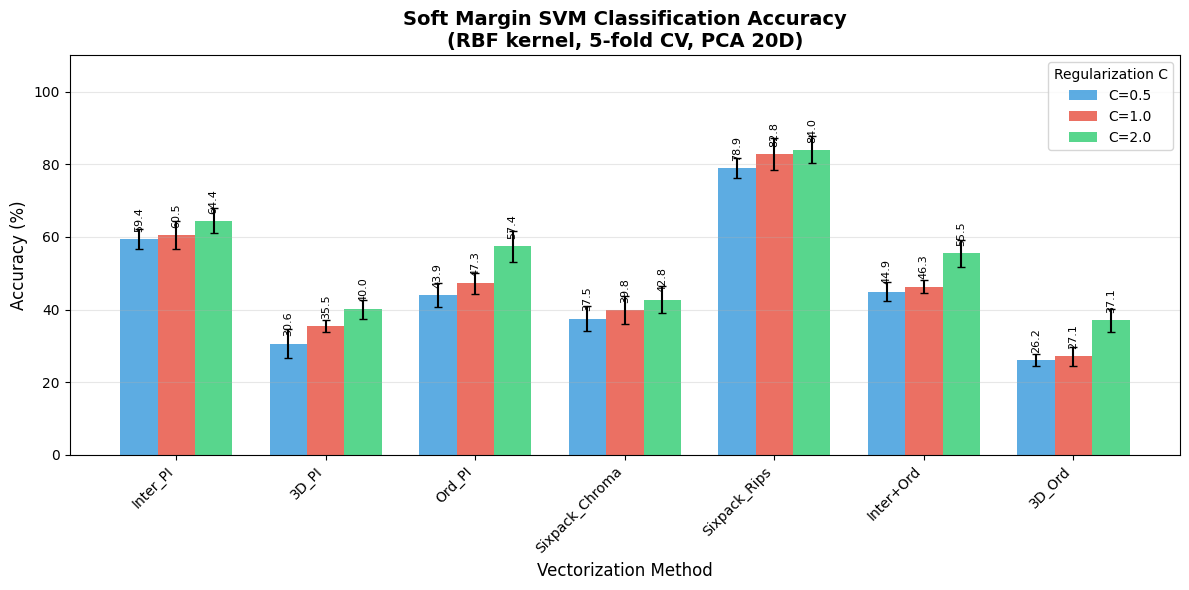


[Saved] soft_svm_results.csv

Results DataFrame:
           Method  Original_Dim  Reduced_Dim  Samples   Acc_C0.5  Std_C0.5  \
0        Inter_PI         10200           20      512  59.364173  2.748944   
1           3D_PI         16800           20      512  30.649153  4.010762   
2          Ord_PI         10200           20      512  43.946316  3.327871   
3  Sixpack_Chroma         61200           20      512  37.496669  3.477464   
4    Sixpack_Rips           288           20      512  78.907291  2.722780   
5       Inter+Ord         20400           20      512  44.920998  2.662202   
6          3D_Ord         27000           20      512  26.173615  1.695065   

    Acc_C1.0  Std_C1.0   Acc_C2.0  Std_C2.0  Acc_KNN_k3  Acc_KNN_k12  \
0  60.538740  3.827268  64.445079  3.446558   67.955454    69.135732   
1  35.545403  1.669128  40.030459  2.555838   60.930897    64.062441   
2  47.262517  2.927419  57.422425  4.308841   68.162955    70.112317   
3  39.838188  3.848072  42.773653  3.

In [ ]:
# ============================================
# Soft Margin SVM - Final Execution Code
# ============================================
#
# [사용법]
# 1. 이 코드 전체를 Jupyter Notebook 셀에 복사
# 2. datasets가 이미 로드된 상태에서 실행
# 3. 결과 테이블 및 시각화 자동 출력
#
# Reference: Supplementary Note 1, Table 7, 8
# "Topological Data Analysis of Spatial Patterning"
# ============================================

import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================
# CONFIGURATION
# ============================================

C_VALUES = [0.5, 1.0, 2.0]      # Soft margin C parameters
REDUCTION_DIM = 20              # PCA target dimension
N_SPLITS = 5                    # Cross-validation folds
RANDOM_STATE = 42

# ============================================
# Adjacent Phases (from paper)
# ============================================

ADJACENT_PHASES = {
    0: [1, 2], 1: [0, 3, 4], 2: [0, 3, 4], 3: [1, 2, 4],
    4: [1, 2, 3, 5, 8, 11], 5: [4, 6, 7, 11], 6: [5, 7, 9, 10],
    7: [5, 6, 9, 10], 8: [4, 9, 10], 9: [6, 7, 8, 10],
    10: [6, 7, 8, 9], 11: [4, 5],
}

def are_adjacent_phases(label1, label2):
    if label1 == label2:
        return True
    if label1 in ADJACENT_PHASES and label2 in ADJACENT_PHASES[label1]:
        return True
    if label2 in ADJACENT_PHASES and label1 in ADJACENT_PHASES[label2]:
        return True
    return False

def soft_accuracy_score(y_true, y_pred, ignore_adjacent=True):
    if not ignore_adjacent:
        return accuracy_score(y_true, y_pred)
    n_correct = sum(1 for t, p in zip(y_true, y_pred)
                    if t == p or are_adjacent_phases(t, p))
    return n_correct / len(y_true) if len(y_true) > 0 else 0.0

# ============================================
# Data Preprocessing (Sixpack dict support)
# ============================================

def flatten_dict_cell(cell):
    if isinstance(cell, dict):
        flat = []
        for key in sorted(cell.keys()):
            val = cell[key]
            if isinstance(val, np.ndarray):
                flat.extend(val.flatten().tolist())
            elif isinstance(val, (list, tuple)):
                flat.extend(list(val))
            else:
                flat.append(float(val))
        return flat
    elif isinstance(cell, np.ndarray):
        return cell.flatten().tolist()
    elif isinstance(cell, (list, tuple)):
        return list(cell)
    else:
        return [float(cell)]

def preprocess_X(X):
    if hasattr(X, 'numpy'):
        X = X.numpy()
    if hasattr(X, 'values'):
        X = X.values
    if not isinstance(X, np.ndarray):
        X = np.array(X)

    if X.dtype == object:
        print("      -> Flattening object dtype...")
        processed_rows = []
        for row in X:
            flat_row = []
            if hasattr(row, '__iter__') and not isinstance(row, (str, dict)):
                for cell in row:
                    flat_row.extend(flatten_dict_cell(cell))
            else:
                flat_row.extend(flatten_dict_cell(row))
            processed_rows.append(flat_row)

        lengths = [len(r) for r in processed_rows]
        if len(set(lengths)) > 1:
            max_len = max(lengths)
            processed_rows = [r + [0.0] * (max_len - len(r)) for r in processed_rows]

        X = np.array(processed_rows, dtype=np.float64)
        print("      -> Shape: {}".format(X.shape))

    X = X.astype(np.float64)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

def preprocess_y(y):
    if hasattr(y, 'numpy'):
        y = y.numpy()
    if hasattr(y, 'values'):
        y = y.values
    return np.array(y).flatten()

# ============================================
# Evaluation Functions
# ============================================

def evaluate_soft_margin_svm(X, y, C_values, n_splits, verbose=True):
    results = {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for C in C_values:
        accuracies = []
        for train_idx, test_idx in skf.split(X_scaled, y):
            clf = SVC(kernel='rbf', C=C, gamma='scale', random_state=RANDOM_STATE)
            clf.fit(X_scaled[train_idx], y[train_idx])
            y_pred = clf.predict(X_scaled[test_idx])
            accuracies.append(accuracy_score(y[test_idx], y_pred))

        mean_acc = np.mean(accuracies) * 100
        std_acc = np.std(accuracies) * 100
        results['C={}'.format(C)] = {'mean': mean_acc, 'std': std_acc}

        if verbose:
            print("    Soft-SVM (C={}): {:.2f}% +/- {:.2f}%".format(C, mean_acc, std_acc))

    return results

def clone_clf(clf):
    if isinstance(clf, KNeighborsClassifier):
        return KNeighborsClassifier(n_neighbors=clf.n_neighbors)
    elif isinstance(clf, SVC):
        return SVC(kernel=clf.kernel, C=clf.C, gamma='scale', random_state=RANDOM_STATE)
    elif isinstance(clf, RandomForestClassifier):
        return RandomForestClassifier(n_estimators=clf.n_estimators, random_state=RANDOM_STATE)
    return clf

def evaluate_all_classifiers(X, y, C_values, n_splits):
    classifiers = {
        'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
        'KNN (k=12)': KNeighborsClassifier(n_neighbors=12),
        'SVM (RBF)': SVC(kernel='rbf', C=1.0),
        'SVM (Linear)': SVC(kernel='linear', C=1.0),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    }
    for C in C_values:
        classifiers['Soft-SVM (C={})'.format(C)] = SVC(kernel='rbf', C=C, gamma='scale')

    results = {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    for name, clf in classifiers.items():
        accuracies = []
        for train_idx, test_idx in skf.split(X, y):
            clf_copy = clone_clf(clf)
            clf_copy.fit(X[train_idx], y[train_idx])
            y_pred = clf_copy.predict(X[test_idx])
            accuracies.append(accuracy_score(y[test_idx], y_pred))
        results[name] = {'mean': np.mean(accuracies) * 100, 'std': np.std(accuracies) * 100}

    return results

# ============================================
# Output Functions
# ============================================

def print_soft_svm_table(all_results, C_values):
    print("\n" + "="*110)
    print("Soft Margin SVM Classification Accuracy (RBF kernel, {}-fold CV)".format(N_SPLITS))
    print("="*110)

    header = "{:<25} {:>12} {:>10}".format('Method', 'Dimension', 'Samples')
    for C in C_values:
        header += " {:>20}".format('C=' + str(C))
    print(header)
    print("-"*110)

    for method_name, result in all_results.items():
        row = "{:<25} {:>12} {:>10}".format(
            method_name,
            result.get('original_dim', 'N/A'),
            result.get('samples', 'N/A')
        )
        soft_results = result.get('soft_svm', {})
        for C in C_values:
            key = 'C={}'.format(C)
            if key in soft_results:
                mean = soft_results[key]['mean']
                std = soft_results[key]['std']
                row += " {:>8.2f}% +/- {:>5.2f}%".format(mean, std)
            else:
                row += " {:>20}".format('N/A')
        print(row)

    print("="*110)

def print_full_comparison(all_results):
    print("\n" + "="*150)
    print("Full Classifier Comparison")
    print("="*150)

    clf_names = ['KNN (k=3)', 'KNN (k=12)', 'SVM (RBF)', 'SVM (Linear)',
                 'Random Forest', 'Soft-SVM (C=0.5)', 'Soft-SVM (C=1.0)', 'Soft-SVM (C=2.0)']

    header = "{:<20} {:>8}".format('Method', 'Dim')
    for clf in clf_names:
        short = clf.replace('Soft-SVM', 'S-SVM')[:12]
        header += " {:>14}".format(short)
    print(header)
    print("-"*150)

    for method_name, result in all_results.items():
        row = "{:<20} {:>8}".format(method_name[:20], result.get('original_dim', 'N/A'))
        clf_results = result.get('classifiers', {})
        for clf in clf_names:
            if clf in clf_results:
                mean = clf_results[clf]['mean']
                std = clf_results[clf]['std']
                row += " {:>6.1f}+/-{:<4.1f}%".format(mean, std)
            else:
                row += " {:>14}".format('N/A')
        print(row)

    print("="*150)

def plot_results(all_results, C_values, save_path=None):
    methods = list(all_results.keys())
    x = np.arange(len(methods))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(12, len(methods)*1.5), 6))
    colors = ['#3498db', '#e74c3c', '#2ecc71']

    for i, C in enumerate(C_values):
        means = [all_results[m].get('soft_svm', {}).get('C={}'.format(C), {}).get('mean', 0) for m in methods]
        stds = [all_results[m].get('soft_svm', {}).get('C={}'.format(C), {}).get('std', 0) for m in methods]
        bars = ax.bar(x + i*width, means, width, yerr=stds, label='C={}'.format(C),
                      color=colors[i], capsize=3, alpha=0.8)

        # Add value labels
        for bar, mean in zip(bars, means):
            if mean > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                       '{:.1f}'.format(mean), ha='center', va='bottom', fontsize=8, rotation=90)

    ax.set_xlabel('Vectorization Method', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Soft Margin SVM Classification Accuracy\n(RBF kernel, {}-fold CV, PCA {}D)'.format(N_SPLITS, REDUCTION_DIM),
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=10)
    ax.legend(title='Regularization C', fontsize=10)
    ax.set_ylim([0, 110])
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print("\n[Saved] {}".format(save_path))

    plt.show()

def results_to_dataframe(all_results, C_values):
    rows = []
    for method_name, result in all_results.items():
        row = {
            'Method': method_name,
            'Original_Dim': result.get('original_dim'),
            'Reduced_Dim': result.get('reduced_dim'),
            'Samples': result.get('samples'),
        }
        soft_results = result.get('soft_svm', {})
        for C in C_values:
            key = 'C={}'.format(C)
            if key in soft_results:
                row['Acc_C{}'.format(C)] = soft_results[key]['mean']
                row['Std_C{}'.format(C)] = soft_results[key]['std']

        clf_results = result.get('classifiers', {})
        for clf_name, clf_result in clf_results.items():
            clean_name = clf_name.replace(' ', '_').replace('(', '').replace(')', '').replace('=', '')
            row['Acc_{}'.format(clean_name)] = clf_result['mean']

        rows.append(row)

    return pd.DataFrame(rows)

# ============================================
# MAIN EXECUTION
# ============================================

print("="*80)
print("SOFT MARGIN SVM EVALUATION")
print("="*80)
print("Configuration:")
print("  - C values: {}".format(C_VALUES))
print("  - PCA dimension: {}".format(REDUCTION_DIM))
print("  - CV folds: {}".format(N_SPLITS))
print("="*80)

# Check datasets
if 'datasets' not in dir():
    print("\n[ERROR] 'datasets' variable not found!")
    print("Please load your datasets first.")
else:
    print("\nFound {} datasets: {}".format(len(datasets), list(datasets.keys())))

    # Run evaluation
    all_results = {}

    for method_name, data in datasets.items():
        print("\n" + "-"*60)
        print("[{}]".format(method_name))

        try:
            # Get data
            X = data.get('X', data.get('x', None))
            y = data.get('y', data.get('Y', data.get('labels', None)))

            if X is None or y is None:
                print("  [SKIP] Data not found. Keys: {}".format(list(data.keys())))
                continue

            # Preprocess
            X = preprocess_X(X)
            y = preprocess_y(y)

            original_dim = X.shape[1]
            n_samples = X.shape[0]
            n_classes = len(np.unique(y))

            print("  Shape: {} samples x {} features, {} classes".format(n_samples, original_dim, n_classes))

            # Scaling + PCA
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            if original_dim > REDUCTION_DIM:
                pca = PCA(n_components=REDUCTION_DIM, random_state=RANDOM_STATE)
                X_reduced = pca.fit_transform(X_scaled)
                print("  PCA: {}D -> {}D".format(original_dim, REDUCTION_DIM))
            else:
                X_reduced = X_scaled
                print("  No PCA needed (dim={})".format(original_dim))

            # Soft Margin SVM
            print("  Soft Margin SVM:")
            soft_results = evaluate_soft_margin_svm(X_reduced, y, C_VALUES, N_SPLITS, verbose=True)

            # All classifiers
            clf_results = evaluate_all_classifiers(X_reduced, y, C_VALUES, N_SPLITS)

            all_results[method_name] = {
                'original_dim': original_dim,
                'reduced_dim': X_reduced.shape[1],
                'samples': n_samples,
                'classes': n_classes,
                'soft_svm': soft_results,
                'classifiers': clf_results
            }

        except Exception as e:
            print("  [ERROR] {}".format(str(e)))
            import traceback
            traceback.print_exc()

    # ============================================
    # OUTPUT RESULTS
    # ============================================

    if len(all_results) > 0:
        # 1. Soft SVM Table (Supplementary Table 7, 8 style)
        print_soft_svm_table(all_results, C_VALUES)

        # 2. Full Comparison Table
        print_full_comparison(all_results)

        # 3. Visualization
        print("\n[Plotting results...]")
        plot_results(all_results, C_VALUES, save_path='soft_svm_results.png')

        # 4. Save to DataFrame
        df_results = results_to_dataframe(all_results, C_VALUES)
        df_results.to_csv('soft_svm_results.csv', index=False)
        print("\n[Saved] soft_svm_results.csv")

        # 5. Display DataFrame
        print("\n" + "="*80)
        print("Results DataFrame:")
        print("="*80)
        display(df_results) if 'display' in dir() else print(df_results)

        # Store in global variable
        soft_svm_results = all_results
        print("\n[Done] Results stored in 'soft_svm_results' variable")
    else:
        print("\n[WARNING] No valid results generated.")

print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)

SOFT MARGIN SVM EVALUATION
Configuration:
  - C values: [0.5, 1.0, 2.0]
  - PCA dimension: 20
  - CV folds: 5
  - Adjacent phase tolerance: ENABLED <<<

NOTE: Paper method ignores misclassifications between adjacent phases
      e.g., predicting phase ii when true is phase i counts as CORRECT

Found 7 datasets: ['Inter_PI', '3D_PI', 'Ord_PI', 'Sixpack_Chroma', 'Sixpack_Rips', 'Inter+Ord', '3D_Ord']

------------------------------------------------------------
[Inter_PI]
  Shape: 512 samples x 10200 features, 12 classes
  PCA: 10200D -> 20D
  Soft Margin SVM Results:
    Soft-SVM (C=0.5): 69.72% +/- 1.95% [adj-tol] | 59.36% [strict]
    Soft-SVM (C=1.0): 71.48% +/- 2.06% [adj-tol] | 60.54% [strict]
    Soft-SVM (C=2.0): 75.19% +/- 2.06% [adj-tol] | 64.45% [strict]

------------------------------------------------------------
[3D_PI]
  Shape: 512 samples x 16800 features, 12 classes
  PCA: 16800D -> 20D
  Soft Margin SVM Results:
    Soft-SVM (C=0.5): 51.36% +/- 3.57% [adj-tol] | 30.65% 

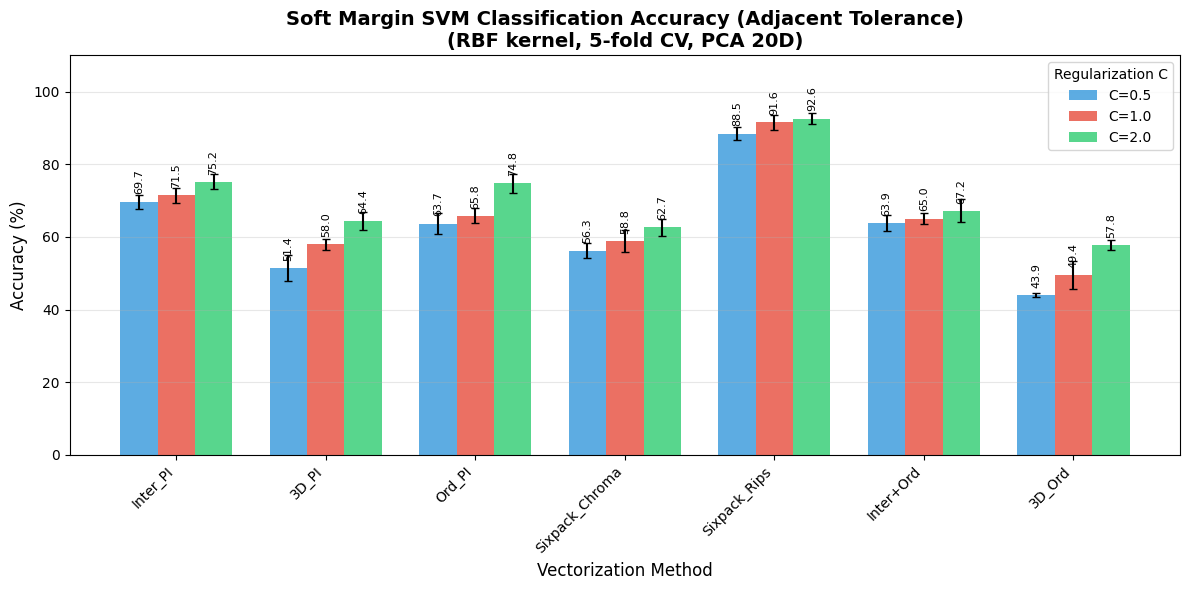


[Plotting results without tolerance (strict)...]

[Saved] soft_svm_results_strict.png


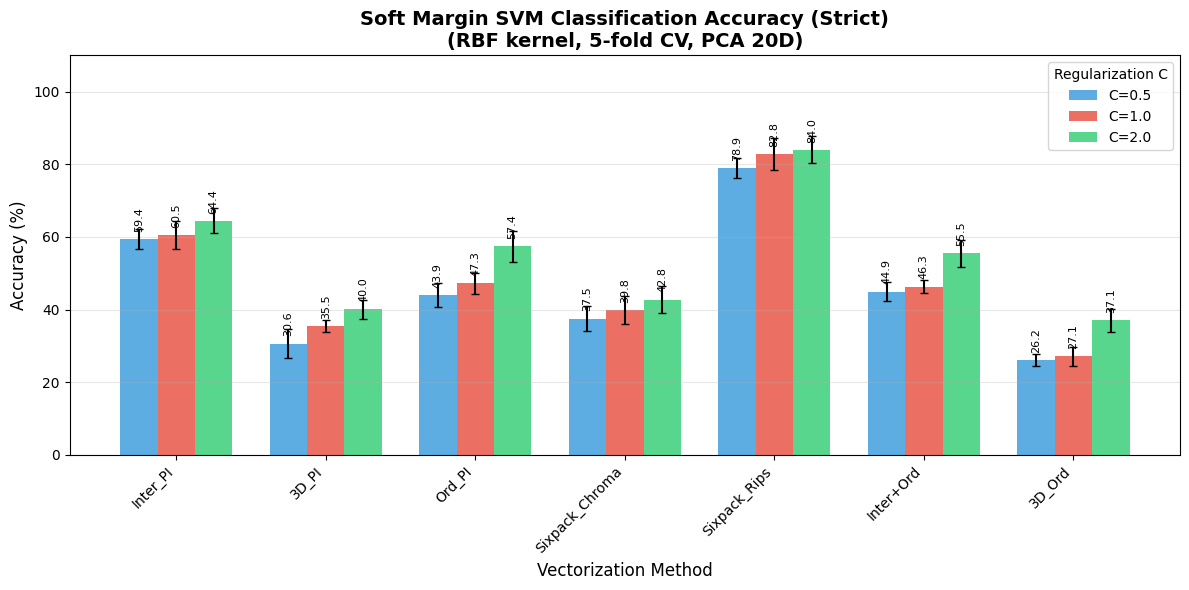


[Saved] soft_svm_results.csv

Results DataFrame:
           Method  Original_Dim  Reduced_Dim  Samples  Acc_C0.5_soft  Std_C0.5_soft  Acc_C0.5_strict  Std_C0.5_strict  Acc_C1.0_soft  Std_C1.0_soft  Acc_C1.0_strict  Std_C1.0_strict  Acc_C2.0_soft  Std_C2.0_soft  Acc_C2.0_strict  Std_C2.0_strict  Acc_KNN_k3_soft  Acc_KNN_k3_strict  Acc_KNN_k12_soft  Acc_KNN_k12_strict  Acc_SVM_RBF_soft  Acc_SVM_RBF_strict  Acc_SVM_Linear_soft  Acc_SVM_Linear_strict  Acc_Random_Forest_soft  Acc_Random_Forest_strict  Acc_Soft-SVM_C0.5_soft  Acc_Soft-SVM_C0.5_strict  Acc_Soft-SVM_C1.0_soft  Acc_Soft-SVM_C1.0_strict  Acc_Soft-SVM_C2.0_soft  Acc_Soft-SVM_C2.0_strict
0        Inter_PI         10200           20      512      69.720160       1.947500        59.364173         2.748944      71.479155       2.063714        60.538740         3.827268      75.191319       2.061835        64.445079         3.446558        80.464496          67.955454         80.858557           69.135732         69.525985           

In [ ]:
# ============================================
# Soft Margin SVM - Final Execution Code (CORRECTED)
# ============================================
#
# [IMPORTANT] Adjacent phase misclassification is IGNORED
# as per Supplementary Note 1:
# "we modified the scoring function to ignore
#  misclassification between adjacent phases"
#
# ============================================

import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================
# CONFIGURATION
# ============================================

C_VALUES = [0.5, 1.0, 2.0]      # Soft margin C parameters
REDUCTION_DIM = 20              # PCA target dimension
N_SPLITS = 5                    # Cross-validation folds
RANDOM_STATE = 42
IGNORE_ADJACENT = True          # <<< KEY SETTING: Ignore adjacent phase errors

# ============================================
# Adjacent Phases Definition (from paper Fig. S1)
# ============================================
# Phase transitions:
# i(dispersed) <-> ii,iii(partial) <-> iv(engulfment) <-> v(mixed)
# v(mixed) <-> vi(stripes) <-> vii,viii(hex) <-> x,xi(hex)
# v(mixed) <-> ix(hex) <-> x,xi(hex)
# v(mixed) <-> xii(labyrinth) <-> vi(stripes)

ADJACENT_PHASES = {
    0: [1, 2],              # i   <-> ii, iii
    1: [0, 3, 4],           # ii  <-> i, iv, v
    2: [0, 3, 4],           # iii <-> i, iv, v
    3: [1, 2, 4],           # iv  <-> ii, iii, v
    4: [1, 2, 3, 5, 8, 11], # v   <-> ii, iii, iv, vi, ix, xii
    5: [4, 6, 7, 11],       # vi  <-> v, vii, viii, xii
    6: [5, 7, 9, 10],       # vii <-> vi, viii, x, xi
    7: [5, 6, 9, 10],       # viii<-> vi, vii, x, xi
    8: [4, 9, 10],          # ix  <-> v, x, xi
    9: [6, 7, 8, 10],       # x   <-> vii, viii, ix, xi
    10: [6, 7, 8, 9],       # xi  <-> vii, viii, ix, x
    11: [4, 5],             # xii <-> v, vi
}

def are_adjacent_phases(label1, label2):
    """Check if two labels are adjacent phases"""
    if label1 == label2:
        return True
    if label1 in ADJACENT_PHASES and label2 in ADJACENT_PHASES[label1]:
        return True
    if label2 in ADJACENT_PHASES and label1 in ADJACENT_PHASES[label2]:
        return True
    return False

def soft_accuracy_score(y_true, y_pred):
    """
    Modified accuracy: adjacent phase misclassifications are counted as CORRECT

    From paper: "we modified the scoring function to ignore
    misclassification between adjacent phases in the accuracy computation"
    """
    n_correct = 0
    for true_label, pred_label in zip(y_true, y_pred):
        if true_label == pred_label:
            n_correct += 1
        elif are_adjacent_phases(int(true_label), int(pred_label)):
            n_correct += 1  # Adjacent misclassification -> counted as correct

    return n_correct / len(y_true) if len(y_true) > 0 else 0.0

def strict_accuracy_score(y_true, y_pred):
    """Standard accuracy (no tolerance for adjacent phases)"""
    return accuracy_score(y_true, y_pred)

# ============================================
# Data Preprocessing (Sixpack dict support)
# ============================================

def flatten_dict_cell(cell):
    if isinstance(cell, dict):
        flat = []
        for key in sorted(cell.keys()):
            val = cell[key]
            if isinstance(val, np.ndarray):
                flat.extend(val.flatten().tolist())
            elif isinstance(val, (list, tuple)):
                flat.extend(list(val))
            else:
                flat.append(float(val))
        return flat
    elif isinstance(cell, np.ndarray):
        return cell.flatten().tolist()
    elif isinstance(cell, (list, tuple)):
        return list(cell)
    else:
        return [float(cell)]

def preprocess_X(X):
    if hasattr(X, 'numpy'):
        X = X.numpy()
    if hasattr(X, 'values'):
        X = X.values
    if not isinstance(X, np.ndarray):
        X = np.array(X)

    if X.dtype == object:
        print("      -> Flattening object dtype...")
        processed_rows = []
        for row in X:
            flat_row = []
            if hasattr(row, '__iter__') and not isinstance(row, (str, dict)):
                for cell in row:
                    flat_row.extend(flatten_dict_cell(cell))
            else:
                flat_row.extend(flatten_dict_cell(row))
            processed_rows.append(flat_row)

        lengths = [len(r) for r in processed_rows]
        if len(set(lengths)) > 1:
            max_len = max(lengths)
            processed_rows = [r + [0.0] * (max_len - len(r)) for r in processed_rows]

        X = np.array(processed_rows, dtype=np.float64)
        print("      -> Shape: {}".format(X.shape))

    X = X.astype(np.float64)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

def preprocess_y(y):
    if hasattr(y, 'numpy'):
        y = y.numpy()
    if hasattr(y, 'values'):
        y = y.values
    return np.array(y).flatten().astype(int)

# ============================================
# Evaluation Functions
# ============================================

def evaluate_soft_margin_svm(X, y, C_values, n_splits, ignore_adjacent=True, verbose=True):
    """
    Evaluate Soft Margin SVM with optional adjacent phase tolerance

    Args:
        ignore_adjacent: If True, use modified scoring (paper method)
                        If False, use standard accuracy
    """
    results = {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for C in C_values:
        accuracies_soft = []  # With adjacent tolerance
        accuracies_strict = []  # Without tolerance

        for train_idx, test_idx in skf.split(X_scaled, y):
            clf = SVC(kernel='rbf', C=C, gamma='scale', random_state=RANDOM_STATE)
            clf.fit(X_scaled[train_idx], y[train_idx])
            y_pred = clf.predict(X_scaled[test_idx])

            # Both metrics
            accuracies_soft.append(soft_accuracy_score(y[test_idx], y_pred))
            accuracies_strict.append(strict_accuracy_score(y[test_idx], y_pred))

        mean_soft = np.mean(accuracies_soft) * 100
        std_soft = np.std(accuracies_soft) * 100
        mean_strict = np.mean(accuracies_strict) * 100
        std_strict = np.std(accuracies_strict) * 100

        results['C={}'.format(C)] = {
            'mean_soft': mean_soft,
            'std_soft': std_soft,
            'mean_strict': mean_strict,
            'std_strict': std_strict
        }

        if verbose:
            if ignore_adjacent:
                print("    Soft-SVM (C={}): {:.2f}% +/- {:.2f}% [adj-tol] | {:.2f}% [strict]".format(
                    C, mean_soft, std_soft, mean_strict))
            else:
                print("    Soft-SVM (C={}): {:.2f}% +/- {:.2f}%".format(C, mean_strict, std_strict))

    return results

def clone_clf(clf):
    if isinstance(clf, KNeighborsClassifier):
        return KNeighborsClassifier(n_neighbors=clf.n_neighbors)
    elif isinstance(clf, SVC):
        return SVC(kernel=clf.kernel, C=clf.C, gamma='scale', random_state=RANDOM_STATE)
    elif isinstance(clf, RandomForestClassifier):
        return RandomForestClassifier(n_estimators=clf.n_estimators, random_state=RANDOM_STATE)
    return clf

def evaluate_all_classifiers(X, y, C_values, n_splits, ignore_adjacent=True):
    """Evaluate all classifiers with both soft and strict accuracy"""
    classifiers = {
        'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
        'KNN (k=12)': KNeighborsClassifier(n_neighbors=12),
        'SVM (RBF)': SVC(kernel='rbf', C=1.0),
        'SVM (Linear)': SVC(kernel='linear', C=1.0),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    }
    for C in C_values:
        classifiers['Soft-SVM (C={})'.format(C)] = SVC(kernel='rbf', C=C, gamma='scale')

    results = {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    for name, clf in classifiers.items():
        accuracies_soft = []
        accuracies_strict = []

        for train_idx, test_idx in skf.split(X, y):
            clf_copy = clone_clf(clf)
            clf_copy.fit(X[train_idx], y[train_idx])
            y_pred = clf_copy.predict(X[test_idx])

            accuracies_soft.append(soft_accuracy_score(y[test_idx], y_pred))
            accuracies_strict.append(strict_accuracy_score(y[test_idx], y_pred))

        results[name] = {
            'mean_soft': np.mean(accuracies_soft) * 100,
            'std_soft': np.std(accuracies_soft) * 100,
            'mean_strict': np.mean(accuracies_strict) * 100,
            'std_strict': np.std(accuracies_strict) * 100
        }

    return results

# ============================================
# Output Functions
# ============================================

def print_soft_svm_table(all_results, C_values, use_soft=True):
    metric = 'soft' if use_soft else 'strict'
    title = "WITH Adjacent Phase Tolerance (Paper Method)" if use_soft else "WITHOUT Tolerance (Strict)"

    print("\n" + "="*115)
    print("Soft Margin SVM Classification Accuracy - {}".format(title))
    print("(RBF kernel, {}-fold CV, PCA {}D)".format(N_SPLITS, REDUCTION_DIM))
    print("="*115)

    header = "{:<25} {:>12} {:>10}".format('Method', 'Dimension', 'Samples')
    for C in C_values:
        header += " {:>22}".format('C=' + str(C))
    print(header)
    print("-"*115)

    for method_name, result in all_results.items():
        row = "{:<25} {:>12} {:>10}".format(
            method_name,
            result.get('original_dim', 'N/A'),
            result.get('samples', 'N/A')
        )
        soft_results = result.get('soft_svm', {})
        for C in C_values:
            key = 'C={}'.format(C)
            if key in soft_results:
                mean = soft_results[key]['mean_{}'.format(metric)]
                std = soft_results[key]['std_{}'.format(metric)]
                row += " {:>10.2f}% +/- {:>5.2f}%".format(mean, std)
            else:
                row += " {:>22}".format('N/A')
        print(row)

    print("="*115)

def print_comparison_table(all_results, use_soft=True):
    metric = 'soft' if use_soft else 'strict'
    title = "Adjacent Tolerance" if use_soft else "Strict"

    print("\n" + "="*170)
    print("Full Classifier Comparison ({})".format(title))
    print("="*170)

    clf_names = ['KNN (k=3)', 'KNN (k=12)', 'SVM (RBF)', 'SVM (Linear)',
                 'Random Forest', 'Soft-SVM (C=0.5)', 'Soft-SVM (C=1.0)', 'Soft-SVM (C=2.0)']

    header = "{:<20} {:>8}".format('Method', 'Dim')
    for clf in clf_names:
        short = clf.replace('Soft-SVM', 'S-SVM')[:14]
        header += " {:>16}".format(short)
    print(header)
    print("-"*170)

    for method_name, result in all_results.items():
        row = "{:<20} {:>8}".format(method_name[:20], result.get('original_dim', 'N/A'))
        clf_results = result.get('classifiers', {})
        for clf in clf_names:
            if clf in clf_results:
                mean = clf_results[clf]['mean_{}'.format(metric)]
                std = clf_results[clf]['std_{}'.format(metric)]
                row += " {:>7.1f}+/-{:<5.1f}%".format(mean, std)
            else:
                row += " {:>16}".format('N/A')
        print(row)

    print("="*170)

def plot_results(all_results, C_values, use_soft=True, save_path=None):
    metric = 'soft' if use_soft else 'strict'
    title_suffix = "(Adjacent Tolerance)" if use_soft else "(Strict)"

    methods = list(all_results.keys())
    x = np.arange(len(methods))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(12, len(methods)*1.5), 6))
    colors = ['#3498db', '#e74c3c', '#2ecc71']

    for i, C in enumerate(C_values):
        means = []
        stds = []
        for m in methods:
            soft_results = all_results[m].get('soft_svm', {})
            key = 'C={}'.format(C)
            if key in soft_results:
                means.append(soft_results[key]['mean_{}'.format(metric)])
                stds.append(soft_results[key]['std_{}'.format(metric)])
            else:
                means.append(0)
                stds.append(0)

        bars = ax.bar(x + i*width, means, width, yerr=stds, label='C={}'.format(C),
                      color=colors[i], capsize=3, alpha=0.8)

        for bar, mean in zip(bars, means):
            if mean > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                       '{:.1f}'.format(mean), ha='center', va='bottom', fontsize=8, rotation=90)

    ax.set_xlabel('Vectorization Method', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Soft Margin SVM Classification Accuracy {}\n(RBF kernel, {}-fold CV, PCA {}D)'.format(
        title_suffix, N_SPLITS, REDUCTION_DIM), fontsize=14, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=10)
    ax.legend(title='Regularization C', fontsize=10)
    ax.set_ylim([0, 110])
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print("\n[Saved] {}".format(save_path))

    plt.show()

def results_to_dataframe(all_results, C_values):
    rows = []
    for method_name, result in all_results.items():
        row = {
            'Method': method_name,
            'Original_Dim': result.get('original_dim'),
            'Reduced_Dim': result.get('reduced_dim'),
            'Samples': result.get('samples'),
        }
        soft_results = result.get('soft_svm', {})
        for C in C_values:
            key = 'C={}'.format(C)
            if key in soft_results:
                row['Acc_C{}_soft'.format(C)] = soft_results[key]['mean_soft']
                row['Std_C{}_soft'.format(C)] = soft_results[key]['std_soft']
                row['Acc_C{}_strict'.format(C)] = soft_results[key]['mean_strict']
                row['Std_C{}_strict'.format(C)] = soft_results[key]['std_strict']

        clf_results = result.get('classifiers', {})
        for clf_name, clf_result in clf_results.items():
            clean_name = clf_name.replace(' ', '_').replace('(', '').replace(')', '').replace('=', '')
            row['Acc_{}_soft'.format(clean_name)] = clf_result['mean_soft']
            row['Acc_{}_strict'.format(clean_name)] = clf_result['mean_strict']

        rows.append(row)

    return pd.DataFrame(rows)

# ============================================
# MAIN EXECUTION
# ============================================

print("="*80)
print("SOFT MARGIN SVM EVALUATION")
print("="*80)
print("Configuration:")
print("  - C values: {}".format(C_VALUES))
print("  - PCA dimension: {}".format(REDUCTION_DIM))
print("  - CV folds: {}".format(N_SPLITS))
print("  - Adjacent phase tolerance: {} <<<".format("ENABLED" if IGNORE_ADJACENT else "DISABLED"))
print("")
print("NOTE: Paper method ignores misclassifications between adjacent phases")
print("      e.g., predicting phase ii when true is phase i counts as CORRECT")
print("="*80)

# Check datasets
if 'datasets' not in dir():
    print("\n[ERROR] 'datasets' variable not found!")
    print("Please load your datasets first.")
else:
    print("\nFound {} datasets: {}".format(len(datasets), list(datasets.keys())))

    # Run evaluation
    all_results = {}

    for method_name, data in datasets.items():
        print("\n" + "-"*60)
        print("[{}]".format(method_name))

        try:
            # Get data
            X = data.get('X', data.get('x', None))
            y = data.get('y', data.get('Y', data.get('labels', None)))

            if X is None or y is None:
                print("  [SKIP] Data not found. Keys: {}".format(list(data.keys())))
                continue

            # Preprocess
            X = preprocess_X(X)
            y = preprocess_y(y)

            original_dim = X.shape[1]
            n_samples = X.shape[0]
            n_classes = len(np.unique(y))

            print("  Shape: {} samples x {} features, {} classes".format(n_samples, original_dim, n_classes))

            # Scaling + PCA
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            if original_dim > REDUCTION_DIM:
                pca = PCA(n_components=REDUCTION_DIM, random_state=RANDOM_STATE)
                X_reduced = pca.fit_transform(X_scaled)
                print("  PCA: {}D -> {}D".format(original_dim, REDUCTION_DIM))
            else:
                X_reduced = X_scaled
                print("  No PCA needed (dim={})".format(original_dim))

            # Soft Margin SVM
            print("  Soft Margin SVM Results:")
            soft_results = evaluate_soft_margin_svm(
                X_reduced, y, C_VALUES, N_SPLITS,
                ignore_adjacent=IGNORE_ADJACENT, verbose=True
            )

            # All classifiers
            clf_results = evaluate_all_classifiers(
                X_reduced, y, C_VALUES, N_SPLITS,
                ignore_adjacent=IGNORE_ADJACENT
            )

            all_results[method_name] = {
                'original_dim': original_dim,
                'reduced_dim': X_reduced.shape[1],
                'samples': n_samples,
                'classes': n_classes,
                'soft_svm': soft_results,
                'classifiers': clf_results
            }

        except Exception as e:
            print("  [ERROR] {}".format(str(e)))
            import traceback
            traceback.print_exc()

    # ============================================
    # OUTPUT RESULTS
    # ============================================

    if len(all_results) > 0:
        # 1. Soft SVM Table - WITH adjacent tolerance (Paper method)
        print_soft_svm_table(all_results, C_VALUES, use_soft=True)

        # 2. Soft SVM Table - WITHOUT tolerance (for comparison)
        print_soft_svm_table(all_results, C_VALUES, use_soft=False)

        # 3. Full Comparison (with tolerance)
        print_comparison_table(all_results, use_soft=True)

        # 4. Visualization (with tolerance - paper method)
        print("\n[Plotting results with adjacent tolerance (paper method)...]")
        plot_results(all_results, C_VALUES, use_soft=True, save_path='soft_svm_results_adjacent_tol.png')

        # 5. Visualization (strict - for comparison)
        print("\n[Plotting results without tolerance (strict)...]")
        plot_results(all_results, C_VALUES, use_soft=False, save_path='soft_svm_results_strict.png')

        # 6. Save to DataFrame
        df_results = results_to_dataframe(all_results, C_VALUES)
        df_results.to_csv('soft_svm_results.csv', index=False)
        print("\n[Saved] soft_svm_results.csv")

        # 7. Display DataFrame
        print("\n" + "="*80)
        print("Results DataFrame:")
        print("="*80)
        display(df_results) if 'display' in dir() else print(df_results.to_string())

        # Store in global variable
        soft_svm_results = all_results
        print("\n[Done] Results stored in 'soft_svm_results' variable")
    else:
        print("\n[WARNING] No valid results generated.")

print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)

In [ ]:
# Adjacent phases 정의 확인
print("=== ADJACENT_PHASES 정의 ===")
for phase, adjacents in ADJACENT_PHASES.items():
    print("Phase {} (class {}): adjacent to {}".format(phase, phase, adjacents))

print("\n=== 검증 테스트 ===")
# 테스트 케이스
test_cases = [
    (0, 0, "같은 클래스"),
    (0, 1, "0과 1은 인접"),
    (0, 5, "0과 5는 비인접"),
    (4, 11, "4와 11은 인접"),
    (6, 10, "6과 10은 인접"),
]

for true_l, pred_l, desc in test_cases:
    result = are_adjacent_phases(true_l, pred_l)
    print("{}: {} -> {}".format(desc, (true_l, pred_l), "CORRECT 처리" if result else "WRONG 처리"))

# 실제 예측에서 얼마나 adjacent tolerance가 적용되는지 확인
print("\n=== 실제 적용 비율 확인 ===")

=== ADJACENT_PHASES 정의 ===
Phase 0 (class 0): adjacent to [1, 2]
Phase 1 (class 1): adjacent to [0, 3, 4]
Phase 2 (class 2): adjacent to [0, 3, 4]
Phase 3 (class 3): adjacent to [1, 2, 4]
Phase 4 (class 4): adjacent to [1, 2, 3, 5, 8, 11]
Phase 5 (class 5): adjacent to [4, 6, 7, 11]
Phase 6 (class 6): adjacent to [5, 7, 9, 10]
Phase 7 (class 7): adjacent to [5, 6, 9, 10]
Phase 8 (class 8): adjacent to [4, 9, 10]
Phase 9 (class 9): adjacent to [6, 7, 8, 10]
Phase 10 (class 10): adjacent to [6, 7, 8, 9]
Phase 11 (class 11): adjacent to [4, 5]

=== 검증 테스트 ===
같은 클래스: (0, 0) -> CORRECT 처리
0과 1은 인접: (0, 1) -> CORRECT 처리
0과 5는 비인접: (0, 5) -> WRONG 처리
4와 11은 인접: (4, 11) -> CORRECT 처리
6과 10은 인접: (6, 10) -> CORRECT 처리

=== 실제 적용 비율 확인 ===


In [ ]:
# 실제 적용 비율 확인
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 테스트할 데이터셋 선택 (예: Inter_PI)
test_data = datasets['Inter_PI']
X = preprocess_X(test_data['X'])
y = preprocess_y(test_data['y'])

# PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=20, random_state=42)
X_reduced = pca.fit_transform(X_scaled)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

print("=== C 값별 분류 결과 분석 ===\n")

for C in [0.5, 1.0, 2.0]:
    clf = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    exact_match = 0
    adjacent_match = 0
    wrong = 0

    for true_l, pred_l in zip(y_test, y_pred):
        if true_l == pred_l:
            exact_match += 1
        elif are_adjacent_phases(int(true_l), int(pred_l)):
            adjacent_match += 1
        else:
            wrong += 1

    total = len(y_test)

    print("C = {}".format(C))
    print("  Exact Match:    {:3d}/{} ({:.1f}%)".format(exact_match, total, 100*exact_match/total))
    print("  Adjacent Match: {:3d}/{} ({:.1f}%) <- tolerance로 정답 처리".format(adjacent_match, total, 100*adjacent_match/total))
    print("  Wrong:          {:3d}/{} ({:.1f}%)".format(wrong, total, 100*wrong/total))
    print("  -----------------------------------------")
    print("  Strict Acc:     {:.1f}%".format(100*exact_match/total))
    print("  Soft Acc:       {:.1f}% (exact + adjacent)".format(100*(exact_match+adjacent_match)/total))
    print()

=== C 값별 분류 결과 분석 ===

C = 0.5
  Exact Match:     63/103 (61.2%)
  Adjacent Match:  11/103 (10.7%) <- tolerance로 정답 처리
  Wrong:           29/103 (28.2%)
  -----------------------------------------
  Strict Acc:     61.2%
  Soft Acc:       71.8% (exact + adjacent)

C = 1.0
  Exact Match:     66/103 (64.1%)
  Adjacent Match:  10/103 (9.7%) <- tolerance로 정답 처리
  Wrong:           27/103 (26.2%)
  -----------------------------------------
  Strict Acc:     64.1%
  Soft Acc:       73.8% (exact + adjacent)

C = 2.0
  Exact Match:     64/103 (62.1%)
  Adjacent Match:   8/103 (7.8%) <- tolerance로 정답 처리
  Wrong:           31/103 (30.1%)
  -----------------------------------------
  Strict Acc:     62.1%
  Soft Acc:       69.9% (exact + adjacent)



In [ ]:
# 새로운 ADJACENT_PHASES (실제 phase diagram 기반)
ADJACENT_PHASES = {
    0: [1, 2],
    1: [0, 3],
    2: [0, 3],
    3: [1, 2, 4, 6, 7, 10, 11],
    4: [3, 7, 10, 11, 12, 13],
    6: [3, 7, 9, 10, 11, 12, 13],
    7: [3, 4, 6, 11, 12],
    9: [6, 10, 13],
    10: [3, 4, 6, 9, 13],
    11: [3, 4, 6, 7, 12, 13],
    12: [4, 6, 7, 11],
    13: [4, 6, 9, 10, 11],
}

def are_adjacent_phases(label1, label2):
    """두 레이블이 인접한 위상인지 확인"""
    label1, label2 = int(label1), int(label2)
    if label1 == label2:
        return True
    if label1 in ADJACENT_PHASES and label2 in ADJACENT_PHASES[label1]:
        return True
    if label2 in ADJACENT_PHASES and label1 in ADJACENT_PHASES[label2]:
        return True
    return False

# 검증
print("=== 수정된 ADJACENT_PHASES 검증 ===")
test_cases = [
    (0, 1, "0-1"),
    (3, 6, "3-6 (새로 추가)"),
    (3, 5, "3-5 (5는 없음)"),
    (4, 12, "4-12 (새로 추가)"),
    (6, 13, "6-13 (새로 추가)"),
]

for t, p, desc in test_cases:
    result = are_adjacent_phases(t, p)
    print("{}: {} -> {}".format(desc, (t, p), "ADJACENT" if result else "NOT ADJACENT"))

=== 수정된 ADJACENT_PHASES 검증 ===
0-1: (0, 1) -> ADJACENT
3-6 (새로 추가): (3, 6) -> ADJACENT
3-5 (5는 없음): (3, 5) -> NOT ADJACENT
4-12 (새로 추가): (4, 12) -> ADJACENT
6-13 (새로 추가): (6, 13) -> ADJACENT


In [ ]:
# === C 값별 분류 결과 분석 (수정된 ADJACENT_PHASES) ===

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 테스트할 데이터셋
test_data = datasets['Inter_PI']
X = preprocess_X(test_data['X'])
y = preprocess_y(test_data['y'])

# PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=20, random_state=42)
X_reduced = pca.fit_transform(X_scaled)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

print("=== C 값별 분류 결과 분석 (수정된 Adjacent 정의) ===\n")

for C in [0.5, 1.0, 2.0]:
    clf = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    exact_match = 0
    adjacent_match = 0
    wrong = 0

    for true_l, pred_l in zip(y_test, y_pred):
        if true_l == pred_l:
            exact_match += 1
        elif are_adjacent_phases(int(true_l), int(pred_l)):
            adjacent_match += 1
        else:
            wrong += 1

    total = len(y_test)

    print("C = {}".format(C))
    print("  Exact Match:    {:3d}/{} ({:.1f}%)".format(exact_match, total, 100*exact_match/total))
    print("  Adjacent Match: {:3d}/{} ({:.1f}%) <- tolerance".format(adjacent_match, total, 100*adjacent_match/total))
    print("  Wrong:          {:3d}/{} ({:.1f}%)".format(wrong, total, 100*wrong/total))
    print("  -----------------------------------------")
    print("  Strict Acc:     {:.1f}%".format(100*exact_match/total))
    print("  Soft Acc:       {:.1f}%".format(100*(exact_match+adjacent_match)/total))
    print()

=== C 값별 분류 결과 분석 (수정된 Adjacent 정의) ===

C = 0.5
  Exact Match:     63/103 (61.2%)
  Adjacent Match:  30/103 (29.1%) <- tolerance
  Wrong:           10/103 (9.7%)
  -----------------------------------------
  Strict Acc:     61.2%
  Soft Acc:       90.3%

C = 1.0
  Exact Match:     66/103 (64.1%)
  Adjacent Match:  27/103 (26.2%) <- tolerance
  Wrong:           10/103 (9.7%)
  -----------------------------------------
  Strict Acc:     64.1%
  Soft Acc:       90.3%

C = 2.0
  Exact Match:     64/103 (62.1%)
  Adjacent Match:  31/103 (30.1%) <- tolerance
  Wrong:            8/103 (7.8%)
  -----------------------------------------
  Strict Acc:     62.1%
  Soft Acc:       92.2%



SOFT MARGIN SVM EVALUATION (v2 - Corrected Adjacent Phases)
Configuration:
  - C values: [0.5, 1.0, 2.0]
  - PCA dimension: 20
  - CV folds: 5
  - Adjacent phase tolerance: ENABLED

ADJACENT_PHASES (extracted from phase diagram):
  Phase  0 <-> [1, 2]
  Phase  1 <-> [0, 3]
  Phase  2 <-> [0, 3]
  Phase  3 <-> [1, 2, 4, 6, 7, 10, 11]
  Phase  4 <-> [3, 7, 10, 11, 12, 13]
  Phase  6 <-> [3, 7, 9, 10, 11, 12, 13]
  Phase  7 <-> [3, 4, 6, 11, 12]
  Phase  9 <-> [6, 10, 13]
  Phase 10 <-> [3, 4, 6, 9, 13]
  Phase 11 <-> [3, 4, 6, 7, 12, 13]
  Phase 12 <-> [4, 6, 7, 11]
  Phase 13 <-> [4, 6, 9, 10, 11]

NOTE: Paper method ignores misclassifications between adjacent phases

Found 7 datasets: ['Inter_PI', '3D_PI', 'Ord_PI', 'Sixpack_Chroma', 'Sixpack_Rips', 'Inter+Ord', '3D_Ord']

------------------------------------------------------------
[Inter_PI]
  Shape: 512 samples x 10200 features, 12 classes
  PCA: 10200D -> 20D
  Soft Margin SVM Results:
    Soft-SVM (C=0.5): 93.55% +/- 1.60% [adj-to

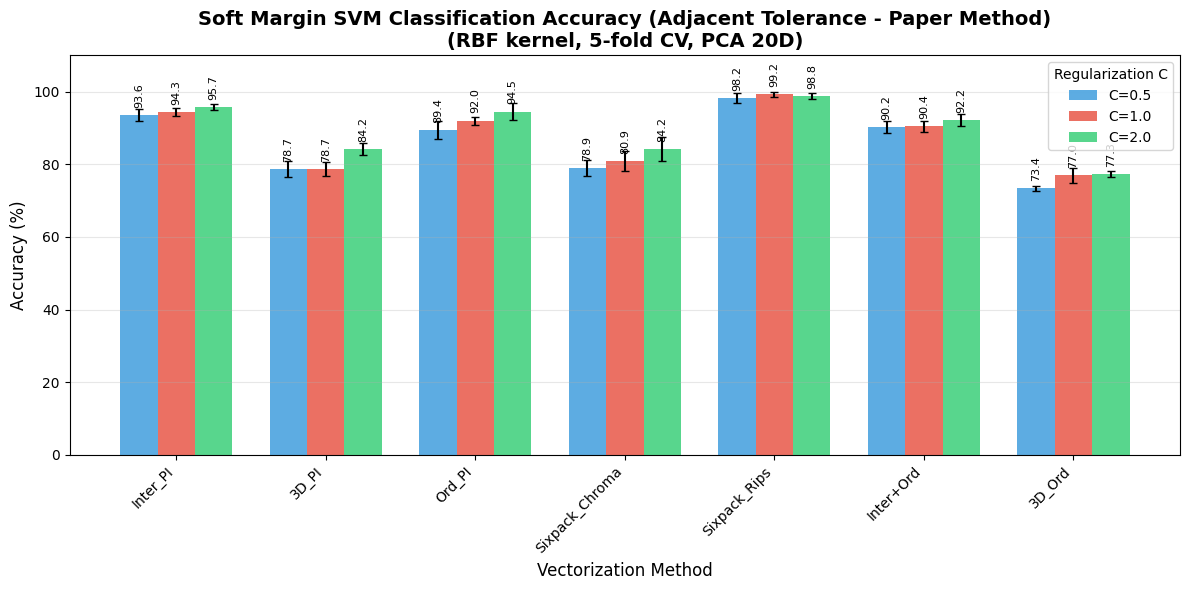


[Plotting results without tolerance (strict)...]

[Saved] soft_svm_results_strict.png


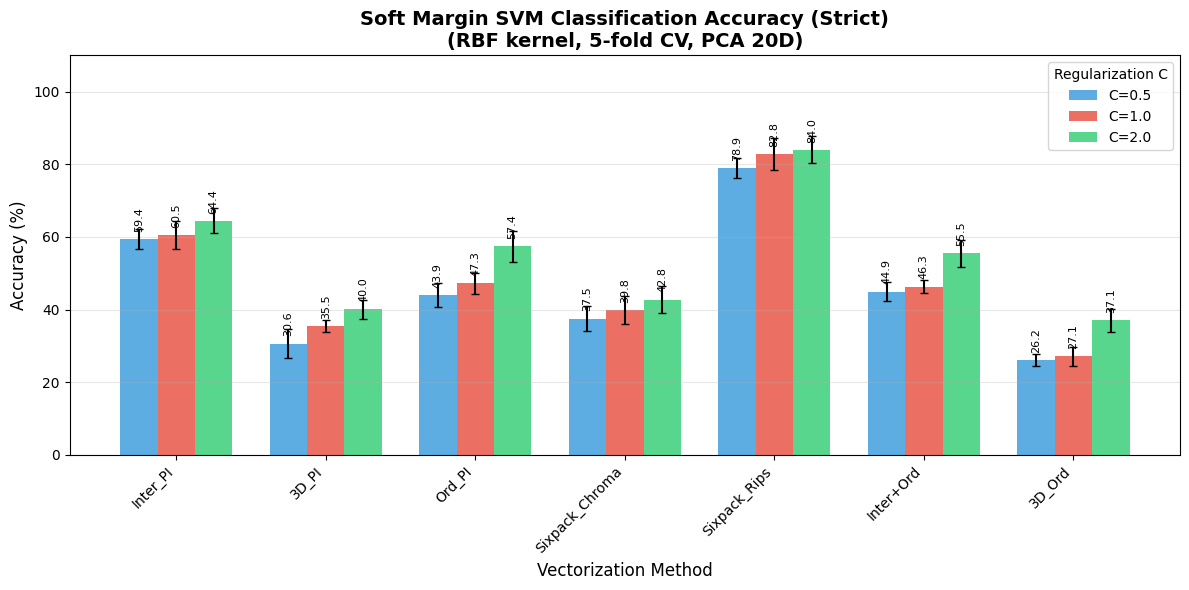


[Saved] soft_svm_results.csv

Results DataFrame:
           Method  Original_Dim  Reduced_Dim  Samples  Acc_C0.5_soft  Std_C0.5_soft  Acc_C0.5_strict  Std_C0.5_strict  Acc_C1.0_soft  Std_C1.0_soft  Acc_C1.0_strict  Std_C1.0_strict  Acc_C2.0_soft  Std_C2.0_soft  Acc_C2.0_strict  Std_C2.0_strict  Acc_KNN_k3_soft  Acc_KNN_k3_strict  Acc_KNN_k12_soft  Acc_KNN_k12_strict  Acc_SVM_RBF_soft  Acc_SVM_RBF_strict  Acc_SVM_Linear_soft  Acc_SVM_Linear_strict  Acc_Random_Forest_soft  Acc_Random_Forest_strict  Acc_Soft-SVM_C0.5_soft  Acc_Soft-SVM_C0.5_strict  Acc_Soft-SVM_C1.0_soft  Acc_Soft-SVM_C1.0_strict  Acc_Soft-SVM_C2.0_soft  Acc_Soft-SVM_C2.0_strict
0        Inter_PI         10200           20      512      93.550352       1.602059        59.364173         2.748944      94.330859       1.161656        60.538740         3.827268      95.701504       0.787408        64.445079         3.446558        95.893775          67.955454         96.870360           69.135732         93.350466           

In [ ]:
# ============================================
# Soft Margin SVM - Final Execution Code v2
# ============================================
#
# [IMPORTANT] Adjacent phase misclassification is IGNORED
# as per Supplementary Note 1:
# "we modified the scoring function to ignore
#  misclassification between adjacent phases"
#
# ADJACENT_PHASES extracted from actual phase diagram (GROUND_TRUTH_M)
# ============================================

import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================
# CONFIGURATION
# ============================================

C_VALUES = [0.5, 1.0, 2.0]      # Soft margin C parameters
REDUCTION_DIM = 20              # PCA target dimension
N_SPLITS = 5                    # Cross-validation folds
RANDOM_STATE = 42
IGNORE_ADJACENT = True          # <<< KEY SETTING: Ignore adjacent phase errors

# ============================================
# Adjacent Phases Definition (EXTRACTED FROM PHASE DIAGRAM)
# ============================================
# Extracted from GROUND_TRUTH_M matrices (M1-M8)
# Using spatial adjacency in the phase diagram
# Note: Classes 5, 8 do not exist in the phase diagram

ADJACENT_PHASES = {
    0: [1, 2],
    1: [0, 3],
    2: [0, 3],
    3: [1, 2, 4, 6, 7, 10, 11],
    4: [3, 7, 10, 11, 12, 13],
    6: [3, 7, 9, 10, 11, 12, 13],
    7: [3, 4, 6, 11, 12],
    9: [6, 10, 13],
    10: [3, 4, 6, 9, 13],
    11: [3, 4, 6, 7, 12, 13],
    12: [4, 6, 7, 11],
    13: [4, 6, 9, 10, 11],
}

# Total 27 adjacent pairs extracted from phase diagram

def are_adjacent_phases(label1, label2):
    """Check if two labels are adjacent phases"""
    label1, label2 = int(label1), int(label2)
    if label1 == label2:
        return True
    if label1 in ADJACENT_PHASES and label2 in ADJACENT_PHASES[label1]:
        return True
    if label2 in ADJACENT_PHASES and label1 in ADJACENT_PHASES[label2]:
        return True
    return False

def soft_accuracy_score(y_true, y_pred):
    """
    Modified accuracy: adjacent phase misclassifications are counted as CORRECT

    From paper: "we modified the scoring function to ignore
    misclassification between adjacent phases in the accuracy computation"
    """
    n_correct = 0
    for true_label, pred_label in zip(y_true, y_pred):
        if true_label == pred_label:
            n_correct += 1
        elif are_adjacent_phases(int(true_label), int(pred_label)):
            n_correct += 1  # Adjacent misclassification -> counted as correct

    return n_correct / len(y_true) if len(y_true) > 0 else 0.0

def strict_accuracy_score(y_true, y_pred):
    """Standard accuracy (no tolerance for adjacent phases)"""
    return accuracy_score(y_true, y_pred)

# ============================================
# Data Preprocessing (Sixpack dict support)
# ============================================

def flatten_dict_cell(cell):
    if isinstance(cell, dict):
        flat = []
        for key in sorted(cell.keys()):
            val = cell[key]
            if isinstance(val, np.ndarray):
                flat.extend(val.flatten().tolist())
            elif isinstance(val, (list, tuple)):
                flat.extend(list(val))
            else:
                flat.append(float(val))
        return flat
    elif isinstance(cell, np.ndarray):
        return cell.flatten().tolist()
    elif isinstance(cell, (list, tuple)):
        return list(cell)
    else:
        return [float(cell)]

def preprocess_X(X):
    if hasattr(X, 'numpy'):
        X = X.numpy()
    if hasattr(X, 'values'):
        X = X.values
    if not isinstance(X, np.ndarray):
        X = np.array(X)

    if X.dtype == object:
        print("      -> Flattening object dtype...")
        processed_rows = []
        for row in X:
            flat_row = []
            if hasattr(row, '__iter__') and not isinstance(row, (str, dict)):
                for cell in row:
                    flat_row.extend(flatten_dict_cell(cell))
            else:
                flat_row.extend(flatten_dict_cell(row))
            processed_rows.append(flat_row)

        lengths = [len(r) for r in processed_rows]
        if len(set(lengths)) > 1:
            max_len = max(lengths)
            processed_rows = [r + [0.0] * (max_len - len(r)) for r in processed_rows]

        X = np.array(processed_rows, dtype=np.float64)
        print("      -> Shape: {}".format(X.shape))

    X = X.astype(np.float64)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

def preprocess_y(y):
    if hasattr(y, 'numpy'):
        y = y.numpy()
    if hasattr(y, 'values'):
        y = y.values
    return np.array(y).flatten().astype(int)

# ============================================
# Evaluation Functions
# ============================================

def evaluate_soft_margin_svm(X, y, C_values, n_splits, ignore_adjacent=True, verbose=True):
    """
    Evaluate Soft Margin SVM with optional adjacent phase tolerance
    """
    results = {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for C in C_values:
        accuracies_soft = []
        accuracies_strict = []

        for train_idx, test_idx in skf.split(X_scaled, y):
            clf = SVC(kernel='rbf', C=C, gamma='scale', random_state=RANDOM_STATE)
            clf.fit(X_scaled[train_idx], y[train_idx])
            y_pred = clf.predict(X_scaled[test_idx])

            accuracies_soft.append(soft_accuracy_score(y[test_idx], y_pred))
            accuracies_strict.append(strict_accuracy_score(y[test_idx], y_pred))

        mean_soft = np.mean(accuracies_soft) * 100
        std_soft = np.std(accuracies_soft) * 100
        mean_strict = np.mean(accuracies_strict) * 100
        std_strict = np.std(accuracies_strict) * 100

        results['C={}'.format(C)] = {
            'mean_soft': mean_soft,
            'std_soft': std_soft,
            'mean_strict': mean_strict,
            'std_strict': std_strict
        }

        if verbose:
            print("    Soft-SVM (C={}): {:.2f}% +/- {:.2f}% [adj-tol] | {:.2f}% [strict]".format(
                C, mean_soft, std_soft, mean_strict))

    return results

def clone_clf(clf):
    if isinstance(clf, KNeighborsClassifier):
        return KNeighborsClassifier(n_neighbors=clf.n_neighbors)
    elif isinstance(clf, SVC):
        return SVC(kernel=clf.kernel, C=clf.C, gamma='scale', random_state=RANDOM_STATE)
    elif isinstance(clf, RandomForestClassifier):
        return RandomForestClassifier(n_estimators=clf.n_estimators, random_state=RANDOM_STATE)
    return clf

def evaluate_all_classifiers(X, y, C_values, n_splits):
    """Evaluate all classifiers with both soft and strict accuracy"""
    classifiers = {
        'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
        'KNN (k=12)': KNeighborsClassifier(n_neighbors=12),
        'SVM (RBF)': SVC(kernel='rbf', C=1.0),
        'SVM (Linear)': SVC(kernel='linear', C=1.0),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    }
    for C in C_values:
        classifiers['Soft-SVM (C={})'.format(C)] = SVC(kernel='rbf', C=C, gamma='scale')

    results = {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    for name, clf in classifiers.items():
        accuracies_soft = []
        accuracies_strict = []

        for train_idx, test_idx in skf.split(X, y):
            clf_copy = clone_clf(clf)
            clf_copy.fit(X[train_idx], y[train_idx])
            y_pred = clf_copy.predict(X[test_idx])

            accuracies_soft.append(soft_accuracy_score(y[test_idx], y_pred))
            accuracies_strict.append(strict_accuracy_score(y[test_idx], y_pred))

        results[name] = {
            'mean_soft': np.mean(accuracies_soft) * 100,
            'std_soft': np.std(accuracies_soft) * 100,
            'mean_strict': np.mean(accuracies_strict) * 100,
            'std_strict': np.std(accuracies_strict) * 100
        }

    return results

# ============================================
# Output Functions
# ============================================

def print_soft_svm_table(all_results, C_values, use_soft=True):
    metric = 'soft' if use_soft else 'strict'
    title = "WITH Adjacent Phase Tolerance (Paper Method)" if use_soft else "WITHOUT Tolerance (Strict)"

    print("\n" + "="*115)
    print("Soft Margin SVM Classification Accuracy - {}".format(title))
    print("(RBF kernel, {}-fold CV, PCA {}D)".format(N_SPLITS, REDUCTION_DIM))
    print("="*115)

    header = "{:<25} {:>12} {:>10}".format('Method', 'Dimension', 'Samples')
    for C in C_values:
        header += " {:>22}".format('C=' + str(C))
    print(header)
    print("-"*115)

    for method_name, result in all_results.items():
        row = "{:<25} {:>12} {:>10}".format(
            method_name,
            result.get('original_dim', 'N/A'),
            result.get('samples', 'N/A')
        )
        soft_results = result.get('soft_svm', {})
        for C in C_values:
            key = 'C={}'.format(C)
            if key in soft_results:
                mean = soft_results[key]['mean_{}'.format(metric)]
                std = soft_results[key]['std_{}'.format(metric)]
                row += " {:>10.2f}% +/- {:>5.2f}%".format(mean, std)
            else:
                row += " {:>22}".format('N/A')
        print(row)

    print("="*115)

def print_comparison_table(all_results, use_soft=True):
    metric = 'soft' if use_soft else 'strict'
    title = "Adjacent Tolerance" if use_soft else "Strict"

    print("\n" + "="*170)
    print("Full Classifier Comparison ({})".format(title))
    print("="*170)

    clf_names = ['KNN (k=3)', 'KNN (k=12)', 'SVM (RBF)', 'SVM (Linear)',
                 'Random Forest', 'Soft-SVM (C=0.5)', 'Soft-SVM (C=1.0)', 'Soft-SVM (C=2.0)']

    header = "{:<20} {:>8}".format('Method', 'Dim')
    for clf in clf_names:
        short = clf.replace('Soft-SVM', 'S-SVM')[:14]
        header += " {:>16}".format(short)
    print(header)
    print("-"*170)

    for method_name, result in all_results.items():
        row = "{:<20} {:>8}".format(method_name[:20], result.get('original_dim', 'N/A'))
        clf_results = result.get('classifiers', {})
        for clf in clf_names:
            if clf in clf_results:
                mean = clf_results[clf]['mean_{}'.format(metric)]
                std = clf_results[clf]['std_{}'.format(metric)]
                row += " {:>7.1f}+/-{:<5.1f}%".format(mean, std)
            else:
                row += " {:>16}".format('N/A')
        print(row)

    print("="*170)

def plot_results(all_results, C_values, use_soft=True, save_path=None):
    metric = 'soft' if use_soft else 'strict'
    title_suffix = "(Adjacent Tolerance - Paper Method)" if use_soft else "(Strict)"

    methods = list(all_results.keys())
    x = np.arange(len(methods))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(12, len(methods)*1.5), 6))
    colors = ['#3498db', '#e74c3c', '#2ecc71']

    for i, C in enumerate(C_values):
        means = []
        stds = []
        for m in methods:
            soft_results = all_results[m].get('soft_svm', {})
            key = 'C={}'.format(C)
            if key in soft_results:
                means.append(soft_results[key]['mean_{}'.format(metric)])
                stds.append(soft_results[key]['std_{}'.format(metric)])
            else:
                means.append(0)
                stds.append(0)

        bars = ax.bar(x + i*width, means, width, yerr=stds, label='C={}'.format(C),
                      color=colors[i], capsize=3, alpha=0.8)

        for bar, mean in zip(bars, means):
            if mean > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                       '{:.1f}'.format(mean), ha='center', va='bottom', fontsize=8, rotation=90)

    ax.set_xlabel('Vectorization Method', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Soft Margin SVM Classification Accuracy {}\n(RBF kernel, {}-fold CV, PCA {}D)'.format(
        title_suffix, N_SPLITS, REDUCTION_DIM), fontsize=14, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=10)
    ax.legend(title='Regularization C', fontsize=10)
    ax.set_ylim([0, 110])
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print("\n[Saved] {}".format(save_path))

    plt.show()

def results_to_dataframe(all_results, C_values):
    rows = []
    for method_name, result in all_results.items():
        row = {
            'Method': method_name,
            'Original_Dim': result.get('original_dim'),
            'Reduced_Dim': result.get('reduced_dim'),
            'Samples': result.get('samples'),
        }
        soft_results = result.get('soft_svm', {})
        for C in C_values:
            key = 'C={}'.format(C)
            if key in soft_results:
                row['Acc_C{}_soft'.format(C)] = soft_results[key]['mean_soft']
                row['Std_C{}_soft'.format(C)] = soft_results[key]['std_soft']
                row['Acc_C{}_strict'.format(C)] = soft_results[key]['mean_strict']
                row['Std_C{}_strict'.format(C)] = soft_results[key]['std_strict']

        clf_results = result.get('classifiers', {})
        for clf_name, clf_result in clf_results.items():
            clean_name = clf_name.replace(' ', '_').replace('(', '').replace(')', '').replace('=', '')
            row['Acc_{}_soft'.format(clean_name)] = clf_result['mean_soft']
            row['Acc_{}_strict'.format(clean_name)] = clf_result['mean_strict']

        rows.append(row)

    return pd.DataFrame(rows)

# ============================================
# MAIN EXECUTION
# ============================================

print("="*80)
print("SOFT MARGIN SVM EVALUATION (v2 - Corrected Adjacent Phases)")
print("="*80)
print("Configuration:")
print("  - C values: {}".format(C_VALUES))
print("  - PCA dimension: {}".format(REDUCTION_DIM))
print("  - CV folds: {}".format(N_SPLITS))
print("  - Adjacent phase tolerance: ENABLED")
print("")
print("ADJACENT_PHASES (extracted from phase diagram):")
for phase in sorted(ADJACENT_PHASES.keys()):
    print("  Phase {:2d} <-> {}".format(phase, ADJACENT_PHASES[phase]))
print("")
print("NOTE: Paper method ignores misclassifications between adjacent phases")
print("="*80)

# Check datasets
if 'datasets' not in dir():
    print("\n[ERROR] 'datasets' variable not found!")
    print("Please load your datasets first.")
else:
    print("\nFound {} datasets: {}".format(len(datasets), list(datasets.keys())))

    # Run evaluation
    all_results = {}

    for method_name, data in datasets.items():
        print("\n" + "-"*60)
        print("[{}]".format(method_name))

        try:
            # Get data
            X = data.get('X', data.get('x', None))
            y = data.get('y', data.get('Y', data.get('labels', None)))

            if X is None or y is None:
                print("  [SKIP] Data not found. Keys: {}".format(list(data.keys())))
                continue

            # Preprocess
            X = preprocess_X(X)
            y = preprocess_y(y)

            original_dim = X.shape[1]
            n_samples = X.shape[0]
            n_classes = len(np.unique(y))

            print("  Shape: {} samples x {} features, {} classes".format(n_samples, original_dim, n_classes))

            # Scaling + PCA
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            if original_dim > REDUCTION_DIM:
                pca = PCA(n_components=REDUCTION_DIM, random_state=RANDOM_STATE)
                X_reduced = pca.fit_transform(X_scaled)
                print("  PCA: {}D -> {}D".format(original_dim, REDUCTION_DIM))
            else:
                X_reduced = X_scaled
                print("  No PCA needed (dim={})".format(original_dim))

            # Soft Margin SVM
            print("  Soft Margin SVM Results:")
            soft_results = evaluate_soft_margin_svm(
                X_reduced, y, C_VALUES, N_SPLITS,
                ignore_adjacent=IGNORE_ADJACENT, verbose=True
            )

            # All classifiers
            clf_results = evaluate_all_classifiers(
                X_reduced, y, C_VALUES, N_SPLITS
            )

            all_results[method_name] = {
                'original_dim': original_dim,
                'reduced_dim': X_reduced.shape[1],
                'samples': n_samples,
                'classes': n_classes,
                'soft_svm': soft_results,
                'classifiers': clf_results
            }

        except Exception as e:
            print("  [ERROR] {}".format(str(e)))
            import traceback
            traceback.print_exc()

    # ============================================
    # OUTPUT RESULTS
    # ============================================

    if len(all_results) > 0:
        # 1. Soft SVM Table - WITH adjacent tolerance (Paper method)
        print_soft_svm_table(all_results, C_VALUES, use_soft=True)

        # 2. Soft SVM Table - WITHOUT tolerance (for comparison)
        print_soft_svm_table(all_results, C_VALUES, use_soft=False)

        # 3. Full Comparison (with tolerance)
        print_comparison_table(all_results, use_soft=True)

        # 4. Visualization (with tolerance - paper method)
        print("\n[Plotting results with adjacent tolerance (paper method)...]")
        plot_results(all_results, C_VALUES, use_soft=True, save_path='soft_svm_results_adjacent_tol.png')

        # 5. Visualization (strict - for comparison)
        print("\n[Plotting results without tolerance (strict)...]")
        plot_results(all_results, C_VALUES, use_soft=False, save_path='soft_svm_results_strict.png')

        # 6. Save to DataFrame
        df_results = results_to_dataframe(all_results, C_VALUES)
        df_results.to_csv('soft_svm_results.csv', index=False)
        print("\n[Saved] soft_svm_results.csv")

        # 7. Display DataFrame
        print("\n" + "="*80)
        print("Results DataFrame:")
        print("="*80)
        display(df_results) if 'display' in dir() else print(df_results.to_string())

        # Store in global variable
        soft_svm_results = all_results
        print("\n[Done] Results stored in 'soft_svm_results' variable")
    else:
        print("\n[WARNING] No valid results generated.")

print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)


[Visualizing] Inter_PI using UMAP...
  -> Saved visualization to phase_viz_UMAP_Inter_PI.png


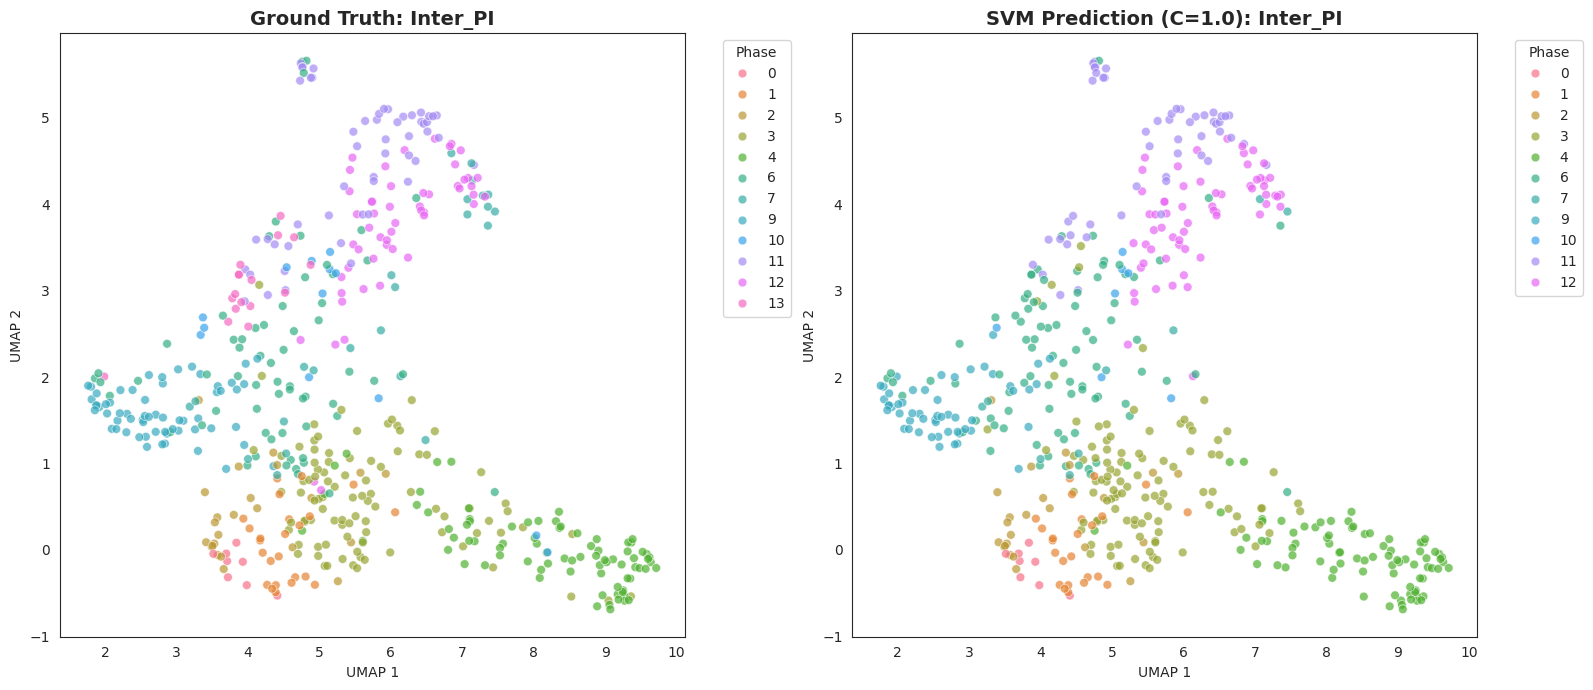


[Visualizing] 3D_PI using UMAP...
  -> Saved visualization to phase_viz_UMAP_3D_PI.png


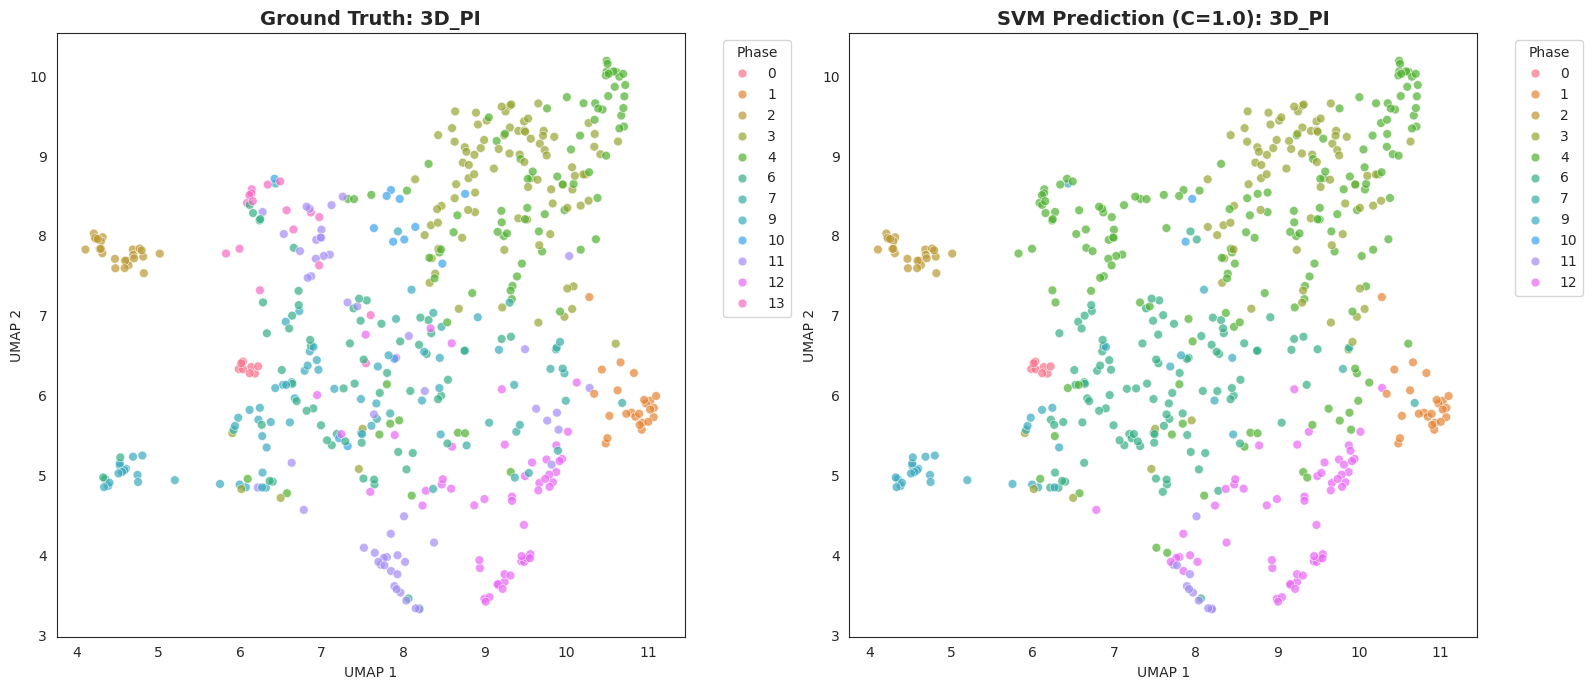


[Visualizing] Ord_PI using UMAP...
  -> Saved visualization to phase_viz_UMAP_Ord_PI.png


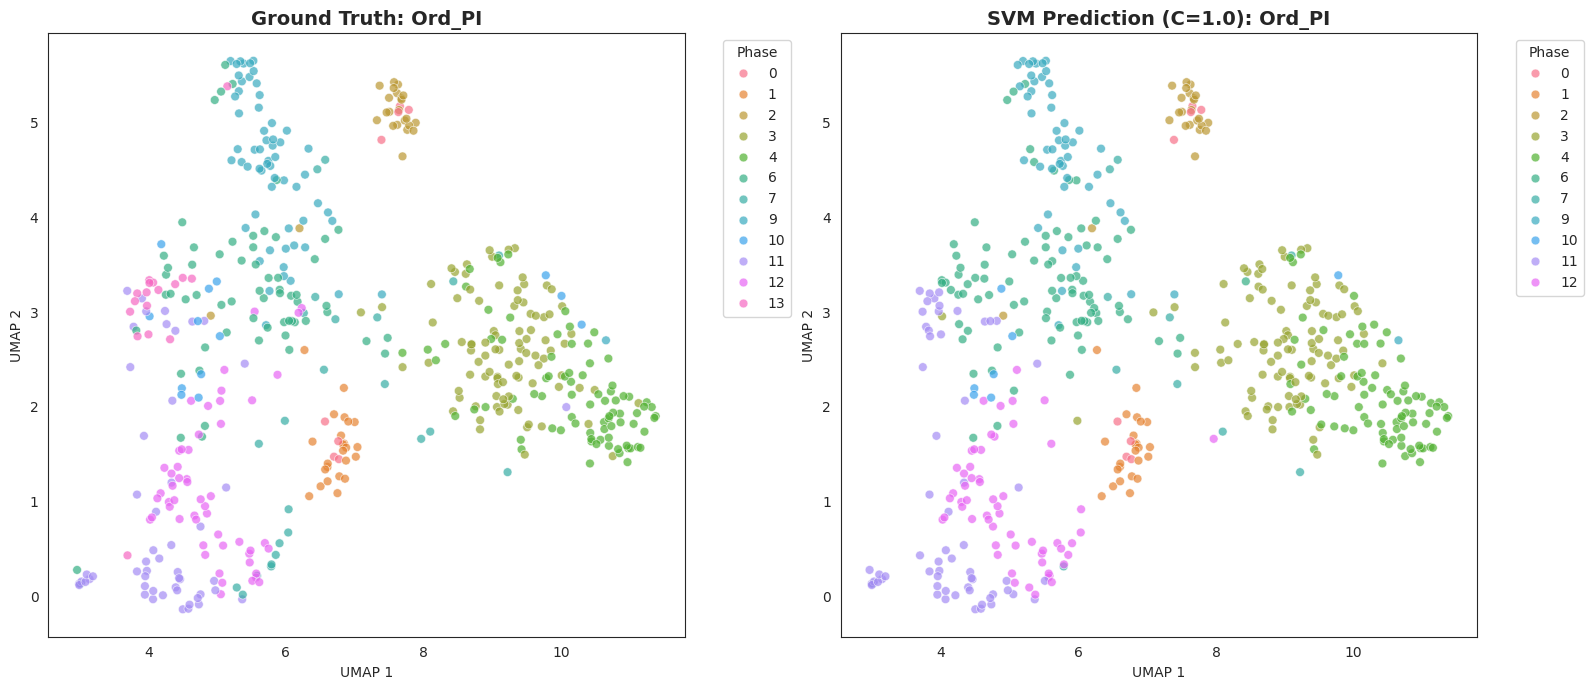


[Visualizing] Sixpack_Chroma using UMAP...
      -> Flattening object dtype...
      -> Shape: (512, 61200)
  -> Saved visualization to phase_viz_UMAP_Sixpack_Chroma.png


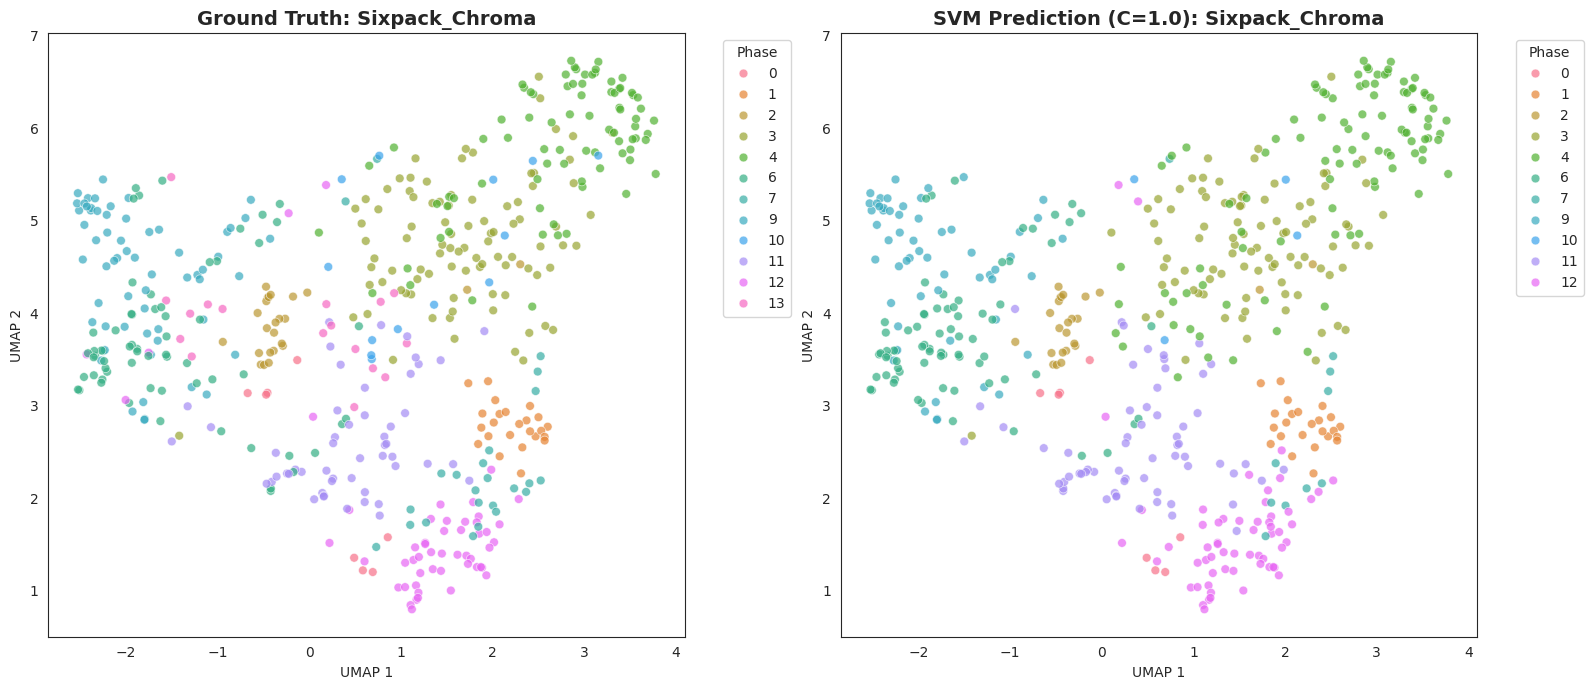


[Visualizing] Sixpack_Rips using UMAP...
  -> Saved visualization to phase_viz_UMAP_Sixpack_Rips.png


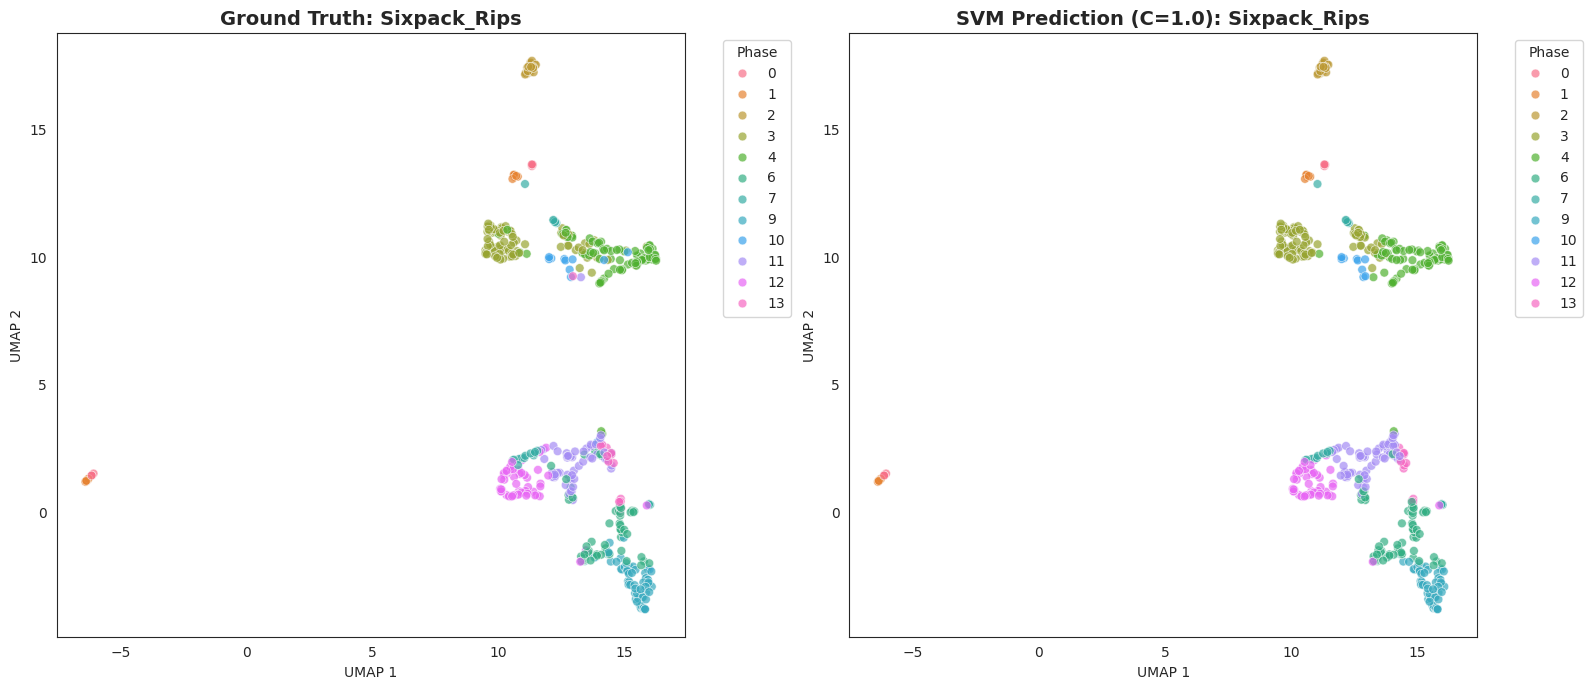


[Visualizing] Inter+Ord using UMAP...
  -> Saved visualization to phase_viz_UMAP_Inter+Ord.png


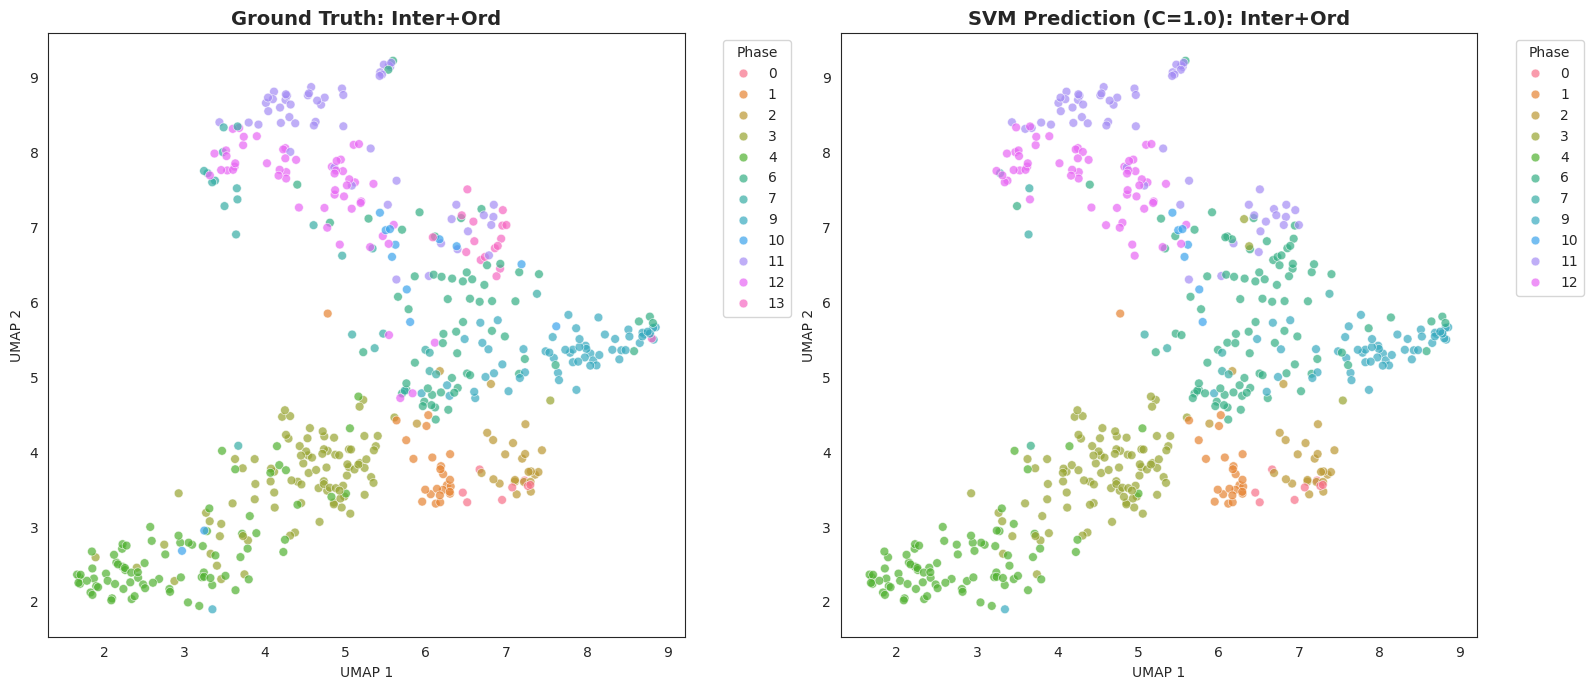


[Visualizing] 3D_Ord using UMAP...
  -> Saved visualization to phase_viz_UMAP_3D_Ord.png


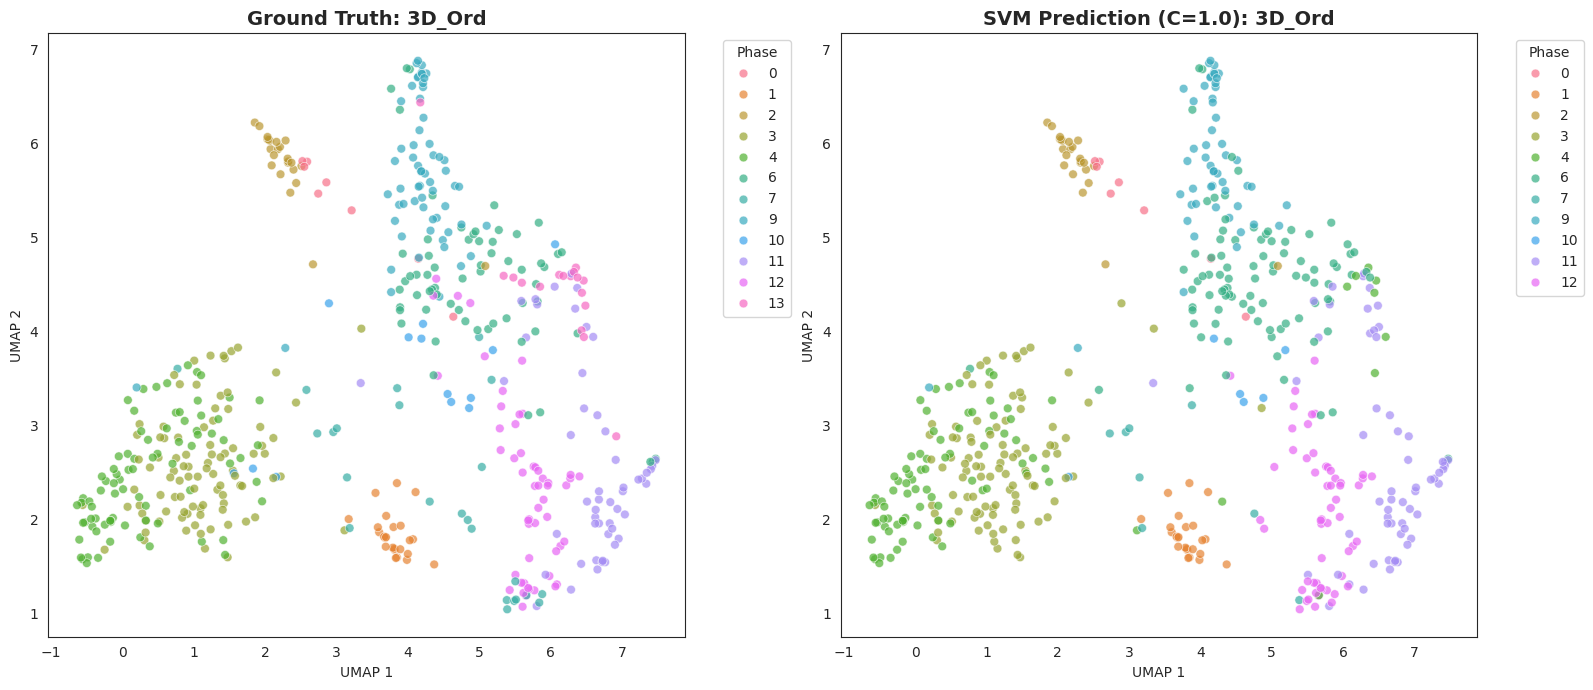

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from umap import UMAP # UMAP이 설치되어 있지 않다면 pip install umap-learn

def plot_2d_clusters(datasets, all_results, method='UMAP', save_prefix='viz'):
    """
    각 데이터셋에 대해 Ground Truth와 SVM 예측 결과를 2D로 시각화합니다.
    method: 'UMAP' 또는 'PCA' 선택 가능
    """
    n_datasets = len(all_results)
    if n_datasets == 0:
        print("시각화할 결과가 없습니다.")
        return

    # 스타일 설정
    sns.set_style("white")

    for method_name, result in all_results.items():
        print(f"\n[Visualizing] {method_name} using {method}...")

        # 1. 데이터 준비
        data = datasets[method_name]
        X = preprocess_X(data.get('X', data.get('x')))
        y_true = preprocess_y(data.get('y', data.get('Y')))

        # 스케일링
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # 2. 2차원 차원 축소
        if method == 'UMAP':
            reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
        else: # PCA
            reducer = PCA(n_components=2, random_state=RANDOM_STATE)

        X_2d = reducer.fit_transform(X_scaled)

        # 3. SVM 예측값 생성 (최적화된 C=1.0 기준으로 예시)
        best_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)
        best_clf.fit(X_scaled, y_true) # 실제로는 CV 내에서 그려야 하지만 시각화용으로 전체 학습
        y_pred = best_clf.predict(X_scaled)

        # 4. 시각화 (Ground Truth vs Prediction)
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))

        # 컬러맵 설정 (페이즈 개수에 맞춤)
        unique_labels = np.unique(y_true)
        palette = sns.color_palette("husl", len(unique_labels))

        # 좌측: Ground Truth
        sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y_true, ax=axes[0],
                        palette=palette, legend='full', s=40, alpha=0.7)
        axes[0].set_title(f"Ground Truth: {method_name}", fontsize=14, fontweight='bold')

        # 우측: SVM Prediction
        sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y_pred, ax=axes[1],
                        palette=palette, legend='full', s=40, alpha=0.7)
        axes[1].set_title(f"SVM Prediction (C=1.0): {method_name}", fontsize=14, fontweight='bold')

        for ax in axes:
            ax.set_xlabel(f"{method} 1")
            ax.set_ylabel(f"{method} 2")
            ax.legend(title="Phase", bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()

        # 파일 저장
        save_path = f"{save_prefix}_{method}_{method_name.replace(' ', '_')}.png"
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"  -> Saved visualization to {save_path}")
        plt.show()

# ============================================
# 실행 코드
# ============================================
# 위에서 정의한 all_results가 존재할 때 실행 가능합니다.
if 'all_results' in locals() and len(all_results) > 0:
    # UMAP 기반 시각화 실행
    plot_2d_clusters(datasets, all_results, method='UMAP', save_prefix='phase_viz')


[Confusion Matrix] Inter_PI (C=1.0) 시각화 중...


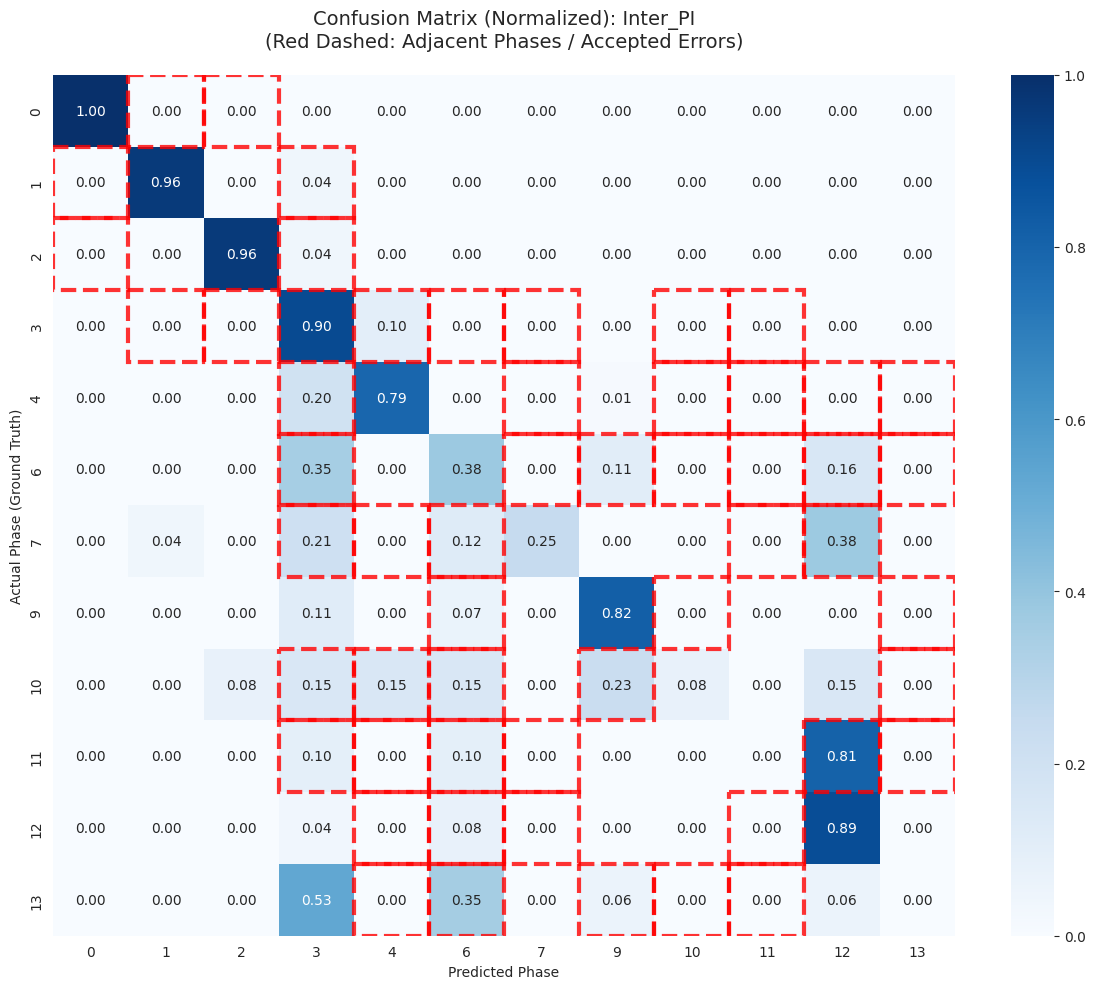


[Confusion Matrix] 3D_PI (C=1.0) 시각화 중...


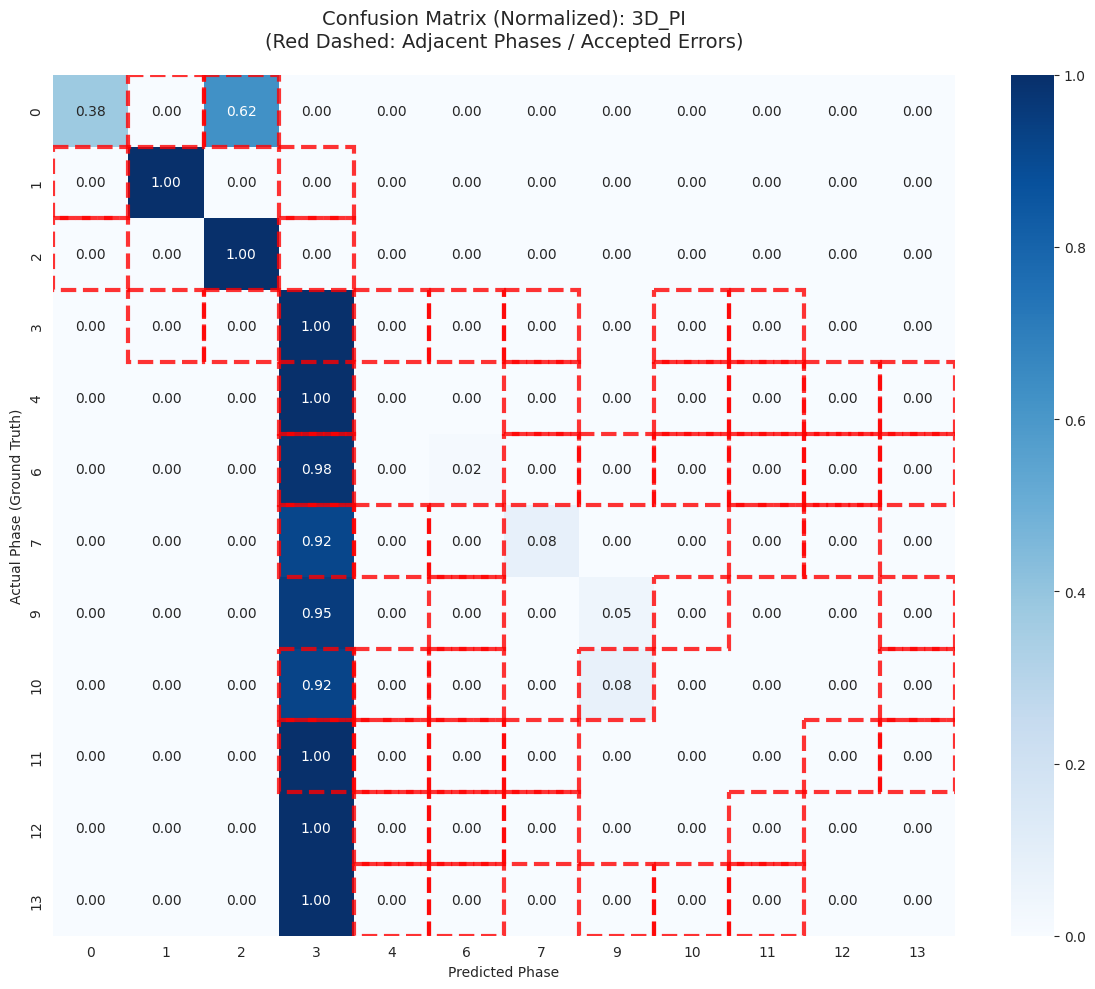


[Confusion Matrix] Ord_PI (C=1.0) 시각화 중...


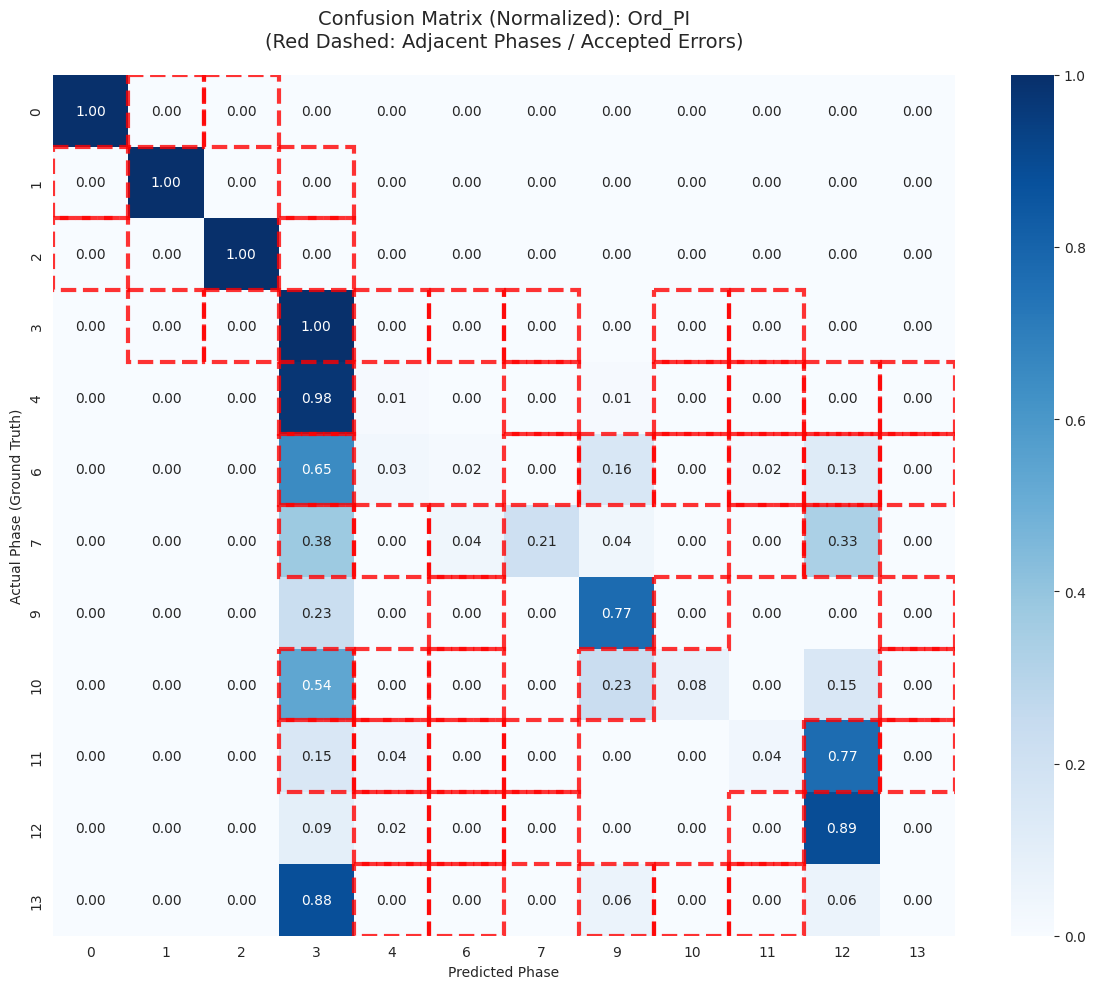


[Confusion Matrix] Sixpack_Chroma (C=1.0) 시각화 중...
      -> Flattening object dtype...
      -> Shape: (512, 61200)


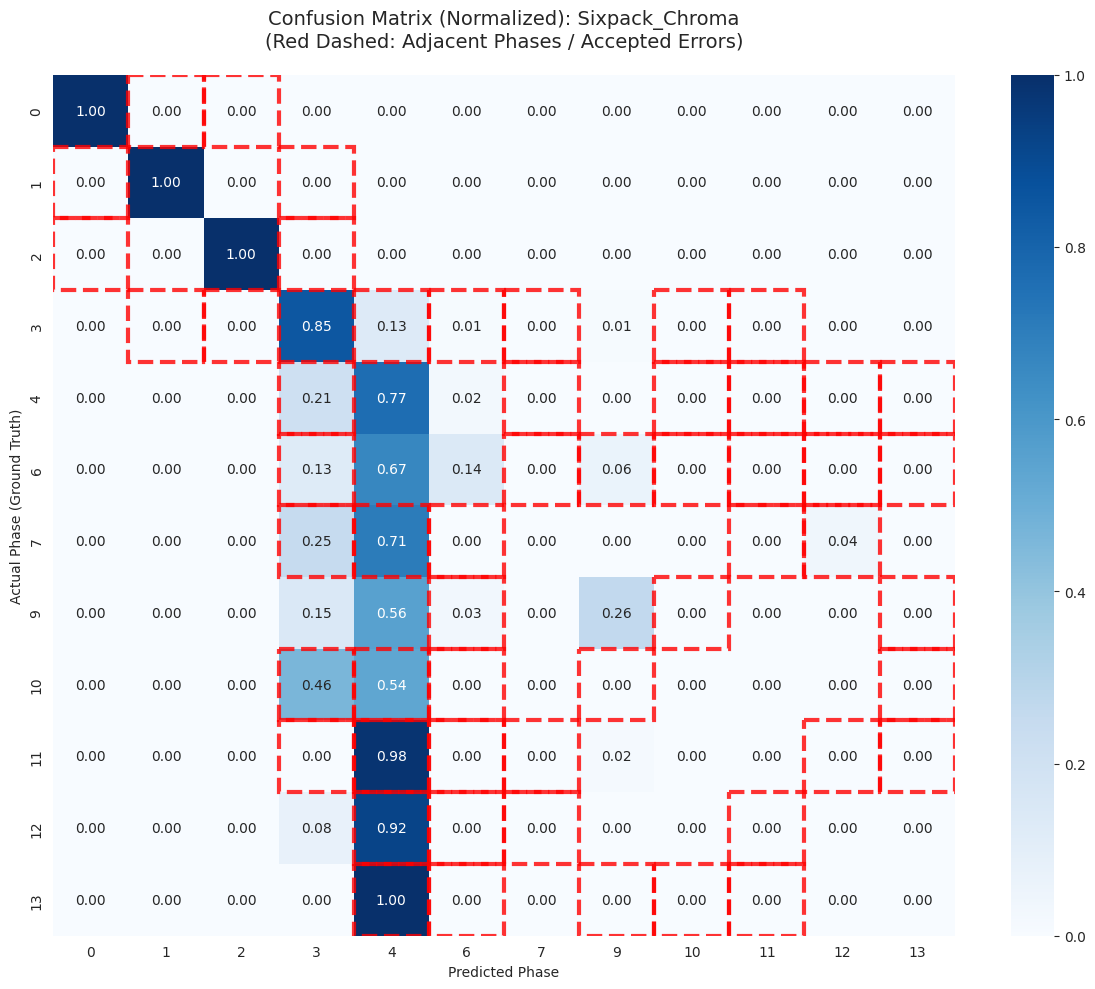


[Confusion Matrix] Sixpack_Rips (C=1.0) 시각화 중...


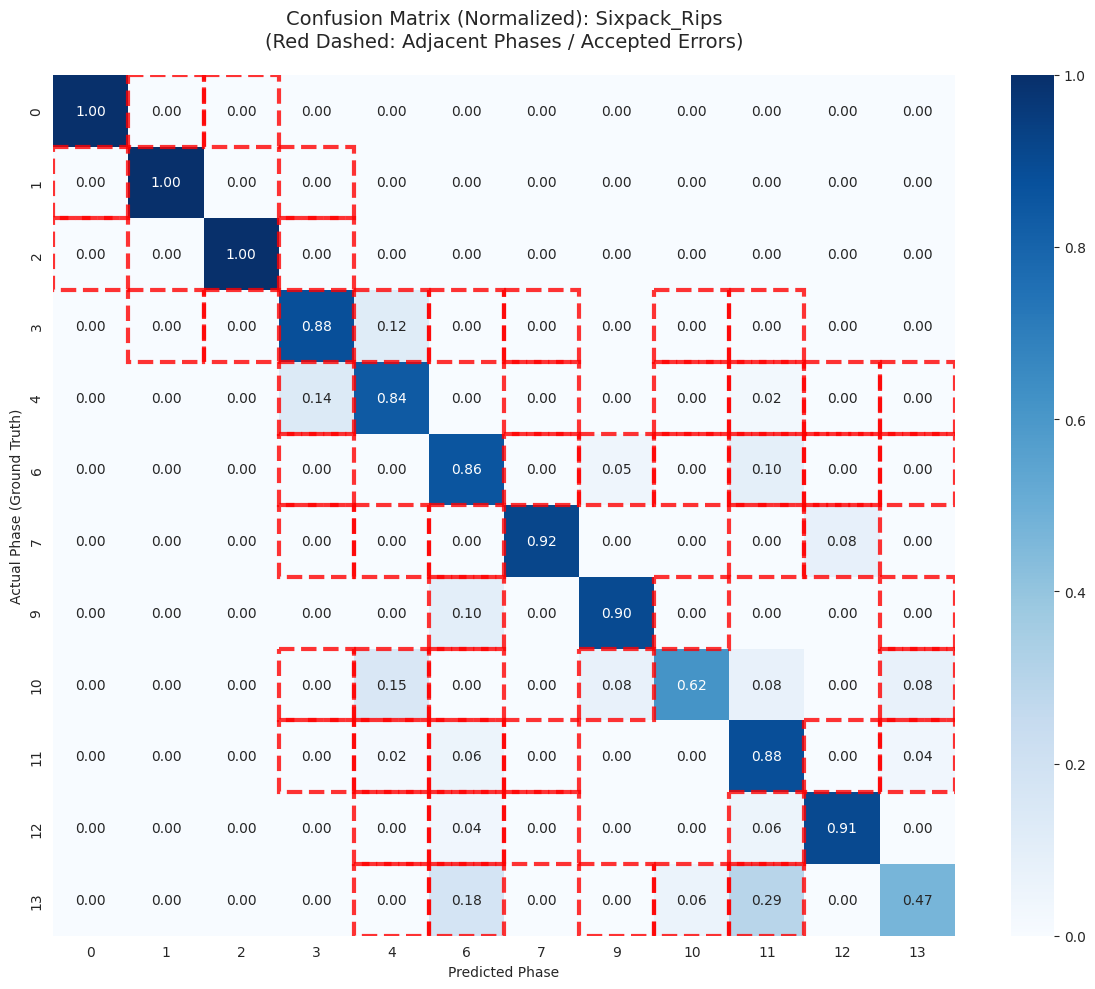


[Confusion Matrix] Inter+Ord (C=1.0) 시각화 중...


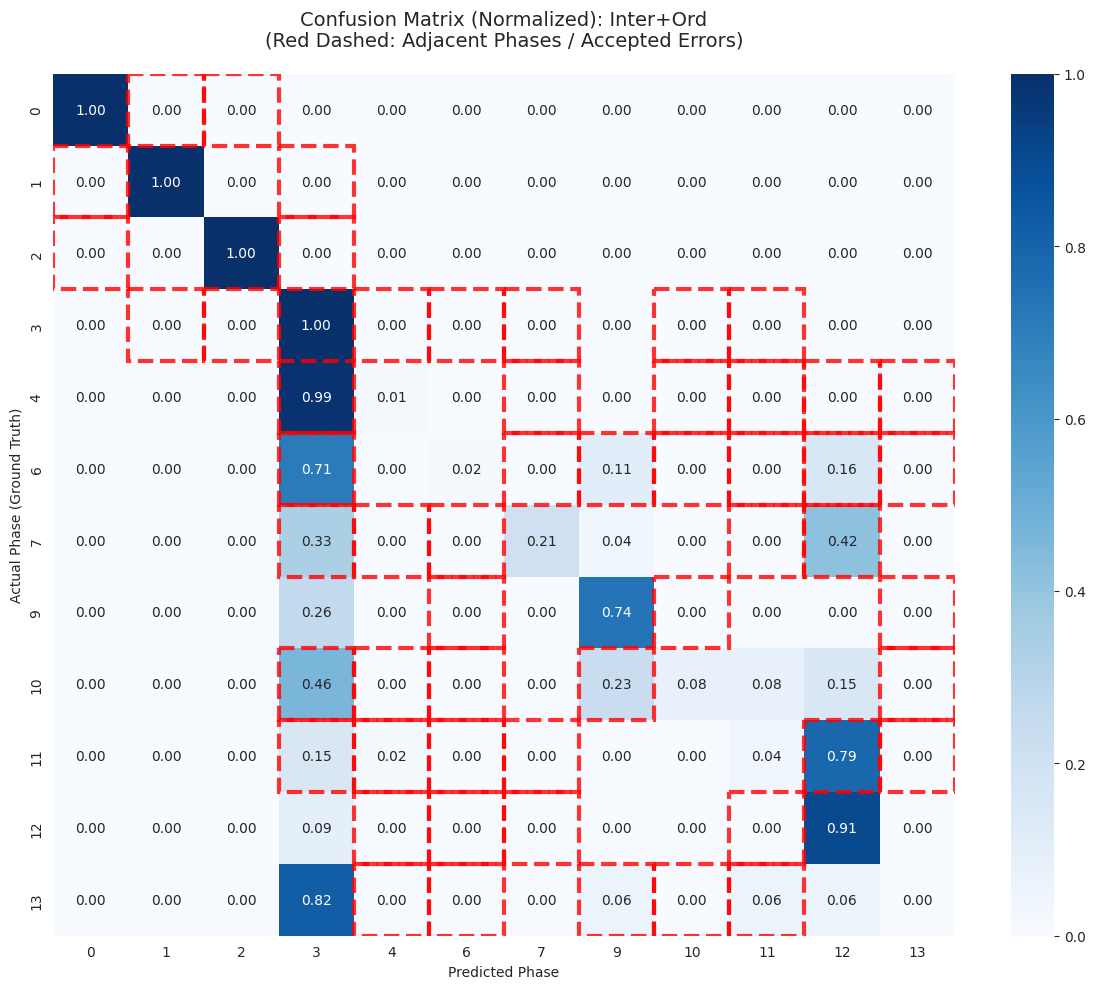


[Confusion Matrix] 3D_Ord (C=1.0) 시각화 중...


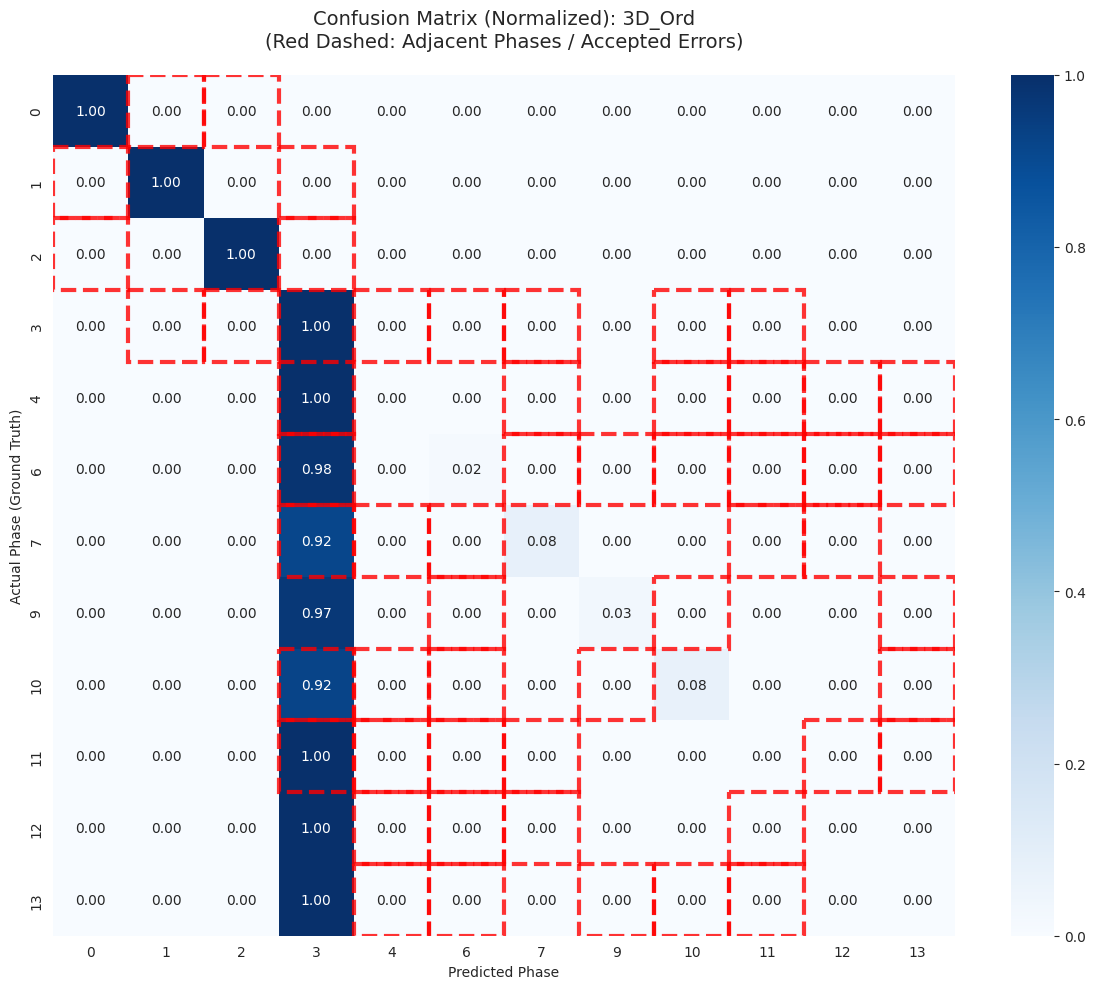

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.patches as patches

def plot_confusion_matrices(datasets, all_results, C_selected=1.0, normalize=True):
    """
    개선된 Confusion Matrix 시각화 함수
    normalize=True일 경우 비율(%)로 표시하여 데이터 불균형 영향을 배제합니다.
    """
    for method_name, result in all_results.items():
        try:
            print(f"\n[Confusion Matrix] {method_name} (C={C_selected}) 시각화 중...")

            # 1. 데이터 준비
            data = datasets[method_name]
            X = preprocess_X(data.get('X', data.get('x')))
            y_true = preprocess_y(data.get('y', data.get('Y')))

            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            X_input = PCA(n_components=REDUCTION_DIM, random_state=RANDOM_STATE).fit_transform(X_scaled) if X.shape[1] > REDUCTION_DIM else X_scaled

            clf = SVC(kernel='rbf', C=C_selected, gamma='scale', random_state=RANDOM_STATE)
            clf.fit(X_input, y_true)
            y_pred = clf.predict(X_input)

            # 2. Confusion Matrix 계산
            labels = sorted(np.unique(y_true))
            cm = confusion_matrix(y_true, y_pred, labels=labels)

            # 정규화 (행별 합계가 1이 되도록 설정)
            if normalize:
                cm_display = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
                fmt = '.2f'
            else:
                cm_display = cm
                fmt = 'd'

            # 3. 시각화
            plt.figure(figsize=(12, 10))
            ax = sns.heatmap(cm_display, annot=True, fmt=fmt, cmap='Blues',
                             xticklabels=labels, yticklabels=labels, cbar=True)

            # 4. Adjacent Phases(인접 위상) 오차 허용 구역 강조
            for i, label_i in enumerate(labels):
                for j, label_j in enumerate(labels):
                    if label_i != label_j and are_adjacent_phases(label_i, label_j):
                        # 실제 인접 위상 관계인 칸에 빨간색 테두리 표시
                        ax.add_patch(patches.Rectangle((j, i), 1, 1, fill=False,
                                                     edgecolor='red', lw=3, alpha=0.8, linestyle='--'))

            title_type = "Normalized" if normalize else "Count"
            plt.title(f"Confusion Matrix ({title_type}): {method_name}\n(Red Dashed: Adjacent Phases / Accepted Errors)", fontsize=14, pad=20)
            plt.ylabel('Actual Phase (Ground Truth)')
            plt.xlabel('Predicted Phase')

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"  [ERROR] {method_name} 시각화 실패: {e}")

# 실행부
if len(all_results) > 0:
    plot_confusion_matrices(datasets, all_results, C_selected=1.0, normalize=True)

In [ ]:
pip install Pillow

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import glob
from PIL import Image
import math
import os
import matplotlib.font_manager as fm

# ============================================
# 0. 한글 폰트 및 기본 설정
# ============================================
def set_korean_font():
    """OS에 따라 한글 폰트를 자동으로 설정합니다."""
    font_path = ''
    font_name = ''

    if os.name == 'nt':  # Windows
        font_path = 'C:/Windows/Fonts/malgun.ttf'
        if os.path.exists(font_path): font_name = 'Malgun Gothic'

    else:  # Mac/Linux (Colab 포함)
        # 나눔글꼴 확인 (Colab 등 리눅스)
        nanum_fonts = [f for f in fm.findSystemFonts() if 'Nanum' in f]
        if nanum_fonts:
            # NanumGothic 또는 NanumBarunGothic 우선 선택
            for font in nanum_fonts:
                if 'NanumGothic.ttf' in font or 'NanumBarunGothic.ttf' in font:
                    font_path = font
                    break
            if not font_path: font_path = nanum_fonts[0] # 없으면 아무거나

        # 맥용 애플고딕 확인
        elif os.path.exists('/System/Library/Fonts/Supplemental/AppleGothic.ttf'):
             font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'

    if font_path:
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc('font', family=font_name)
        plt.rc('axes', unicode_minus=False) # 마이너스 기호 깨짐 방지
        print(f"한글 폰트 설정 완료: {font_name} ({font_path})")
    else:
        print("[경고] 한글 폰트를 찾을 수 없습니다. 글씨가 깨질 수 있습니다.")
        print("Colab 사용자는 '!sudo apt-get install -y fonts-nanum' 실행 후 런타임을 재시작해주세요.")

# Pillow 이미지 최대 크기 제한 해제 (고해상도 병합 시 필요)
Image.MAX_IMAGE_PIXELS = None

# ============================================
# 1. 개별 Confusion Matrix 저장 함수 (수정본)
# ============================================
def save_individual_confusion_matrices(datasets, all_results, C_selected=1.0, normalize=True):
    """
    각 데이터셋의 Confusion Matrix를 시각화하고 고해상도 png 파일로 저장합니다.
    """
    generated_files = []
    set_korean_font() # 폰트 설정 적용

    for method_name, result in all_results.items():
        try:
            print(f"이미지 생성 중 (고해상도): {method_name}...")

            # 데이터 준비
            data = datasets[method_name]
            X = preprocess_X(data.get('X', data.get('x')))
            y_true = preprocess_y(data.get('y', data.get('Y')))

            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            # PCA 차원 축소
            if X.shape[1] > REDUCTION_DIM:
                pca = PCA(n_components=REDUCTION_DIM, random_state=RANDOM_STATE)
                X_input = pca.fit_transform(X_scaled)
            else:
                X_input = X_scaled

            # 모델 학습 및 예측
            clf = SVC(kernel='rbf', C=C_selected, gamma='scale', random_state=RANDOM_STATE)
            clf.fit(X_input, y_true)
            y_pred = clf.predict(X_input)

            # Confusion Matrix 계산
            labels = sorted(np.unique(y_true))
            cm = confusion_matrix(y_true, y_pred, labels=labels)

            if normalize:
                row_sums = cm.sum(axis=1)[:, np.newaxis]
                cm_display = np.divide(cm.astype('float'), row_sums, out=np.zeros_like(cm.astype('float')), where=row_sums!=0)
                fmt = '.2f'
                title_norm = "(정규화된 비율)"
            else:
                cm_display = cm
                fmt = 'd'
                title_norm = "(개수)"

            # 그래프 그리기 (해상도 높임)
            plt.figure(figsize=(10, 8))
            ax = sns.heatmap(cm_display, annot=True, fmt=fmt, cmap='Blues',
                             xticklabels=labels, yticklabels=labels, cbar=True)

            # 인접 위상 강조
            for i, label_i in enumerate(labels):
                for j, label_j in enumerate(labels):
                    if label_i != label_j and are_adjacent_phases(label_i, label_j):
                        ax.add_patch(patches.Rectangle((j, i), 1, 1, fill=False,
                                                     edgecolor='red', lw=3, alpha=0.8, linestyle='--'))

            plt.title(f"Confusion Matrix: {method_name} {title_norm}\n(C={C_selected}, 빨간 점선: 인접 위상 허용 오차)", fontsize=14)
            plt.ylabel('실제 위상 (Ground Truth)')
            plt.xlabel('예측 위상 (Predicted Phase)')
            plt.tight_layout()

            # 파일 저장 (DPI 상향 조정: 300dpi)
            save_path = f"temp_cm_{method_name.replace(' ', '_')}_highres.png"
            plt.savefig(save_path, dpi=300)
            plt.close() # 메모리 해제
            generated_files.append(save_path)

        except Exception as e:
            print(f"  [오류] {method_name} 저장 실패: {e}")

    return generated_files

# ============================================
# 2. 이미지 병합 함수
# ============================================
def merge_images_to_grid(image_files, output_path="Final_Merged_Confusion_Matrix_HighRes.png", max_cols=3):
    if not image_files:
        print("병합할 이미지가 없습니다.")
        return

    # 첫 번째 이미지를 기준으로 크기 파악
    images = [Image.open(f) for f in image_files]
    width, height = images[0].size

    n_images = len(images)
    n_cols = min(n_images, max_cols)
    n_rows = math.ceil(n_images / n_cols)

    # 캔버스 생성
    merged_image = Image.new('RGB', (width * n_cols, height * n_rows), (255, 255, 255))

    # 순서대로 붙여넣기
    for i, img in enumerate(images):
        x = (i % n_cols) * width
        y = (i // n_cols) * height
        merged_image.paste(img, (x, y))

    merged_image.save(output_path)
    print(f"\n[성공] 모든 이미지가 고해상도로 병합되었습니다: {output_path}")

# ============================================
# 3. 실행 프로세스
# ============================================
if 'all_results' in locals() and 'datasets' in locals():
    # 1단계: 개별 이미지 파일 생성 (고해상도, 한글 폰트 적용)
    cm_files = save_individual_confusion_matrices(datasets, all_results, C_selected=1.0, normalize=True)

    # 2단계: 이미지들을 하나의 그리드로 병합
    merge_images_to_grid(cm_files, output_path="Final_Merged_Confusion_Matrix_HighRes.png", max_cols=3)

    # (선택사항) 임시 파일 삭제
    # for f in cm_files: os.remove(f)
else:
    print("데이터(datasets, all_results)가 정의되지 않았습니다. 이전 코드를 먼저 실행해주세요.")

[경고] 한글 폰트를 찾을 수 없습니다. 글씨가 깨질 수 있습니다.
Colab 사용자는 '!sudo apt-get install -y fonts-nanum' 실행 후 런타임을 재시작해주세요.
이미지 생성 중 (고해상도): Inter_PI...
이미지 생성 중 (고해상도): 3D_PI...
이미지 생성 중 (고해상도): Ord_PI...
이미지 생성 중 (고해상도): Sixpack_Chroma...
      -> Flattening object dtype...
      -> Shape: (512, 61200)
이미지 생성 중 (고해상도): Sixpack_Rips...
이미지 생성 중 (고해상도): Inter+Ord...
이미지 생성 중 (고해상도): 3D_Ord...

[성공] 모든 이미지가 고해상도로 병합되었습니다: Final_Merged_Confusion_Matrix_HighRes.png
